In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import time as tm
from time import time
import seaborn as sns
import fitsio
import pandas as pd
from galpy.potential import MWPotential2014, vcirc, evaluateRforces
from galpy.orbit import Orbit
from scipy.stats import gaussian_kde
import corner
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

from astroquery.gaia import Gaia
from astropy.table import Table
from astropy.table import Table, vstack
from glob import glob
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.linear_model import LinearRegression
import os
from datetime import datetime

In [2]:
# Setup and helper functions moved to external module
from plots_for_ASA_cell2 import *

# If you change the external module and want live reload during development, uncomment:
# %load_ext autoreload
# %autoreload 2

In [3]:
plt.figure(figsize=(12, 8))
plot_gmm(galah_Gaia_Halo_new_ratios['na_ca'], 'galah_Halo', 'grey', n_components=2, maximum_peak = False, plot_compents=True, shift_right = 0.02, shift_up = 0.95)

# plot_gmm(galah_Gaia_Halo['fe_h'], 'galah_Halo', 'b', n_components=2, maximum_peak = False, plot_compents=True, shift_right = 0.12, shift_up = 0.95)
# plot_gmm(galah_Gaia_GSE['fe_h'], 'galah_GSE', 'g', n_components=2, overall_peak = True, maximum_peak = False, plot_compents=False, shift_right = 0.089)
# plot_gmm(galah_Gaia_Sequoia['fe_h'], 'galah_Sequoia', 'r', n_components=2, overall_peak = True, maximum_peak = False, plot_compents=False, shift_right = 0.162)
# plt.axvline(-0.83, c  = 'r')
# plt.axvline(-1.497, c = 'b')
# plt.axvline(-0.761, c = 'g')
#mask 1
threshold_low_na_ca = (galah_Gaia_Halo_new_ratios['na_ca'] < -0.35)

#mask 2
threshold_high_na_ca = (galah_Gaia_Halo_new_ratios['na_ca'] > -0.20)


plot_gmm(galah_Gaia_Halo_new_ratios[threshold_low_na_ca]['na_ca'], 'galah_Halo', 'b', n_components=2, maximum_peak = False, plot_compents=True, shift_right = 0.12, shift_up = 0.95)


# threshold_high_na_ca = galah_Gaia_Halo_new_ratios[galah_Gaia_Halo_new_ratios['na_ca'] > -0.20]
plot_gmm(galah_Gaia_Halo_new_ratios[threshold_high_na_ca]['na_ca'], 'galah_Halo', 'r', n_components=2, maximum_peak = True, plot_compents=True, shift_right = 0.22, shift_up = 0.95)

# # plot_gmm(galah_Gaia_Halo_new_ratios['fe_h'], 'galah_Halo', 'grey', n_components=2, maximum_peak = False, plot_compents=True, shift_right = 0.02, shift_up = 0.95)
# plt.axvline((-0.471 -0.119)/2, c = 'g')

# plt.legend()

NameError: name 'galah_Gaia_Halo_new_ratios' is not defined

<Figure size 1200x800 with 0 Axes>

In [3]:
Vmans_NGC3201 = pd.read_csv(
    Vmans_NGC3201_txt,
    sep='\t',
    header=0
)
Vmans_NGC3201.columns = Vmans_NGC3201.columns.str.replace('#', '').str.strip()
Vmans_NGC3201_high_prob = Vmans_NGC3201[(Vmans_NGC3201['memberprob'] > 0.99)]# & (Vmans_NGC3201['qflag'] == 0)]




Vmans_NGC5139 = pd.read_csv(
    Vmans_NGC5139_txt,
    sep='\t',
    header=0
)
Vmans_NGC5139.columns = Vmans_NGC5139.columns.str.replace('#', '').str.strip()
Vmans_NGC5139_high_prob = Vmans_NGC5139[(Vmans_NGC5139['memberprob'] > 0.99)]# & (Vmans_NGC5139['qflag'] == 0)]



Vmans_NGC1851 = pd.read_csv(
    Vmans_NGC1851_txt,
    sep='\t',
    header=0
)
Vmans_NGC1851.columns = Vmans_NGC1851.columns.str.replace('#', '').str.strip()
Vmans_NGC1851_high_prob = Vmans_NGC1851[(Vmans_NGC1851['memberprob'] > 0.99)]# & (Vmans_NGC5139['qflag'] == 0)]

In [4]:
# with fitsio.FITS(galah_raw_allstar) as hdul1:
#     data_1 = hdul1[1].read()
# galah_Raw_Allstar = pd.DataFrame(data_1)

# with fitsio.FITS(galah_raw_dynamics) as hdul1:
#     data_1 = hdul1[1].read()
# galah_Raw_Dynamics = pd.DataFrame(data_1)
# galah_Raw_Dynamics = galah_Raw_Dynamics.drop(columns=['tmass_id', 'gaiadr3_source_id', 'r_med', 'dec', 'ra'])

# galah_Raw = pd.merge(galah_Raw_Allstar, galah_Raw_Dynamics, on="sobject_id", how="inner")
# # galah_Raw = galah_Raw_Allstar

with fitsio.FITS(galah_Gaia_fits) as hdul1:
    data_1 = hdul1[1].read()
galah_Gaia_raw = pd.DataFrame(data_1)
galah_Gaia_raw = ensure_native_endian(galah_Gaia_raw)
# galah_Gaia = Table.read(galah_Gaia_csv, format="csv")
# galah_Gaia = galah_Gaia.to_pandas()


In [5]:
galah_Gaia = galah_Gaia_raw[(galah_Gaia_raw['snr_px_ccd3'] > 30)       # Kushniruk 2026 also has cuts in log g and temp. I wonder if I should as well
                        & (galah_Gaia_raw['flag_sp'] == 0)
                        & (galah_Gaia_raw['flag_fe_h'] == 0)
                        & (galah_Gaia_raw['e_fe_h'] < 0.2)
                        & (galah_Gaia_raw['flag_sp_fit'] == 0)
                        & (galah_Gaia_raw['flag_red'] == 0)
                        & (galah_Gaia_raw['ruwe'] < 1.4)
                        & (galah_Gaia_raw['logg'] < 3.5)
                        & (galah_Gaia_raw['teff'] > 4000)
                        & (galah_Gaia_raw['teff'] < 6500)
                        # & (galah_Gaia_raw['flag_mg_fe'] == 0)
                        # & (galah_Gaia_raw['flag_na_fe'] == 0)
                        # & (galah_Gaia_raw['flag_cu_fe'] == 0)
                        & (galah_Gaia_raw['fe_h'] < -0.75)
                        # & (galah_Gaia_raw['fe_h'] < -0.9)
                        # & (galah_Gaia_raw['ti_fe'] > 0.25)
                        & (galah_Gaia_raw['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main',
                                                               'k2_hermes', 'galah_phase2', 'tess_hermes'
                                                               ]))
    ]

In [6]:
# NGC5139_Galah = galah_Gaia[(galah_Gaia['ra'] > 201.2)
#                              & (galah_Gaia['ra'] < 202.2) 
#                              & (galah_Gaia['dec'] > -47.8)
#                              & (galah_Gaia['dec'] < -47.2)
#                              & (galah_Gaia['pmra'] < 1)
#                              & (galah_Gaia['pmra'] > -6)
#                              & (galah_Gaia['pmdec'] < -4)
#                              & (galah_Gaia['pmdec'] > -10)
#                              & (galah_Gaia['jphi'] < 0)
#                              ]

# NGC3201_Galah = galah_Gaia[(galah_Gaia['pmra'] > 6.5)
#                             & (galah_Gaia['pmra'] < 10)
#                             & (galah_Gaia['pmdec'] > -3.5)
#                             & (galah_Gaia['pmdec'] < -1)
#                             # & (galah_Gaia['fe_h'] < 0.0)
#                             & (galah_Gaia['ra'] > 152)
#                             & (galah_Gaia['ra'] < 156)
#                             & (galah_Gaia['dec'] > -49)
#                             & (galah_Gaia['dec'] < -44)
#                             & (galah_Gaia['jphi'] < 0)
#                             ]

NGC3201_galah = pd.merge( galah_Gaia, Vmans_NGC3201_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')
NGC5139_galah = pd.merge( galah_Gaia, Vmans_NGC5139_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')
NGC1851_galah = pd.merge( galah_Gaia, Vmans_NGC1851_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')

galah_Kushniruk_GSE = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-35)**2) / (17.5**2)) + (((galah_Gaia['jphi'] + 130)**2) / (250**2)) < 1)
                                 & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                 & (galah_Gaia_raw['flag_mg_fe'] == 0)
                                 & (galah_Gaia_raw['flag_na_fe'] == 0)
                                 & (galah_Gaia_raw['flag_cu_fe'] == 0)
                                 & ((galah_Gaia_raw['mg_fe'] - galah_Gaia_raw['cu_fe']) - ((1.06923) * galah_Gaia_raw['na_fe']) > 0.40150)
                                 ]

# Kushniruk et al . 2026 https://doi.org/10.1051/0004-6361/202451201
galah_Kushniruk_Thamnos1 = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])- 13.5)**2) / (4.0**2)) + (((galah_Gaia['jphi'] + 600)**2) / (350**2)) < 1)
                                        & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                        & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                        # & (galah_Gaia['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main']))
                                      ]

galah_Kushniruk_Thamnos2 = galah_Gaia[(((np.sqrt(galah_Gaia['jr'])-8.6)**2) / (3.5**2)) + (((galah_Gaia['jphi'] + 1184)**2) / (175**2)) < 1
                                        & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                        & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                        # & (galah_Gaia['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main']))
                                      ]

# Feuillet et al. 2021 https://doi.org/10.1093/mnras/stab2614
galah_Gaia_GSE = galah_Gaia[GSE_cuts_Diane_2021(galah_Gaia)
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                            # & (galah_Gaia['fe_h'] < -0.8)
                            ]

galah_Gaia_Sequoia = galah_Gaia[Sequoia_cuts_Diane_2021(galah_Gaia)
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                            # & (galah_Gaia['fe_h'] < -0.8)
                            ]

# Koppelman et al. 2019  https://doi.org/10.1051/0004-6361/201936738
galah_Gaia_Halo = galah_Gaia[(np.sqrt((galah_Gaia['vphi']-230)**2 + (galah_Gaia['vr'])**2 + (galah_Gaia['vz'])**2) > 230) 
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id'])) 
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id'])) 
                             ]

/tmp/ipykernel_2805/1851438829.py:28: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  galah_Kushniruk_GSE = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-35)**2) / (17.5**2)) + (((galah_Gaia['jphi'] + 130)**2) / (250**2)) < 1)



In [9]:

print(len(galah_Gaia_GSE))
print(len(galah_Gaia_Sequoia))
print(len(galah_Gaia_Halo))
print(len(galah_Kushniruk_GSE))
print(len(galah_Kushniruk_Thamnos1))
print(len(galah_Kushniruk_Thamnos2))

873
127
3329
686
215
19


In [10]:
survey_names = list(set(galah_Kushniruk_GSE['survey_name']))
print(survey_names)

['galah_main', 'galah_bright', 'galah_phase2', 'k2_hermes', 'tess_hermes', 'galah_faint']


In [ ]:
# with fitsio.FITS(Pradosh_fits) as hdul1: # this is the OLD version of Pradosh Catolog
#     data_1 = hdul1[1].read()
# Pradosh_raw = pd.DataFrame(data_1)

with fitsio.FITS(Pradosh_Revised_fits) as hdul1: # this is the NEW version of Pradosh Catolog
    data_1 = hdul1[1].read()
Pradosh_raw = pd.DataFrame(data_1)
Pradosh_raw = ensure_native_endian(Pradosh_raw)


In [ ]:
Pradosh = Pradosh_raw

Pradosh = Pradosh[(Pradosh['flag_cannon'] == 0)
                  & (Pradosh['flag_FeH'] == 0)
                  & (Pradosh['e_FeH'] < 0.3)
                  & (Pradosh['rvs_snr'] > 30)
                  & (Pradosh['flag_CaFe'] == 0)
                  & (Pradosh['flag_TiFe'] == 0)
                  & (Pradosh['flag_SiFe'] == 0)
                  & (Pradosh['flag_NiFe'] == 0)
                  & (Pradosh['flag_ZrFe'] == 0)
                  & (Pradosh['flag_CeFe'] == 0)
                  & (Pradosh['flag_NdFe'] == 0)
                  ]


In [ ]:

# NGC3201_Pradosh = Pradosh[NGC3201_cuts_pradosh(Pradosh)]


NGC3201_Pradosh = pd.merge( Pradosh, Vmans_NGC3201_high_prob, left_on = 'source_id', right_on = 'source_id', how = 'inner')
NGC5139_Pradosh = pd.merge( Pradosh, Vmans_NGC5139_high_prob, left_on = 'source_id', right_on = 'source_id', how = 'inner')

# NGC5139_Pradosh =  Pradosh[(Pradosh['RA'] > 201.2)
#                              & (Pradosh['RA'] < 202.2) 
#                              & (Pradosh['DEC'] > -47.8)
#                              & (Pradosh['DEC'] < -47.2)
#                              & (Pradosh['pmra'] < 1)     # I dont have pmra or pmdec so I can't make the cuts here without getting them
#                              & (Pradosh['pmra'] > -6)
#                              & (Pradosh['pmdec'] < -4)
#                              & (Pradosh['pmdec'] > -10)
#                              & (Pradosh['jphi'] < 0)
#                              ]
 
Pradosh_Kushniruk_Thamnos1 = Pradosh[((((np.sqrt(Pradosh['jr'])- 13.5)**2) / (4.0**2)) + (((Pradosh['jphi'] + 600)**2) / (350**2)) < 1)
                                        & (~Pradosh['source_id'].isin(NGC3201_Pradosh['source_id']))
                                        & (~Pradosh['source_id'].isin(NGC5139_Pradosh['source_id']))
                                      ]

Pradosh_Kushniruk_Thamnos2 = Pradosh[(((np.sqrt(Pradosh['jr'])-8.6)**2) / (3.5**2)) + (((Pradosh['jphi'] + 1184)**2) / (175**2)) < 1
                                        & (~Pradosh['source_id'].isin(NGC3201_Pradosh['source_id']))
                                        & (~Pradosh['source_id'].isin(NGC5139_Pradosh['source_id']))
                                      ]

Pradosh_GSE = Pradosh[GSE_cuts_Diane_2021(Pradosh)
                                    & (~Pradosh['source_id'].isin(NGC3201_Pradosh['source_id']))
                                    & (~Pradosh['source_id'].isin(NGC5139_Pradosh['source_id']))
                                    & (~Pradosh['source_id'].isin(Pradosh_Kushniruk_Thamnos1['source_id']))
                                    & (~Pradosh['source_id'].isin(Pradosh_Kushniruk_Thamnos2['source_id']))
                                    # & (Pradosh['FeH'] < -0.8)
                                    ]

Pradosh_Sequoia = Pradosh[Sequoia_cuts_Diane_2021(Pradosh)
                                    & (~Pradosh['source_id'].isin(NGC3201_Pradosh['source_id']))
                                    & (~Pradosh['source_id'].isin(NGC5139_Pradosh['source_id']))
                                    & (~Pradosh['source_id'].isin(Pradosh_Kushniruk_Thamnos1['source_id']))
                                    & (~Pradosh['source_id'].isin(Pradosh_Kushniruk_Thamnos2['source_id']))
                                    # & (Pradosh['FeH'] < -0.8)
                                    ]

Pradosh_Halo = Pradosh[(np.sqrt((Pradosh['vphi']-230)**2 + (Pradosh['vR'])**2 + (Pradosh['vz'])**2) > 230) # Koppelman et al. 2019  https://doi.org/10.1051/0004-6361/201936738
                            & (~Pradosh['source_id'].isin(NGC3201_Pradosh['source_id']))
                            & (~Pradosh['source_id'].isin(NGC5139_Pradosh['source_id']))
                            & (~Pradosh['source_id'].isin(Pradosh_Kushniruk_Thamnos1['source_id']))
                            & (~Pradosh['source_id'].isin(Pradosh_Kushniruk_Thamnos2['source_id'])) 
                            & (~Pradosh['source_id'].isin(Pradosh_GSE['source_id']))
                            & (~Pradosh['source_id'].isin(Pradosh_Sequoia['source_id'])) 
                             ]

In [ ]:
print(len(Pradosh_Kushniruk_Thamnos1))
print(len(Pradosh_Kushniruk_Thamnos2))
print(len(Pradosh_GSE))
print(len(Pradosh_Sequoia))
print(len(Pradosh_Halo))

In [ ]:
# ED_2_stream= Table.read(ED_2_stream_csv, format="csv")
# ED_2_stream = ED_2_stream.to_pandas()

with fitsio.FITS(ED_2_stream_fits) as hdul1:
    data_1 = hdul1[1].read()
ED_2_stream = pd.DataFrame(data_1)

In [ ]:
# # plt.scatter(galah_Raw['ra'], galah_Raw['dec'], s = 0.1,  )
# # plt.scatter(NGC3201['ra'], NGC3201['dec'], s = 2)
# plt.scatter(NGC6101['ra'], NGC6101['dec'], s = 2)

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(galah_Gaia['L_Z'], galah_Gaia['Energy'], label = 'galah', s = 0.2)
plt.scatter(galah_Gaia['jphi'], galah_Gaia['energy'], label = 'MWPotential2014+Gaia RVS', s = 0.2, alpha = 0.5)
plt.scatter(galah_Gaia_GSE['jphi'], galah_Gaia_GSE['energy'], label = 'GSE', s = 0.3, alpha = 0.8, c = 'g')
plt.scatter(galah_Gaia_Sequoia['jphi'], galah_Gaia_Sequoia['energy'], label = 'sequoia', s = 0.3, alpha = 0.8, c = 'k')
plt.scatter(galah_Gaia_Sequoia['L_Z'], galah_Gaia_Sequoia['Energy'], label = 'sequoia', s = 0.3, alpha = 0.8, c = 'k')
# plt.scatter(ED_2_stream['jphi'], ED_2_stream['energy'], label = 'ED_2', s = 0.4, alpha = 0.8, c = 'r')
plt.scatter(NGC5139_galah['jphi'], NGC5139_galah['energy'], label = "galah_NGC3201",  s = 0.4, alpha = 0.8, c = 'purple')
plt.xlim(-6000, 6000)
plt.ylim(-300000,50000)
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
plt.xlabel('Lz')
plt.ylabel('energy');

In [ ]:
mean_of_the_difference = np.mean(galah_Gaia['Energy'] - galah_Gaia['energy'])

plt.figure(figsize=(12, 8))

plt.scatter(galah_Gaia['L_Z'], galah_Gaia['Energy'] - mean_of_the_difference, label = 'galah', s = 0.2)
plt.scatter(galah_Gaia['jphi'], galah_Gaia['energy'], label = 'MWPotential2014+Gaia RVS', s = 0.2, alpha = 0.5)
plt.scatter(galah_Gaia_GSE['jphi'], galah_Gaia_GSE['energy'], label = 'GSE', s = 0.3, alpha = 0.8, c = 'g')
plt.scatter(galah_Gaia_Sequoia['jphi'], galah_Gaia_Sequoia['energy'], label = 'sequoia', s = 0.3, alpha = 0.8, c = 'k')
# plt.scatter(galah_Gaia_Sequoia['L_Z'], galah_Gaia_Sequoia['Energy'] - mean_of_the_difference, label = 'sequoia', s = 0.3, alpha = 0.8, c = 'k')
# plt.scatter(ED_2_stream['jphi'], ED_2_stream['energy'], label = 'ED_2', s = 0.4, alpha = 0.8, c = 'r')

plt.xlim(-6000, 6000)
plt.ylim(-300000,50000)
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
plt.xlabel('Lz')
plt.ylabel('energy');

In [ ]:
# matches1 = galah_Gaia_Sequoia.merge(galah_Kushniruk_Thamnos1, on='source_id', how='inner')
matches1 = galah_Gaia_GSE.merge(galah_Kushniruk_GSE, on='source_id', how='inner')

In [ ]:
# galah_Gaia_GSE
galah_Kushniruk_GSE

In [ ]:
matches1

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(galah_Gaia['jphi'], galah_Gaia['energy'], label = 'All Galah stars', s = 0.2, alpha = 0.5, c = 'grey')
plt.scatter(galah_Gaia_GSE['jphi'], galah_Gaia_GSE['energy'], label = 'GSE', s = 3, alpha = 0.8, c = 'g')
plt.scatter(galah_Gaia_Sequoia['jphi'], galah_Gaia_Sequoia['energy'], label = 'Sequoia', s = 5, alpha = 0.5, c = 'k')
# # plt.scatter(ED_2_stream['jphi'], ED_2_stream['energy'], label = 'ED_2', s = 0.4, alpha = 0.8, c = 'r')

# plt.scatter(galah_Kushniruk_GSE['jphi'], galah_Kushniruk_GSE['energy'], label = 'GSE', s = 0.3, alpha = 0.8, c = 'olive')
# plt.scatter(galah_Kushniruk_Thamnos1['jphi'], galah_Kushniruk_Thamnos1['energy'], label = 'Thamnos1', s = 5, alpha = 0.8, c = 'orange')
# plt.scatter(galah_Kushniruk_Thamnos2['jphi'], galah_Kushniruk_Thamnos2['energy'], label = 'Thamnos2', s = 7, alpha = 1.0, c = 'purple')
plt.scatter(NGC5139_galah['jphi'], NGC5139_galah['energy'], label = "galah_NGC3201",  s = 4, alpha = 0.5, c = 'red')
plt.scatter(NGC1851_galah['jphi'], NGC1851_galah['energy'], label = "galah_NGC1851",  s = 10, alpha = 0.5, c = 'b')


#apply mask1 for markers:


#apply mask 2 for markers


# plt.scatter(galah_Gaia_Halo_new_ratios[threshold_high_na_ca]['jphi'], galah_Gaia_Halo_new_ratios[threshold_high_na_ca]['energy'], label = 'Halo w new ratios', s = 2, alpha = 0.8, c = 'r', marker = 's')

# plt.scatter(galah_Gaia_Halo_new_ratios[threshold_low_na_ca]['jphi'], galah_Gaia_Halo_new_ratios[threshold_low_na_ca]['energy'], label = 'Halo w new ratios', s = 2, alpha = 0.8, c = 'b', marker = 'x')


plt.xlim(-6000, 4000)
plt.ylim(-150000,50000)
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
plt.xlabel('Lz')
plt.ylabel('energy')
plt.title('Galah');

In [ ]:
plt.figure(figsize=(12, 8))

# plt.scatter(galah_Gaia_GSE['jphi'], galah_Gaia_GSE['energy'], label = 'GSE', s = 10, alpha = 0.8, c = galah_Gaia_GSE['fe_h'], cmap = 'rainbow')
# plt.scatter(galah_Gaia_Sequoia['jphi'], galah_Gaia_Sequoia['energy'], label = 'sequoia', s = 10, alpha = 0.8, c = galah_Gaia_Sequoia['fe_h'], cmap = 'rainbow')
plt.scatter(galah_Kushniruk_Thamnos1['jphi'], galah_Kushniruk_Thamnos1['energy'], label = 'Thamnos1', s = 10, alpha = 0.8, c = galah_Kushniruk_Thamnos1['fe_h'], cmap = 'rainbow', vmax = -0.5)
# plt.scatter(galah_Kushniruk_Thamnos2['jphi'], galah_Kushniruk_Thamnos2['energy'], label = 'Thamnos2', s = 10, alpha = 0.8, c = galah_Kushniruk_Thamnos2['fe_h'], cmap = 'rainbow')
# plt.scatter(NGC5139_galah['jphi'], NGC5139_galah['energy'], label = 'NGC5139', s = 10, alpha = 0.8, c = NGC5139_galah['fe_h'], cmap = 'rainbow')


# plt.scatter(galah_Gaia['jphi'], galah_Gaia['energy'], label = 'MWPotential2014+Gaia RVS', s = 0.2, alpha = 0.5)
# plt.scatter(galah_Gaia_GSE['jphi'], galah_Gaia_GSE['energy'], label = 'GSE', s = 0.3, alpha = 0.8, c = 'g')
plt.scatter(galah_Gaia_Sequoia['jphi'], galah_Gaia_Sequoia['energy'], label = 'sequoia', s = 10, alpha = 0.2, c = 'k', cmap = 'rainbow')
# plt.scatter(ED_2_stream['jphi'], ED_2_stream['energy'], label = 'ED_2', s = 0.4, alpha = 0.8, c = 'r')

# plt.scatter(galah_Kushniruk_GSE['jphi'], galah_Kushniruk_GSE['energy'], label = 'GSE', s = 0.3, alpha = 0.8, c = 'g')
# plt.scatter(galah_Kushniruk_Thamnos1['jphi'], galah_Kushniruk_Thamnos1['energy'], label = 'Thamnos1', s = 10, alpha = 0.5, c = 'orange')
# plt.scatter(galah_Kushniruk_Thamnos2['jphi'], galah_Kushniruk_Thamnos2['energy'], label = 'Thamnos2', s = 10, alpha = 1.0, c = 'purple')
# plt.scatter(NGC5139_galah['jphi'], NGC5139_galah['energy'], label = "galah_NGC5139",  s = 10, alpha = 0.4, c = 'red')


# plt.xlim(-6000, 6000)
# plt.ylim(-300000,50000)
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
plt.xlabel('Lz')
plt.colorbar()
plt.ylabel('energy');

In [ ]:
plt.figure(figsize=(12, 8))
# object = galah_Kushniruk_Thamnos1
object = galah_Gaia_Sequoia
object = object[['fe_h', 'energy', 'jphi']].dropna()

x = object['fe_h']
y = object['energy']
z = object['jphi']

X = x.values.reshape(-1, 1)

r = np.corrcoef(x, y)[0, 1]
r_squared = r**2

plt.scatter(x, y, label = f'[object]: r^2 = {r_squared:.3f}', s = 10, alpha = 0.8, c = z, cmap = 'rainbow',vmin = -2000)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), "r--") # "r--" for a red dashed line



leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
plt.xlabel('fe_h')
plt.colorbar()
plt.ylabel('energy');

In [ ]:
np.mean(np.sqrt(galah_Gaia_GSE['jr']))

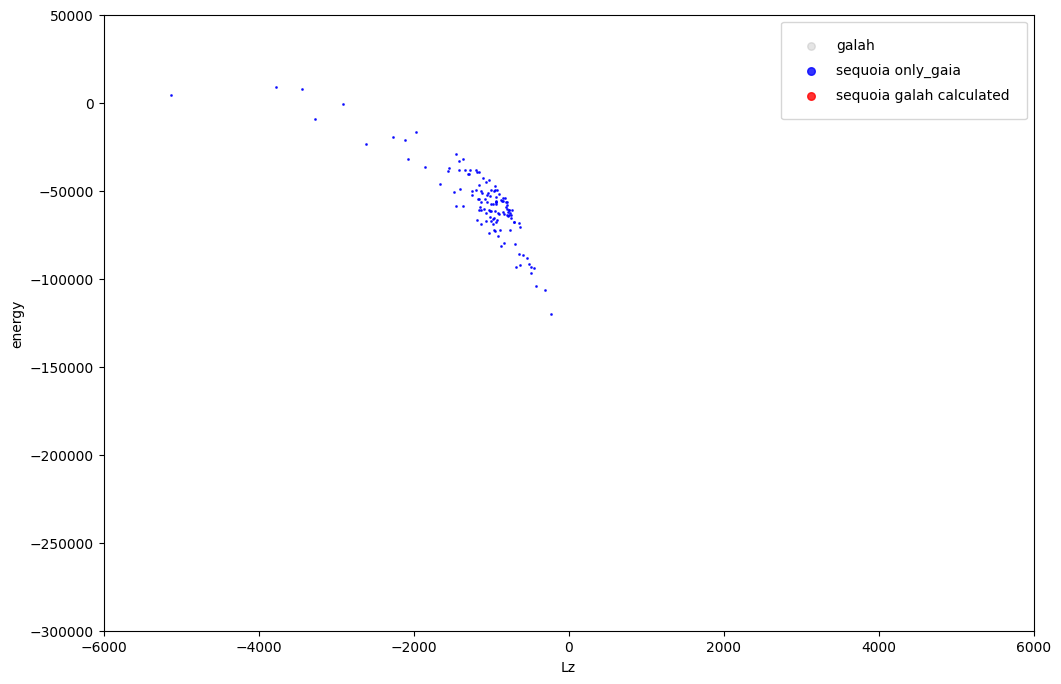

In [12]:
mean_of_the_difference = np.mean(galah_Gaia['Energy'] - galah_Gaia['energy'])

plt.figure(figsize=(12, 8))

plt.scatter(galah_Gaia['L_Z'], galah_Gaia['Energy'] - mean_of_the_difference, label = 'galah', s = 0.2, alpha = 0.2, color = 'grey')
# plt.scatter(galah_Gaia['jphi'], galah_Gaia['energy'], label = 'MWPotential2014+Gaia RVS', s = 0.2, alpha = 0.5)
# plt.scatter(galah_Gaia_GSE['jphi'], galah_Gaia_GSE['energy'], label = 'GSE', s = 0.3, alpha = 0.8, c = 'g')
plt.scatter(galah_Gaia_Sequoia['jphi'], galah_Gaia_Sequoia['energy'], label = 'sequoia only_gaia', s = 1, alpha = 0.8, c = 'b')
plt.scatter(galah_Gaia_Sequoia['L_Z'], galah_Gaia_Sequoia['Energy'] - mean_of_the_difference, label = 'sequoia galah calculated', s = 1, alpha = 0.8, c = 'r')
# plt.scatter(ED_2_stream['jphi'], ED_2_stream['energy'], label = 'ED_2', s = 0.4, alpha = 0.8, c = 'r')

plt.xlim(-6000, 6000)
plt.ylim(-300000,50000)
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
plt.xlabel('Lz')
plt.ylabel('energy');

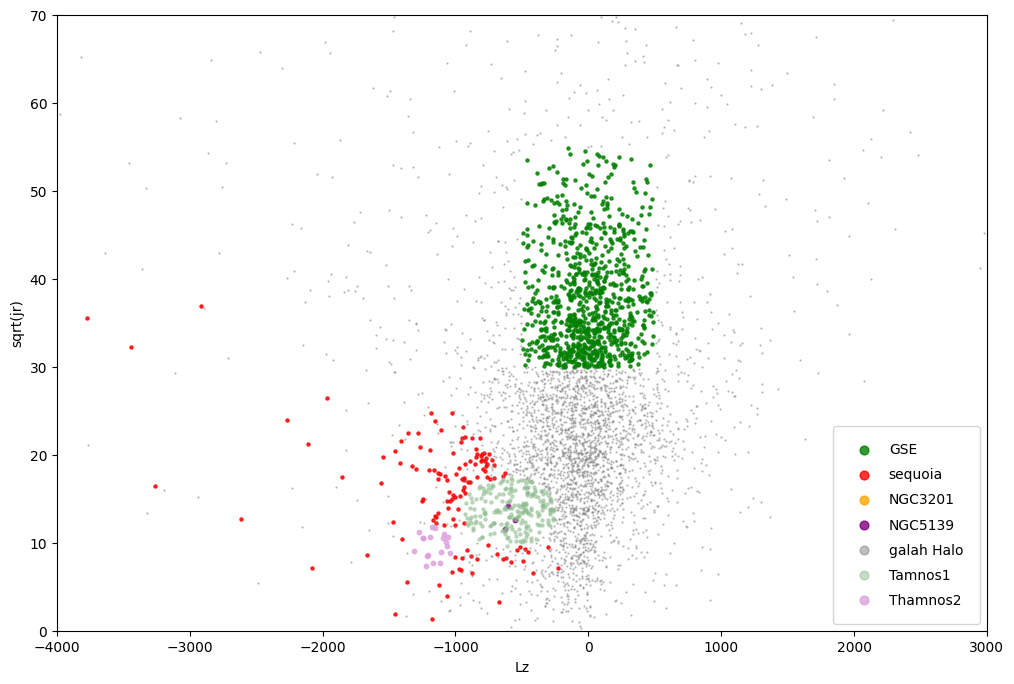

In [17]:
plt.figure(figsize=(12, 8))

# plt.scatter(galah_Gaia['jphi'], np.sqrt(galah_Gaia['jr']), label = 'galah + MWPotential2014', s = 0.2, alpha = 0.5)
plt.scatter(galah_Gaia_GSE['jphi'], np.sqrt(galah_Gaia_GSE['jr']), label = 'GSE', s = 5, alpha = 0.8, c = 'g')
plt.scatter(galah_Gaia_Sequoia['jphi'], np.sqrt(galah_Gaia_Sequoia['jr']), label = 'sequoia', s = 5, alpha = 0.8, c = 'r')
plt.scatter(NGC3201_galah['jphi'], np.sqrt(NGC3201_galah['jr']), label = 'NGC3201', s = 10, alpha = 0.8, c = 'orange')
plt.scatter(NGC5139_galah['jphi'], np.sqrt(NGC5139_galah['jr']), label = 'NGC5139', s = 10, alpha = 0.8, c = 'purple')
plt.scatter(galah_Gaia_Halo['jphi'], np.sqrt(galah_Gaia_Halo['jr']), label = 'galah Halo', s = 0.4, alpha = 0.5, c = 'grey')


# plt.scatter(galah_Kushniruk_GSE['jphi'], np.sqrt(galah_Kushniruk_GSE['jr']), label = 'GSE', s = 5, alpha = 0.8, c = 'g')
plt.scatter(galah_Kushniruk_Thamnos1['jphi'], np.sqrt(galah_Kushniruk_Thamnos1['jr']), label = 'Tamnos1', s = 5, alpha = 0.5, c = 'darkseagreen')
plt.scatter(galah_Kushniruk_Thamnos2['jphi'], np.sqrt(galah_Kushniruk_Thamnos2['jr']), label = 'Thamnos2', s = 10, alpha = 0.8, c = 'plum')

plt.xlim(-4000, 3000)
plt.ylim(0,70)
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([40])
plt.xlabel('Lz')
plt.ylabel('sqrt(jr)');

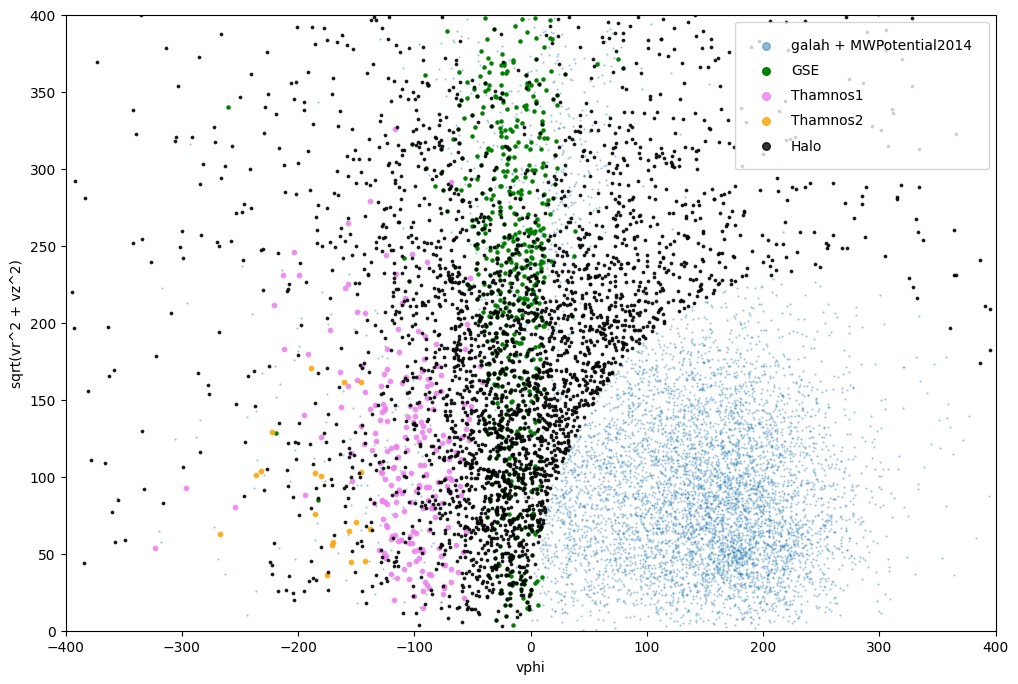

In [18]:
plt.figure(figsize=(12, 8))

plt.scatter(galah_Gaia['vphi'], np.sqrt((galah_Gaia['vr'])**2 + (galah_Gaia['vz'])**2), label = 'galah + MWPotential2014', s = 0.2, alpha = 0.5)
plt.scatter(galah_Kushniruk_GSE['vphi'], np.sqrt((galah_Kushniruk_GSE['vr'])**2 + (galah_Kushniruk_GSE['vz'])**2), label = 'GSE', s = 5, alpha = 1.0, c = 'g')


plt.scatter(galah_Kushniruk_Thamnos1['vphi'], np.sqrt((galah_Kushniruk_Thamnos1['vr'])**2 + (galah_Kushniruk_Thamnos1['vz'])**2), label = 'Thamnos1', s = 10, alpha = 0.8, c = 'violet')
plt.scatter(galah_Kushniruk_Thamnos2['vphi'], np.sqrt((galah_Kushniruk_Thamnos2['vr'])**2 + (galah_Kushniruk_Thamnos2['vz'])**2), label = 'Thamnos2', s = 10, alpha = 0.8, c = 'orange')

plt.scatter(galah_Gaia_Halo['vphi'], np.sqrt((galah_Gaia_Halo['vr'])**2 + (galah_Gaia_Halo['vz'])**2), label = 'Halo', s = 3, alpha = 0.8, c = 'k')


plt.xlim(-400, 400)
plt.ylim(0,400)
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
plt.xlabel('vphi')
plt.ylabel('sqrt(vr^2 + vz^2)');

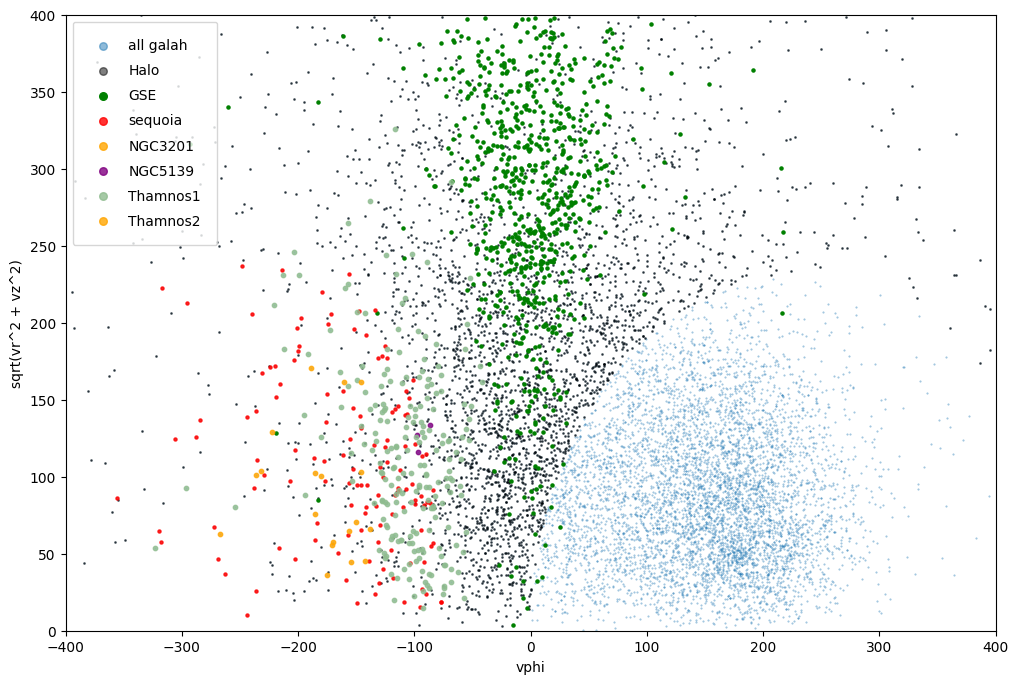

In [19]:
plt.figure(figsize=(12, 8))

plt.scatter(galah_Gaia['vphi'], np.sqrt((galah_Gaia['vr'])**2 + (galah_Gaia['vz'])**2), label = 'all galah', s = 0.2, alpha = 0.5)
plt.scatter(galah_Gaia_Halo['vphi'], np.sqrt((galah_Gaia_Halo['vr'])**2 + (galah_Gaia_Halo['vz'])**2), label = 'Halo', s = 1, alpha = 0.5, c = 'k')
plt.scatter(galah_Gaia_GSE['vphi'], np.sqrt((galah_Gaia_GSE['vr'])**2 + (galah_Gaia_GSE['vz'])**2), label = 'GSE', s = 5, alpha = 1.0, c = 'g')
plt.scatter(galah_Gaia_Sequoia['vphi'], np.sqrt((galah_Gaia_Sequoia['vr'])**2 + (galah_Gaia_Sequoia['vz'])**2), label = 'sequoia', s = 5, alpha = 0.8, c = 'r')
plt.scatter(NGC3201_galah['vphi'], np.sqrt((NGC3201_galah['vr'])**2 + (NGC3201_galah['vz'])**2), label = 'NGC3201', s = 10, alpha = 0.8, c = 'orange')
plt.scatter(NGC5139_galah['vphi'], np.sqrt((NGC5139_galah['vr'])**2 + (NGC5139_galah['vz'])**2), label = 'NGC5139', s = 10, alpha = 0.8, c = 'purple')

plt.scatter(galah_Kushniruk_Thamnos1['vphi'], np.sqrt((galah_Kushniruk_Thamnos1['vr'])**2 + (galah_Kushniruk_Thamnos1['vz'])**2), label = 'Thamnos1', s = 10, alpha = 0.8, c = 'darkseagreen')
plt.scatter(galah_Kushniruk_Thamnos2['vphi'], np.sqrt((galah_Kushniruk_Thamnos2['vr'])**2 + (galah_Kushniruk_Thamnos2['vz'])**2), label = 'Thamnos2', s = 10, alpha = 0.8, c = 'orange')

plt.xlim(-400, 400)
plt.ylim(0,400)
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
plt.xlabel('vphi')
plt.ylabel('sqrt(vr^2 + vz^2)');

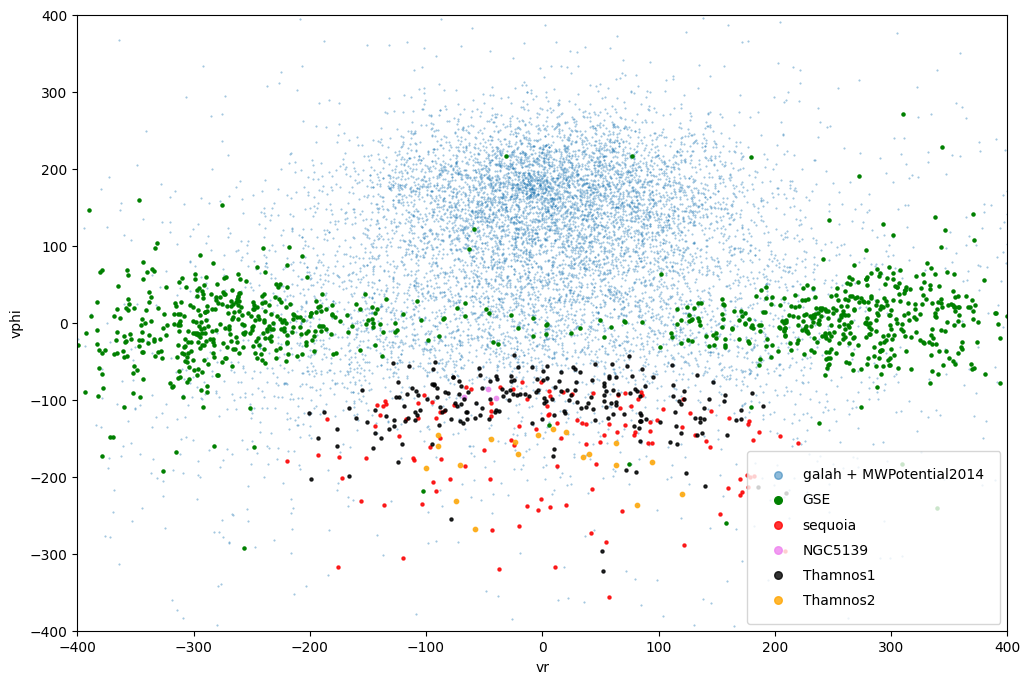

In [20]:
plt.figure(figsize=(12, 8))

plt.scatter(galah_Gaia['vr'], galah_Gaia['vphi'],  label = 'galah + MWPotential2014', s = 0.2, alpha = 0.5)
plt.scatter(galah_Gaia_GSE['vr'], galah_Gaia_GSE['vphi'],  label = 'GSE', s = 5, alpha = 1.0, c = 'g')
plt.scatter(galah_Gaia_Sequoia['vr'], galah_Gaia_Sequoia['vphi'],  label = 'sequoia', s = 5, alpha = 0.8, c = 'r')
# plt.scatter(NGC3201_galah['vr'], NGC3201_galah['vphi'],  label = 'NGC3201', s = 10, alpha = 0.8, c = 'orange')
plt.scatter(NGC5139_galah['vr'], NGC5139_galah['vphi'],  label = 'NGC5139', s = 10, alpha = 0.8, c = 'violet')

plt.scatter(galah_Kushniruk_Thamnos1['vr'], galah_Kushniruk_Thamnos1['vphi'],  label = 'Thamnos1', s = 5, alpha = 0.8, c = 'k')
plt.scatter(galah_Kushniruk_Thamnos2['vr'], galah_Kushniruk_Thamnos2['vphi'],  label = 'Thamnos2', s = 10, alpha = 0.8, c = 'orange')

plt.xlim(-400, 400)
plt.ylim(-400,400)
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
plt.xlabel('vr')
plt.ylabel('vphi');

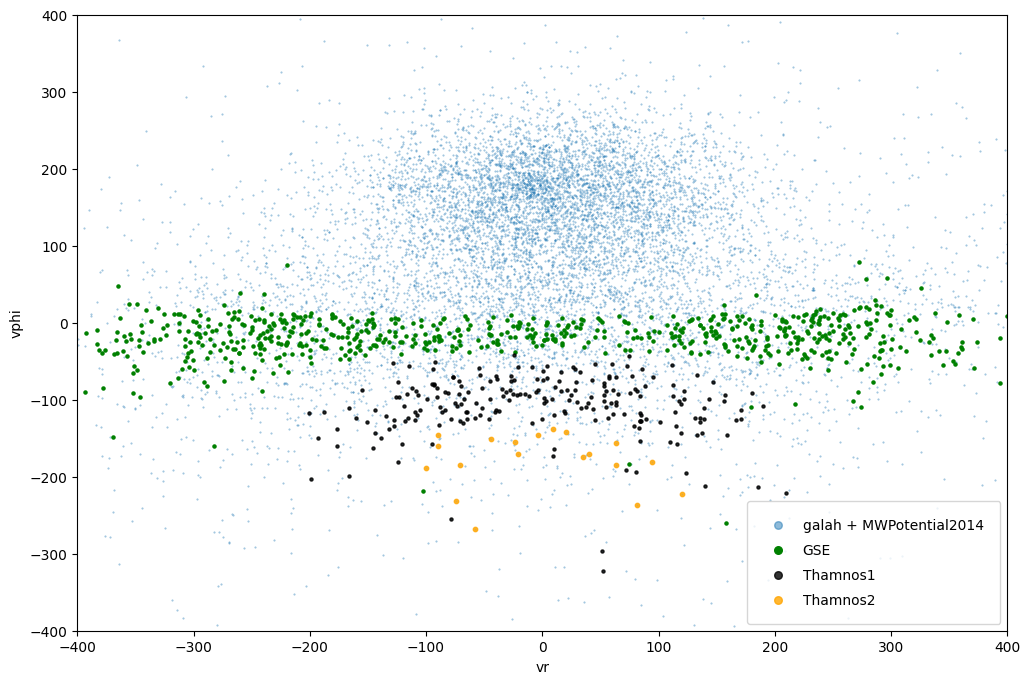

In [21]:
plt.figure(figsize=(12, 8))

plt.scatter(galah_Gaia['vr'], galah_Gaia['vphi'],  label = 'galah + MWPotential2014', s = 0.2, alpha = 0.5)
plt.scatter(galah_Kushniruk_GSE['vr'], galah_Kushniruk_GSE['vphi'],  label = 'GSE', s = 5, alpha = 1.0, c = 'g')

plt.scatter(galah_Kushniruk_Thamnos1['vr'], galah_Kushniruk_Thamnos1['vphi'],  label = 'Thamnos1', s = 5, alpha = 0.8, c = 'k')
plt.scatter(galah_Kushniruk_Thamnos2['vr'], galah_Kushniruk_Thamnos2['vphi'],  label = 'Thamnos2', s = 10, alpha = 0.8, c = 'orange')

plt.xlim(-400, 400)
plt.ylim(-400,400)
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
plt.xlabel('vr')
plt.ylabel('vphi');

/tmp/ipykernel_1776/1281900942.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()



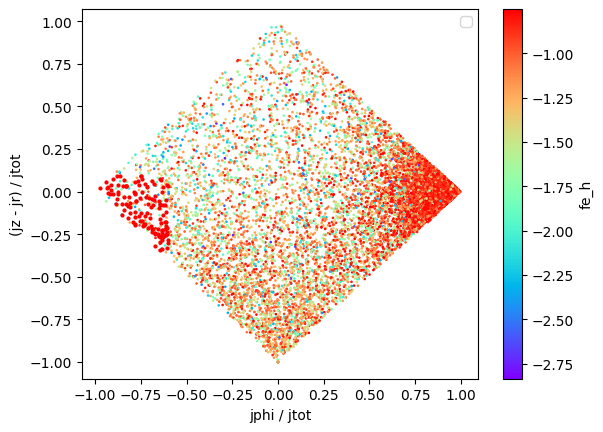

In [23]:
sc = plt.scatter( galah_Gaia['jphi']/ galah_Gaia['jtot'], (galah_Gaia['jz'] - galah_Gaia['jr'])/galah_Gaia['jtot'], s = 0.8, c = galah_Gaia['fe_h'], cmap = 'rainbow' )
# plt.scatter( Apogee_GSE_new_ratios['jphi']/ Apogee_GSE_new_ratios['jtot'], (Apogee_GSE_new_ratios['jz'] - Apogee_GSE_new_ratios['jr'])/Apogee_GSE_new_ratios['jtot'], c = 'g', s = 4)
plt.scatter( galah_Gaia_Sequoia['jphi']/ galah_Gaia_Sequoia['jtot'], (galah_Gaia_Sequoia['jz'] - galah_Gaia_Sequoia['jr'])/galah_Gaia_Sequoia['jtot'], c = 'r', s = 4)#c = Apogee_Sequoia_new_ratios['mg_mn'], cmap = 'rainbow', s= 3, label = "Apogee_Sequoia")#, vmax  = 0)


plt.xlabel('jphi / jtot')
plt.ylabel('(jz - jr) / jtot')
plt.legend()
plt.colorbar(sc, label = 'fe_h')

In [ ]:
# plt.figure(figsize=(12, 8))
# # Apogee_DR19 = Apogee_DR19[Apogee_DR19['mn_h_flags'] == 0]
# # plt.scatter(Apogee_DR19['jphi'], Apogee_DR19['energy'], label = 'All APogee DR19', s = 0.2, alpha = 1, c = Apogee_DR19['mg_h'] - Apogee_DR19['fe_h'], cmap = 'rainbow')
# plt.scatter(Apogee_DR19['jphi'], Apogee_DR19['energy'], label = 'All APogee DR19', s = 0.2, alpha = 0.3)# , c = Apogee_DR19['mg_h'] - Apogee_DR19['fe_h'], cmap = 'rainbow')
# plt.scatter(Apogee_GSE['jphi'], Apogee_GSE['energy'], label = 'GSE', s = 0.3, alpha = 0.8, c = 'g')
# plt.scatter(Apogee_Sequoia['jphi'], Apogee_Sequoia['energy'], label = 'Sequoia', s = 0.3, alpha = 0.8, c = 'k')
# plt.scatter(NGC3201_Apogee['jphi'], NGC3201_Apogee['energy'], label = 'NGC3201', s = 0.3, alpha = 0.8, c = 'orange')
# plt.scatter(NGC5139_Apogee['jphi'], NGC5139_Apogee['energy'], label = 'NGC5139', s = 0.3, alpha = 0.8, c = 'red')

# # plt.scatter(NGC3201_Apogee_apo['jphi'], NGC3201_Apogee_apo['energy'], label = 'NGC3201', s = 0.3, alpha = 0.8, c = 'orange')
# # plt.scatter(NGC5139_Apogee_apo['jphi'], NGC5139_Apogee_apo['energy'], label = 'NGC5139', s = 0.3, alpha = 0.8, c = 'red')

# plt.xlim(-6000, 6000)
# plt.ylim(-300000,50000)
# plt.legend()
# plt.xlabel('Lz')
# plt.ylabel('energy')
# # plt.colorbar();

In [ ]:
# plt.figure(figsize=(12, 8))

# plt.scatter(NGC5139_Apogee['jphi'], NGC5139_Apogee['energy'], label = 'NGC5139_gaia', s = 20, alpha = 0.4, c = 'blue')
# plt.scatter(NGC5139_Apogee_apo['jphi'], NGC5139_Apogee_apo['energy'], label = 'NGC5139_Apogee', s = 0.3, alpha = 0.8, c = 'red')
# plt.scatter(matches['jphi_y'], matches['energy_y'], label = 'NGC5139_matched', s = 20, alpha = 1, c = 'k')

# # plt.xlim(-6000, 6000)
# # plt.ylim(-300000,50000)
# plt.legend()
# plt.xlabel('Lz')
# plt.ylabel('energy')
# # plt.colorbar();

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(Pradosh['jphi'], Pradosh['Energy'], label = 'MWPotential2014+Gaia RVS', s = 0.2, alpha = 0.5)
plt.scatter(Pradosh_GSE['jphi'], Pradosh_GSE['Energy'], label = 'GSE', s = 5, alpha = 0.8, c = 'g')
plt.scatter(Pradosh_Sequoia['jphi'], Pradosh_Sequoia['Energy'], label = 'sequoia', s = 7, alpha = 0.8, c = 'k')
plt.scatter(NGC3201_Pradosh['jphi'], NGC3201_Pradosh['Energy'], label = 'NGC3201', s = 15, alpha = 0.8, c = 'darkkhaki')
# plt.scatter(NGC5139_Pradosh['jphi'], NGC5139_Pradosh['Energy'], label = 'NGC5139', s = 10, alpha = 0.8, c = 'purple')
# plt.scatter(ED_2_stream['jphi'], ED_2_stream['energy'], label = 'ED_2', s = 10, alpha = 0.8, c = 'r')

plt.scatter(Pradosh_Kushniruk_Thamnos1['jphi'], Pradosh_Kushniruk_Thamnos1['Energy'], label = 'Thamnos1', s = 10, alpha = 0.8, c = 'orange')
plt.scatter(Pradosh_Kushniruk_Thamnos2['jphi'], Pradosh_Kushniruk_Thamnos2['Energy'], label = 'Thamnos2', s = 10, alpha = 1.0, c = 'purple')
plt.scatter(NGC5139_Pradosh['jphi'], NGC5139_Pradosh['Energy'], label = 'NGC5139', s = 10, alpha = 0.5, c = 'red')

plt.xlim(-4000, 4000)
plt.ylim(-120000,40000)
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
plt.xlabel('Lz')
plt.ylabel('energy')
plt.title('Das 2026');

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(Pradosh['jphi'], np.sqrt(Pradosh['jr']), label = 'MWPotential2014+Gaia RVS', s = 0.2, alpha = 0.5)
plt.scatter(Pradosh_GSE['jphi'], np.sqrt(Pradosh_GSE['jr']), label = 'GSE', s = 5, alpha = 0.8, c = 'g')
plt.scatter(Pradosh_Sequoia['jphi'], np.sqrt(Pradosh_Sequoia['jr']), label = 'sequoia', s = 5, alpha = 0.8, c = 'k')
plt.scatter(NGC3201_Pradosh['jphi'], np.sqrt(NGC3201_Pradosh['jr']), label = 'NGC3201', s = 10, alpha = 0.8, c = 'orange')
plt.scatter(NGC5139_Pradosh['jphi'], np.sqrt(NGC5139_Pradosh['jr']), label = 'NGC5139', s = 10, alpha = 0.8, c = 'purple')
plt.scatter(ED_2_stream['jphi'], np.sqrt(ED_2_stream['jr']), label = 'ED_2', s = 10, alpha = 0.8, c = 'r')

plt.xlim(-4000, 3000)
plt.ylim(0,70)
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
plt.xlabel('Lz')
plt.ylabel('sqrt(jr)');

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(Pradosh['vphi'], np.sqrt((Pradosh['vR'])**2 + (Pradosh['vz'])**2), label = 'MWPotential2014+Gaia RVS', s = 0.2, alpha = 0.5)
plt.scatter(Pradosh_Halo['vphi'], np.sqrt((Pradosh_Halo['vR'])**2 + (Pradosh_Halo['vz'])**2), label = 'Halo', c = 'grey', s = 2, alpha = 0.8)

plt.scatter(Pradosh_GSE['vphi'], np.sqrt((Pradosh_GSE['vR'])**2 + (Pradosh_GSE['vz'])**2), label = 'GSE', s = 5, alpha = 1.0, c = 'g')
plt.scatter(Pradosh_Sequoia['vphi'], np.sqrt((Pradosh_Sequoia['vR'])**2 + (Pradosh_Sequoia['vz'])**2), label = 'sequoia', s = 5, alpha = 0.8, c = 'r')
plt.scatter(NGC3201_Pradosh['vphi'], np.sqrt((NGC3201_Pradosh['vR'])**2 + (NGC3201_Pradosh['vz'])**2), label = 'NGC3201', s = 10, alpha = 0.8, c = 'darkkhaki')
plt.scatter(NGC5139_Pradosh['vphi'], np.sqrt((NGC5139_Pradosh['vR'])**2 + (NGC5139_Pradosh['vz'])**2), label = 'NGC5139', s = 10, alpha = 0.8, c = 'olive')
# plt.scatter(ED_2_stream['vphi'], np.sqrt((ED_2_stream['vr'])**2 + (ED_2_stream['vz'])**2), label = 'ED_2', s = 10, alpha = 0.8, c = 'r')

Pradosh_Kushniruk_Thamnos1
plt.scatter(Pradosh_Kushniruk_Thamnos1['vphi'], np.sqrt((Pradosh_Kushniruk_Thamnos1['vR'])**2 + (Pradosh_Kushniruk_Thamnos1['vz'])**2), label = 'Thamnos1', s = 10, alpha = 0.8, c = 'orange')
plt.scatter(Pradosh_Kushniruk_Thamnos2['vphi'], np.sqrt((Pradosh_Kushniruk_Thamnos2['vR'])**2 + (Pradosh_Kushniruk_Thamnos2['vz'])**2), label = 'Thamnos2', s = 10, alpha = 0.8, c = 'purple')


plt.xlim(-400, 400)
plt.ylim(0,400)
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
plt.xlabel('vphi')
plt.ylabel('sqrt(vr^2 + vz^2)');

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(Pradosh['vR'], Pradosh['vphi'],  label = 'MWPotential2014+Gaia RVS', s = 0.2, alpha = 0.5)
plt.scatter(Pradosh_GSE['vR'], Pradosh_GSE['vphi'],  label = 'GSE', s = 5, alpha = 1.0, c = 'g')
plt.scatter(Pradosh_Sequoia['vR'], Pradosh_Sequoia['vphi'],  label = 'sequoia', s = 5, alpha = 0.8, c = 'k')
plt.scatter(NGC3201_Pradosh['vR'], NGC3201_Pradosh['vphi'],  label = 'NGC3201', s = 10, alpha = 0.8, c = 'orange')
plt.scatter(NGC5139_Pradosh['vR'], NGC5139_Pradosh['vphi'],  label = 'NGC5139', s = 10, alpha = 0.8, c = 'violet')
plt.scatter(ED_2_stream['vr'], ED_2_stream['vphi'],  label = 'ED_2', s = 10, alpha = 0.8, c = 'r')

plt.xlim(-400, 400)
plt.ylim(-400,400)
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
plt.xlabel('vr')
plt.ylabel('vphi');

In [ ]:
element_ratio = 'FeH'
plt.figure(figsize=(10, 6))
ymax = plt.ylim()[1]

color = 'g'
plot_gmm(Pradosh_GSE[element_ratio], 'GSE', color, 2, maximum_peak = True, plot_compents=False, shift_right = 0.01, shift_up = 0.99)
plot_hist(Pradosh_GSE[element_ratio], 'GSE', color, 0.5)
mean = np.round(np.mean(Pradosh_GSE[element_ratio]), 3)
plt.axvline(x=mean, color=color, linestyle='--')
plt.text(mean + 0.11, 0.98, f'{mean}', color=color, transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

color = 'r'
plot_gmm(Pradosh_Sequoia[element_ratio], 'Sequoia', color, 2, maximum_peak = True, plot_compents=False, shift_right = 0.01, shift_up = 0.960)
plot_hist(Pradosh_Sequoia[element_ratio], 'Sequoia', color, 0.5)
mean = np.round(np.mean(Pradosh_Sequoia[element_ratio]), 3)
plt.axvline(x=mean, color=color, linestyle='--')
plt.text(mean -0.11, 0.98, f'{mean}', color=color, transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

color = 'b'
# plot_gmm(Pradosh_Kushniruk_Thamnos1[element_ratio], 'Thamnos1', color, 2, maximum_peak = True, plot_compents=False)
# plot_hist(Pradosh_Kushniruk_Thamnos1[element_ratio], 'Thamnos1', color, 0.5)
# mean = np.round(np.mean(Pradosh_Kushniruk_Thamnos1[element_ratio]), 3)
# plt.axvline(x=mean, color=color, linestyle='--')
# plt.text(mean + 0.13, 0.985, f'{mean}', color=color, transform=plt.gca().get_xaxis_transform(),
#          ha='center', va='top')

color='darkgoldenrod'
# plot_gmm(Pradosh_Kushniruk_Thamnos2[element_ratio], 'Thamnos2', color, 2, maximum_peak = True, plot_compents=False)
# plot_hist(Pradosh_Kushniruk_Thamnos2[element_ratio], 'Thamnos2', color, 0.5)
# mean = np.round(np.mean(Pradosh_Kushniruk_Thamnos2[element_ratio]), 3)
# plt.axvline(x=mean, color=color, linestyle='--')
# plt.text(mean-0.13, 0.985, f'{mean}', color= color, transform=plt.gca().get_xaxis_transform(),
#          ha='center', va='top')

color = 'grey'
plot_gmm(Pradosh_Halo[element_ratio], 'Halo', color, 2, maximum_peak = True, plot_compents=False, shift_right = 0.01, shift_up = 0.930)
plot_hist(Pradosh_Halo[element_ratio], 'Halo', color, 0.5)
mean = np.round(np.mean(Pradosh_Halo[element_ratio]), 3)
plt.axvline(x=mean, color=color, linestyle='--')
plt.text(mean -0.11, 0.98, f'{mean}', color=color, transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

# plot_gmm(NGC3201_Pradosh[element_ratio], 'NGC3201', 'b', 2, maximum_peak = True, plot_compents=False)
# plot_hist(NGC3201_Pradosh[element_ratio], 'NGC3201', 'b', 0.5)
# mean = np.round(np.mean(NGC3201_Pradosh[element_ratio]), 3)
# plt.axvline(x=mean, color='b', linestyle='--')
# plt.text(mean-0.13, 0.985, f'{mean}', color='b', transform=plt.gca().get_xaxis_transform(),
#          ha='center', va='top')

# plot_gmm(NGC5139_Pradosh[element_ratio], 'NGC5139', 'purple', 2, maximum_peak = True, plot_compents=False)
# plot_hist(NGC5139_Pradosh[element_ratio], 'NGC5139', 'purple', 0.5)
# mean = np.round(np.mean(NGC5139_Pradosh[element_ratio]), 3)
# plt.axvline(x=mean, color='purple', linestyle='--')
# plt.text(mean-0.13, 0.985, f'{mean}', color='purple', transform=plt.gca().get_xaxis_transform(),
#          ha='center', va='top')

plt.xlabel(element_ratio)
plt.ylabel('Density')
plt.title('Das 2026 Distribution')
plt.legend()

In [ ]:
element_list_full = ["H", "Fe", "Ca", "Si", "Ti", "Ni", "Zr", "Ce", "Nd"]
element_list_partial_large = [ 'Fe', "Ca", 'Si', "Ti", 'Ni', "Zr", "Ce", "Nd"] #does not contain H, Fe, Si, or Ni
element_list_partial_large_no_Fe = [ "Ca", 'Si', "Ti", 'Ni', "Zr", "Ce", "Nd"]
element_list_partial_small = [ "Ca", "Ti","Zr", "Ce", "Nd"]  #does not contain H, Fe, Si, or Ni
Pradosh_Apogee_elements = ['Ca', 'Ti', 'Ce'] #this is to compare with Apogee

element_list = element_list_partial_large

Pradosh_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_pradosh(Pradosh, element_list)

Pradosh_new_ratios = Pradosh_new_ratios_catolog_ratiolist_ratioerrorlist[0] # this ontains a full catalog from Pradosh but now it includes ratios for Ca, Si, Ti, Ni, Zr, Ce, and Nd relative to eachother: Pradosh did recomend taking out
                                                                 # Si, and Ni whitch I can do by changing "element_list_partial_large" to element_list_partial_small
Pradosh_new_element_ratio_list = Pradosh_new_ratios_catolog_ratiolist_ratioerrorlist[1]     # this just lists the new columns ratios so I can more easily call them
Pradosh_new_element_ratio_errors_list = Pradosh_new_ratios_catolog_ratiolist_ratioerrorlist[2]    # this just lists the new columns ratio errors so I can more easily call them

Pradosh_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_pradosh(NGC3201_Pradosh, element_list)
Pradosh_NGC3201_new_ratios = Pradosh_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist[0]

Pradosh_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_pradosh(NGC5139_Pradosh, element_list)
Pradosh_NGC5139_new_ratios = Pradosh_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist[0]

Pradosh_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_pradosh(Pradosh_GSE, element_list)
Pradosh_GSE_new_ratios = Pradosh_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

Pradosh_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_pradosh(Pradosh_Sequoia, element_list)
Pradosh_Sequoia_new_ratios = Pradosh_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist[0]

Pradosh_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_pradosh(Pradosh_Kushniruk_Thamnos1, element_list)
Pradosh_Thamnos1_new_ratios = Pradosh_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist[0]

Pradosh_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_pradosh(Pradosh_Kushniruk_Thamnos2, element_list)
Pradosh_Thamnos2_new_ratios = Pradosh_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist[0]

Pradosh_Halo_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_pradosh(Pradosh_Halo, element_list)
Pradosh_Halo_new_ratios = Pradosh_Halo_new_ratios_catolog_ratiolist_ratioerrorlist[0]

In [ ]:
Halo_Pradosh = Pradosh_new_ratios[(Pradosh_new_ratios['FeH'] < -0.8)
                                            & (Pradosh_new_ratios['TiFe'] > 0.25)
                                            & (Pradosh_new_ratios['Lz'] > -1500)
                                            & (Pradosh_new_ratios['Lz'] < 1500)
                                            & (Pradosh_new_ratios['eccentricity'] > 0.5)
                                            & (Pradosh_new_ratios['eccentricity'] < 0.8)
                                            & (~Pradosh['source_id'].isin(NGC3201_Pradosh['source_id']))
                                            & (~Pradosh['source_id'].isin(NGC5139_Pradosh['source_id']))
                                            & (~Pradosh['source_id'].isin(Pradosh_GSE_new_ratios['source_id']))
                                            & (~Pradosh['source_id'].isin(Pradosh_Sequoia_new_ratios['source_id']))
                                            ]

thickdisk_Pradosh = Pradosh_new_ratios[(Pradosh_new_ratios['FeH'] < -0.8)
                                                 & (Pradosh_new_ratios['TiFe'] > 0.25)
                                                 & (Pradosh_new_ratios['Lz'] > 0)
                                                 & (Pradosh_new_ratios['eccentricity'] < 0.5)
                                                 & (~Pradosh['source_id'].isin(NGC3201_Pradosh['source_id']))
                                                 & (~Pradosh['source_id'].isin(NGC5139_Pradosh['source_id']))
                                                 & (~Pradosh['source_id'].isin(Pradosh_GSE_new_ratios['source_id']))
                                                 & (~Pradosh['source_id'].isin(Pradosh_Sequoia_new_ratios['source_id']))
                                            ]

In [ ]:
labels = [f'[{label}]' for label in Pradosh_new_element_ratio_list]


first_plot = 'Pradosh_GSE' #pick one of the keys in corner_datasets
n_components = 2



corner_datasets = {
    # 'All': (Pradosh_new_ratios[Pradosh_new_element_ratio_list], Pradosh_new_ratios[Pradosh_new_element_ratio_errors_list], "yellow", 1, 0.5),
    # "Halo": (Halo_Pradosh[Pradosh_new_element_ratio_list], Halo_Pradosh[Pradosh_new_element_ratio_errors_list], "blue", 1, 0.5),
    # "Thickdisk": (thickdisk_Pradosh[Pradosh_new_element_ratio_list], thickdisk_Pradosh[Pradosh_new_element_ratio_errors_list], "purple", 1, 0.2),
    "Halo": (Pradosh_Halo[Pradosh_new_element_ratio_list], Pradosh_Halo[Pradosh_new_element_ratio_errors_list], "grey", 1, 0.5),
    "Pradosh_GSE": (Pradosh_GSE_new_ratios[Pradosh_new_element_ratio_list], Pradosh_GSE_new_ratios[Pradosh_new_element_ratio_errors_list],"green", 2.0, 1.0),
    "Pradosh_Sequoia": (Pradosh_Sequoia_new_ratios[Pradosh_new_element_ratio_list], Pradosh_Sequoia_new_ratios[Pradosh_new_element_ratio_errors_list],"red", 1.5, 1.0),
    # 'NGC3201': (Pradosh_NGC3201_new_ratios[Pradosh_new_element_ratio_list], Pradosh_NGC3201_new_ratios[Pradosh_new_element_ratio_errors_list],"orange", 2.5, 1.0),
    # 'NGC5139': (Pradosh_NGC5139_new_ratios[Pradosh_new_element_ratio_list], Pradosh_NGC5139_new_ratios[Pradosh_new_element_ratio_errors_list],"purple", 2.5, 1.0),
}


# keys = sorted(corner_datasets.keys())  # sorted = consistent colors across runs
# cmap = plt.cm.tab10
# colors = cmap(np.linspace(0, 0.8, len(keys)))

# for key, color in zip(keys, colors):
#     df_values, df_errors, _, ms, alpha = corner_datasets[key]
#     corner_datasets[key] = (df_values, df_errors, color, ms, alpha)
# # Convert all to values and keep data info


for key in corner_datasets:
    df_values, df_errors, color, ms, alpha = corner_datasets[key] #data frame, color, markersize, alpha


    vals = df_values.to_numpy()
    # vals, mask = filter_constant_columns(vals)
    errs = df_errors.to_numpy()
    row_mask = np.any(np.isfinite(vals), axis=1)
    vals = vals[row_mask]
    errs = errs[row_mask]
    print(f"{key}: {df_values.shape[0]} stars, {df_values.shape[1]} element ratios")
    corner_datasets[key] = (vals, errs, color, ms, alpha)
 
first_values, first_errors, first_color, first_ms, first_alpha = corner_datasets[first_plot]
fig = corner.corner(
first_values,
labels=labels,
color=first_color,
data_kwargs={'ms': first_ms, 'alpha': first_alpha, 'color': first_color},
hist_kwargs={"density": True, "histtype": "step", "linewidth": 0.5},
plot_datapoints=True,
plot_contours=False,
fill_contours=False,
plot_density=False,
)


ndim = first_values.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))


# # Function to overlay Gaussian
# def overlay_gaussian(values, errors, color):
#     for i in range(ndim):
#         ax = axes[i, i]
#         x = values[:, i]
#         sigma_x = errors[:,i]
#         mask = np.isfinite(x) & np.isfinite(sigma_x)
#         x = x[mask]
#         sigma_x = sigma_x[mask]
#         if len(x) > 1:
#             mu, sigma = weighted_avg_and_std(x, sigma_x) #now this should be weighting the errors better
#             weights  = 1 / sigma_x**2
#             x_grid = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 500)
#             ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), color=color, lw=2)

def overlay_gaussian(values, errors, color, n_components):
    for i in range(ndim):
        ax = axes[i, i]
        x = values[:, i]
        sigma_x = errors[:, i]

        mask = np.isfinite(x) & np.isfinite(sigma_x)
        x = x[mask]

        if len(x) > 5:  # need enough points
            # Fit 2-component Gaussian Mixture
            gmm = GaussianMixture(n_components=n_components)
            gmm.fit(x.reshape(-1, 1))

            x_grid = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 500)

            pdf = np.zeros_like(x_grid)

            # Sum the two Gaussians
            for weight, mean, cov in zip(gmm.weights_, gmm.means_, gmm.covariances_):
                sigma = np.sqrt(cov[0][0])
                pdf += weight * norm.pdf(x_grid, mean[0], sigma)

                # (optional) plot individual components
                ax.plot(x_grid,
                        weight * norm.pdf(x_grid, mean[0], sigma),
                        color=color,
                        lw=1,
                        # ls='dashed',
                        ls = "none",
                        alpha=0.7)

            # Plot total mixture
            ax.plot(x_grid, pdf, color=color, lw=0.5)
            
# Overlay remaining datasets
handles = []
for key, (values, errors, color, ms, alpha) in corner_datasets.items():
    if key != first_plot:
        corner.corner(
            values,
            fig=fig,
            color=color,
            data_kwargs={'ms': ms, 'alpha': alpha, 'color': color},
            hist_kwargs={"density": True, "histtype": "step", "linewidth": 0.5},
            plot_datapoints=True,
            plot_contours=False,
            fill_contours=False,
            plot_density=False,
            show_titles=(key == "NGC3201"),
        )
    overlay_gaussian(values, errors, color, n_components)
    handles.append(plt.Line2D([0], [0], color = color, label = key))

fig.legend(handles=handles,
           loc="upper right",
           bbox_to_anchor=(1.0, 0.98),
        #    ncol=len(handles),
        #    frameon=False,
           fontsize=30)

In [ ]:
Pradosh_normal_element_list = ['FeH','CaFe', 'TiFe', 'SiFe','NiFe', 'ZrFe', 'CeFe', 'NdFe']
Pradosh_normal_element_list_errors = ['e_FeH','e_CaFe', 'e_TiFe', 'e_SiFe','e_NiFe', 'e_ZrFe', 'e_CeFe', 'e_NdFe']

labels = [f'[{label}]' for label in Pradosh_normal_element_list]

first_plot = 'Pradosh_GSE' #pick one of the keys in corner_datasets

corner_datasets = {
    # 'All': (Pradosh_new_ratios[Pradosh_normal_element_list], Pradosh_new_ratios[Pradosh_normal_element_list_errors], "purple", 1, 0.5),
    # "Halo": (Halo_Pradosh[Pradosh_normal_element_list], Halo_Pradosh[Pradosh_normal_element_list_errors], "blue", 1, 0.5),
    # "Thickdisk": (thickdisk_Pradosh[Pradosh_normal_element_list], thickdisk_Pradosh[Pradosh_normal_element_list_errors], "purple", 1, 0.2),
    "Pradosh_GSE": (Pradosh_GSE_new_ratios[Pradosh_normal_element_list], Pradosh_GSE_new_ratios[Pradosh_normal_element_list_errors],"green", 2.5, 1.0),
    "Pradosh_Sequoia": (Pradosh_Sequoia_new_ratios[Pradosh_normal_element_list], Pradosh_Sequoia_new_ratios[Pradosh_normal_element_list_errors],"red", 2.5, 1.0),
    'NGC3201': (Pradosh_NGC3201_new_ratios[Pradosh_normal_element_list], Pradosh_NGC3201_new_ratios[Pradosh_normal_element_list_errors],"orange", 2.5, 1.0),
    'NGC5139': (Pradosh_NGC5139_new_ratios[Pradosh_normal_element_list], Pradosh_NGC5139_new_ratios[Pradosh_normal_element_list_errors],"purple", 2.5, 1.0),
}

# keys = sorted(corner_datasets.keys())  # sorted = consistent colors across runs
# cmap = plt.cm.tab10
# colors = cmap(np.linspace(0, 0.8, len(keys)))

# for key, color in zip(keys, colors):
#     df_values, df_errors, _, ms, alpha = corner_datasets[key]
#     corner_datasets[key] = (df_values, df_errors, color, ms, alpha)
# # Convert all to values and keep data info

for key in corner_datasets:
    df_values, df_errors, color, ms, alpha = corner_datasets[key] #data frame, color, markersize, alpha

    vals = df_values.to_numpy()
    # vals, mask = filter_constant_columns(vals)
    errs = df_errors.to_numpy()
    row_mask = np.any(np.isfinite(vals), axis=1)
    vals = vals[row_mask]
    errs = errs[row_mask]
    print(f"{key}: {df_values.shape[0]} stars, {df_values.shape[1]} element ratios")
    corner_datasets[key] = (vals, errs, color, ms, alpha)
 
first_values, first_errors, first_color, first_ms, first_alpha = corner_datasets[first_plot]
fig = corner.corner(
first_values,
labels=labels,
color=first_color,
data_kwargs={'ms': first_ms, 'alpha': first_alpha, 'color': first_color},
hist_kwargs={"density": True, "histtype": "step", "linewidth": 0},
plot_datapoints=True,
plot_contours=False,
fill_contours=False,
plot_density=False,
)

ndim = first_values.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

# Function to overlay Gaussian
def overlay_gaussian(values, errors, color):
    for i in range(ndim):
        ax = axes[i, i]
        x = values[:, i]
        sigma_x = errors[:,i]
        mask = np.isfinite(x) & np.isfinite(sigma_x)
        x = x[mask]
        sigma_x = sigma_x[mask]
        if len(x) > 1:
            mu, sigma = weighted_avg_and_std(x, sigma_x) #now this should be weighting the errors better
            weights  = 1 / sigma_x**2
            x_grid = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 500)
            ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), color=color, lw=2)

# Overlay remaining datasets
handles = []
for key, (values, errors, color, ms, alpha) in corner_datasets.items():
    if key != first_plot:
        corner.corner(
            values,
            fig=fig,
            color=color,
            data_kwargs={'ms': ms, 'alpha': alpha, 'color': color},
            hist_kwargs={"density": True, "histtype": "step", "linewidth": 0},
            plot_datapoints=True,
            plot_contours=False,
            fill_contours=False,
            plot_density=False,
            show_titles=(key == "NGC3201"),
        )
    overlay_gaussian(values, errors, color)
    handles.append(plt.Line2D([0], [0], color = color, label = key))

fig.legend(handles=handles,
           loc="upper right",
           bbox_to_anchor=(1.0, 0.98),
        #    ncol=len(handles),
        #    frameon=False,
           fontsize=30)

In [ ]:
''' THIS IS FOR 4D STUFF'''

# element_list = Pradosh_normal_element_list
# element_list_errors = Pradosh_normal_element_list_errors

element_list = Pradosh_new_element_ratio_list
element_list_errors = Pradosh_new_element_ratio_errors_list

feature_cols = element_list

cut_to_use = {
    # "All": Pradosh_new_ratios,
    # "Halo": Halo_Pradosh,
    # "Thick_disk": thickdisk_Pradosh,
    "GSE": Pradosh_GSE_new_ratios,
    "Sequoia": Pradosh_Sequoia_new_ratios,
}

# Combine the clusters into a single DataFrame
df_list = []
for Group_Name, df in cut_to_use.items():
    df_copy = df.copy()
    df_copy["Group_Name"] = Group_Name  # label column
    df_list.append(df_copy)

df_all = pd.concat(df_list, ignore_index=True)
final_output = []
for ratio1 in range(len(feature_cols)):
    for ratio2 in range(ratio1+1,len(feature_cols)):
        for ratio3 in range(ratio2+1,len(feature_cols)):
            for ratio4 in range(ratio3+1,len(feature_cols)):    
                col1 = feature_cols[ratio1]
                col2 = feature_cols[ratio2]
                col3 = feature_cols[ratio3]
                col4 = feature_cols[ratio4]

                # X = df_all[[col1, col2, col3]]#.copy()
                X = df_all[[col1, col2, col3, col4]]#.copy()
                y = df_all["Group_Name"]#.copy()

                # Remove rows where the feature is NaN
                # mask = X[feature_cols[ratio1], feature_cols[ratio2]].notna()
                # X = X[mask]
                # y = y[mask]

                # Split into train/test sets
                test_size = 0.2 if X.shape[0] > 10 else 0.1  # adjust test size for very small clusters
                X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=42, stratify=y
                )

                # Train Random Forest classifier
                clf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
                clf.fit(X_train, y_train)
                # Predict and calculate accuracy
                y_pred = clf.predict(X_test)
                acc = accuracy_score(y_test, y_pred)
                final_output.append({
                "ratio1": col1,
                "ratio2": col2,
                'ratio3': col3,
                'ratio4': col4,
                "accuracy": acc
                })
final_output = pd.DataFrame(final_output)
final_output = final_output.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)

final_output_Pradosh = final_output

In [ ]:
print(len(final_output))

In [ ]:
with pd.option_context('display.max_rows', None):
    print(final_output_Pradosh)

In [ ]:
''' MINI CORNER PLOTS '''
# labels = ['TiCa', 'NiSi', 'CeZr'] # best
# labels = ['TiCa', 'ZrCa', 'NdSi'] # 2nd best
# labels = ['TiCa', 'NdSi', 'NdTi'] # 3rd best
# labels = ['TiCa', 'NdSi', 'ZrTi'] # 4th best
# labels = ['SiCa', 'NiTi', 'NdZr'] # 5th best

# e_labels = []
# for i in labels:
#     e_labels.append('e_' + i)
sample_set = final_output_Pradosh
TOP_35_ = top_min_corner_plots(sample_set, 50)
TOP_lables = min_corner_plot_lables(sample_set, 50)
parent_folder = "/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots"

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_folder = os.path.join(
    parent_folder,
    f"{timestamp}_Pradosh_50_GSE_vs_Sequoia_4d_no_Fe_Thamnos_stars_removed"
)                                      # This contains the name of the folder
os.makedirs(save_folder, exist_ok=True)
for i in range(len(TOP_lables[0])):
    labels = TOP_lables[0][i]
    e_labels = TOP_lables[1][i]
    accuracy = TOP_lables[2][i]

    first_plot = 'Pradosh_Halo' #pick one of the keys in corner_datasets
    n_components = 2

    corner_datasets = {
        # "galah_Halo": (Halo_Pradosh_galah_Gaia[labels], Halo_Pradosh_galah_Gaia[e_labels],"blue", 2.5, 1.0),
        "Pradosh_Halo": (Pradosh_Halo_new_ratios[labels], Pradosh_Halo_new_ratios[e_labels],"grey", 1, 0.5),
        # "galah_Thickdisk": (thickdisk_Pradosh[labels], thickdisk_Pradosh[e_labels],"purple", 2.5, 1.0),
        "Pradosh_GSE": (Pradosh_GSE_new_ratios[labels], Pradosh_GSE_new_ratios[e_labels],"green", 2.0, 1.0),
        "Pradosh_Sequoia": (Pradosh_Sequoia_new_ratios[labels], Pradosh_Sequoia_new_ratios[e_labels],"red", 1.5, 1.0),
        # "Pradosh_NGC5139": (Pradosh_NGC5139_new_ratios[labels], Pradosh_NGC5139_new_ratios[e_labels],"blue", 2.5, 1.0),
        # "Pradosh_NGC3201": (Pradosh_NGC3201_new_ratios[labels], Pradosh_NGC3201_new_ratios[e_labels],"purple", 2.5, 1.0),
    }

    # keys = sorted(corner_datasets.keys())  # sorted = consistent colors across runs
    # cmap = plt.cm.tab10
    # colors = cmap(np.linspace(0, 0.8, len(keys)))

    # for key, color in zip(keys, colors):
    #     df_values, df_errors, _, ms, alpha = corner_datasets[key]
    #     corner_datasets[key] = (df_values, df_errors, color, ms, alpha)
    # # Convert all to values and keep data info


    for key in corner_datasets:
        df_values, df_errors, color, ms, alpha = corner_datasets[key] #data frame, color, markersize, alpha

        vals = df_values.to_numpy()
        # vals, mask = filter_constant_columns(vals)
        errs = df_errors.to_numpy()
        row_mask = np.any(np.isfinite(vals), axis=1)
        vals = vals[row_mask]
        errs = errs[row_mask]
        print(f"{key}: {df_values.shape[0]} stars, {df_values.shape[1]} element ratios")
        corner_datasets[key] = (vals, errs, color, ms, alpha)
    
    first_values, first_errors, first_color, first_ms, first_alpha = corner_datasets[first_plot]
    fig = corner.corner(
    first_values,
    labels=labels,
    color=first_color,
    data_kwargs={'ms': first_ms, 'alpha': first_alpha, 'color': first_color},
    hist_kwargs={"density": True, "histtype": "step", "linewidth": 0.5},
    plot_datapoints=True,
    plot_contours=False,
    fill_contours=False,
    plot_density=False,
    )

    ACC = round(accuracy, 4)
    fig.suptitle(f'Accuracy: {ACC}', fontsize=16, y=0.98)

    ndim = first_values.shape[1]
    axes = np.array(fig.axes).reshape((ndim, ndim))

    def overlay_gaussian(values, errors, color, n_components):
        for i in range(ndim):
            ax = axes[i, i]
            x = values[:, i]
            sigma_x = errors[:, i]

            mask = np.isfinite(x) & np.isfinite(sigma_x)
            x = x[mask]

            if len(x) > 5:  # need enough points
                # Fit 2-component Gaussian Mixture
                gmm = GaussianMixture(n_components=n_components)
                gmm.fit(x.reshape(-1, 1))

                x_grid = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 500)

                pdf = np.zeros_like(x_grid)

                # Sum the two Gaussians
                for weight, mean, cov in zip(gmm.weights_, gmm.means_, gmm.covariances_):
                    sigma = np.sqrt(cov[0][0])
                    pdf += weight * norm.pdf(x_grid, mean[0], sigma)

                    # (optional) plot individual components
                    ax.plot(x_grid,
                            weight * norm.pdf(x_grid, mean[0], sigma),
                            color=color,
                            lw=1,
                            # ls='dashed',
                            ls = "none",
                            alpha=0.7)

                # Plot total mixture
                ax.plot(x_grid, pdf, color=color, lw=0.5)

    # Overlay remaining datasets
    handles = []
    for key, (values, errors, color, ms, alpha) in corner_datasets.items():
        if key != first_plot:
            corner.corner(
                values,
                fig=fig,
                color=color,
                data_kwargs={'ms': ms, 'alpha': alpha, 'color': color},
                hist_kwargs={"density": True, "histtype": "step", "linewidth": 0.5},
                plot_datapoints=True,
                plot_contours=False,
                fill_contours=False,
                plot_density=False,
                show_titles=(key == "NGC3201"),
            )
        overlay_gaussian(values, errors, color, n_components)
        handles.append(plt.Line2D([0], [0], color = color, label = key))

    fig.legend(handles=handles,
            loc="upper right",
            bbox_to_anchor=(1.0, 0.98),
            #    ncol=len(handles),
            #    frameon=False,
            fontsize=12)
    
    # Save into new folder
    plt.savefig(os.path.join(save_folder, f"plot_{i}_{labels}.png"))

    plt.close()

In [ ]:
element_ratio = 'NdTi'
plt.figure(figsize=(10, 6))

plot_gmm(Pradosh_GSE_new_ratios[element_ratio], 'Pradosh_GSE', 'g', 2)
plot_hist(Pradosh_GSE_new_ratios[element_ratio], 'Pradosh_GSE', 'g', 0.5)
mean_GSE = np.round(np.mean(Pradosh_GSE_new_ratios[element_ratio]), 3)
plt.axvline(x=mean_GSE, color='g', linestyle='--')
plt.text(mean_GSE+0.1, 0.99, f'{mean_GSE}', color='g', transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

plot_gmm(Pradosh_Sequoia_new_ratios[element_ratio], 'Pradosh_Sequoia', 'r', 2)
plot_hist(Pradosh_Sequoia_new_ratios[element_ratio], 'Pradosh_Sequoia', 'r', 0.5)
mean_Sequoia = np.round(np.mean(Pradosh_Sequoia_new_ratios[element_ratio]), 3)
plt.axvline(x=mean_Sequoia, color='r', linestyle='--')
plt.text(mean_Sequoia- 0.1, 0.97, f'{mean_Sequoia}', color='r', transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

# plot_gmm(Pradosh_Kushniruk_Thamnos1[element_ratio], 'Galah_Thamnos1', 'b', 2)
# plot_hist(Pradosh_Kushniruk_Thamnos1[element_ratio], 'Galah_Thamnos1', 'b', 0.5)
# mean_Thamnos1 = np.round(np.mean(Pradosh_Kushniruk_Thamnos1[element_ratio]), 3)
# plt.axvline(x=mean_Thamnos1, color='b', linestyle='--')
# plt.text(mean_Thamnos1 + 0.13, 0.985, f'{mean_Thamnos1}', color='b', transform=plt.gca().get_xaxis_transform(),
#          ha='center', va='top')

# plot_gmm(Pradosh_Kushniruk_Thamnos2[element_ratio], 'Galah_Thamnos2', 'darkgoldenrod', 2)
# plot_hist(Pradosh_Kushniruk_Thamnos2[element_ratio], 'Galah_Thamnos2', 'darkgoldenrod', 0.5)
# mean_Thamnos2 = np.round(np.mean(Pradosh_Kushniruk_Thamnos2[element_ratio]), 3)
# plt.axvline(x=mean_Thamnos2, color='darkgoldenrod', linestyle='--')
# plt.text(mean_Thamnos2-0.13, 0.985, f'{mean_Thamnos2}', color='darkgoldenrod', transform=plt.gca().get_xaxis_transform(),
#          ha='center', va='top')

# plot_gmm(Pradosh_NGC3201_new_ratios[element_ratio], 'Pradosh_NGC3201', 'b', 2)
# plot_hist(Pradosh_NGC3201_new_ratios[element_ratio], 'Pradosh_NGC3201', 'b')

# plot_gmm(Pradosh_NGC5139_new_ratios[element_ratio], 'Pradosh_NGC5139', 'purple', 2)
# plot_hist(Pradosh_NGC5139_new_ratios[element_ratio], 'Pradosh_NGC5139', 'purple')

plot_gmm(Halo_Pradosh[element_ratio], 'Pradosh_Sequoia', 'b', 2)
plot_hist(Halo_Pradosh[element_ratio], 'Pradosh_Sequoia', 'b', 0.5)

plt.xlabel(element_ratio)
plt.ylabel('Density')
plt.title(f'Pradosh {element_ratio} Distribution')
plt.legend()

In [ ]:
plt.figure(figsize=(10, 6))

elm_ratio1 = 'FeH'
elm_ratio2 = 'NiFe'

elm_ratio1 = 'CeZr'
elm_ratio2 = 'NiTi'

elm_ratio1 = 'NdFe'
elm_ratio2 = 'NdCa'

# plt.scatter(Pradosh_new_ratios[elm_ratio1], Pradosh_new_ratios[elm_ratio2], c = Pradosh_new_ratios['eccentricity'], label = 'All stars', s = 1, alpha = 1)
# plt.scatter(Pradosh_Halo_new_ratios[elm_ratio1], Pradosh_Halo_new_ratios[elm_ratio2], color = 'grey', label = 'Halo', s = 1, alpha = 0.5)
plt.scatter(Pradosh_GSE_new_ratios[elm_ratio1], Pradosh_GSE_new_ratios[elm_ratio2], color = 'g', label = 'GSE', s = 6)
plt.scatter(Pradosh_Sequoia_new_ratios[elm_ratio1], Pradosh_Sequoia_new_ratios[elm_ratio2], label = 'Sequoia', s = 6, alpha = 0.8, #c = Pradosh_Sequoia_new_ratios['eccentricity']
            color = 'r'
            )
# plt.scatter(Pradosh_Kushniruk_Thamnos1[elm_ratio1], Pradosh_Kushniruk_Thamnos1[elm_ratio2], color = 'g', label = 'Thamnos 1', s = 10)
# plt.scatter(Pradosh_Kushniruk_Thamnos2[elm_ratio1], Pradosh_Kushniruk_Thamnos2[elm_ratio2], color = 'r', label = 'Thamnos2', s = 10)


plt.xlabel(F'[{elm_ratio1}]')
plt.ylabel(F'[{elm_ratio2}]')
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
cbar = plt.colorbar()
plt.title(F'Das 2026 {elm_ratio2} vs {elm_ratio1}')
cbar.set_label('eccentricity')

In [ ]:
element_ratio = 'FeH'
# element_ratio = 'NdTi'
# element_ratio = 'NdCe'
# element_ratio = 'ZrCa'
# element_ratio = 'ZrTi'
# element_ratio = 'TiFe'
# element_ratio = 'NdCa'
plt.figure(figsize=(10, 6))

plot_gmm(Pradosh_GSE_new_ratios[element_ratio], 'Pradosh_GSE', 'g', 2)
plot_hist(Pradosh_GSE_new_ratios[element_ratio], 'Pradosh_GSE', 'g', 0.5)
mean = np.round(np.mean(Pradosh_GSE_new_ratios[element_ratio]), 3)
plt.axvline(x=mean, color='g', linestyle='--')
plt.text(mean+0.13, 0.985, f'{mean}', color='g', transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

plot_gmm(Pradosh_Sequoia_new_ratios[element_ratio], 'Pradosh_Sequoia', 'r', 2)
plot_hist(Pradosh_Sequoia_new_ratios[element_ratio], 'Pradosh_Sequoia', 'r', 0.5)
mean = np.round(np.mean(Pradosh_Sequoia_new_ratios[element_ratio]), 3)
plt.axvline(x=mean, color='r', linestyle='--')
plt.text(mean-0.13, 0.985, f'{mean}', color='r', transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

# plot_gmm(Pradosh_NGC3201_new_ratios[element_ratio], 'Pradosh_NGC3201', 'b', 2)
# plot_hist(Pradosh_NGC3201_new_ratios[element_ratio], 'Pradosh_NGC3201', 'b')

# plot_gmm(Pradosh_NGC5139_new_ratios[element_ratio], 'Pradosh_NGC5139', 'purple', 2)
# plot_hist(Pradosh_NGC5139_new_ratios[element_ratio], 'Pradosh_NGC5139', 'purple')

plot_gmm(Pradosh_Halo_new_ratios[element_ratio], 'Halo', 'grey', 2)
plot_hist(Pradosh_Halo_new_ratios[element_ratio], 'Halo', 'grey', 0.5)
mean = np.round(np.mean(Pradosh_Halo_new_ratios[element_ratio]), 3)
plt.axvline(x=mean, color='grey', linestyle='--')
plt.text(mean+0.13, 0.985, f'{mean}', color='grey', transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

plt.xlabel(element_ratio)
plt.ylabel('Density')
plt.title('Pradosh Distribution')
plt.legend()


In [ ]:
element_ratio = 'FeH'
# element_ratio = 'NdTi'
# element_ratio = 'NdCe'
# element_ratio = 'ZrCa'
# element_ratio = 'ZrTi'
# element_ratio = 'TiFe'
# element_ratio = 'NdCa'
# element_ratio = 'CeTi'
# element_ratio = 'NdZr'
element_ratio = 'TiCa'
plt.figure(figsize=(10, 6))

plot_gmm(Pradosh_GSE_new_ratios[element_ratio], 'Pradosh_GSE', 'g', 2)
plot_hist(Pradosh_GSE_new_ratios[element_ratio], 'Pradosh_GSE', 'g', 0.5)
mean = np.round(np.mean(Pradosh_GSE_new_ratios[element_ratio]), 3)
plt.axvline(x=mean, color='g', linestyle='--')
plt.text(mean+0.13, 0.965, f'{mean}', color='g', transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

color = 'grey'
plot_gmm(Pradosh_Halo_new_ratios[element_ratio], 'my Halo selection', color, 2)
plot_hist(Pradosh_Halo_new_ratios[element_ratio], 'Halo', color, 0.5)
mean = np.round(np.mean(Pradosh_Halo_new_ratios[element_ratio]), 3)
plt.axvline(x=mean, color=color, linestyle='--')
plt.text(mean+0.13, 0.985, f'{mean}', color=color, transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

color = 'blue'
plot_gmm(Halo_Pradosh[element_ratio], 'Pradosh Halo selection', color, 2)
plot_hist(Halo_Pradosh[element_ratio], 'Halo', color, 0.3)
mean = np.round(np.mean(Halo_Pradosh[element_ratio]), 3)
plt.axvline(x=mean, color=color, linestyle='--')
plt.text(mean-0.13, 0.985, f'{mean}', color=color, transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

plt.xlabel(element_ratio)
plt.ylabel('Density')
plt.title('Pradosh Halo distribution')
plt.legend()

In [ ]:
element_list_full_Galah_minus_fe_and_h = [ 'Si', 'Ca', 'Ti', 'Ni', 'Zr', 'Ce', 'Nd']# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.

for i in element_list_full_Galah_minus_fe_and_h:
    plt.figure(figsize=(10, 6))
    x_fe = f'{i}' + 'Fe'
    # flag = 'flag_' + x_fe
    # print(flag)
   
    GSE_copy = Pradosh_GSE[(Pradosh_GSE[x_fe].notna()) ]  #& (galah_Gaia_GSE[flag] == 0)]
    num_stars = str(len(GSE_copy))
    plot_gmm(GSE_copy[x_fe] , 'GSE: N = ' + num_stars, 'g', 2)
    plt.hist(GSE_copy[x_fe], density = 'True', bins  = 30, color = 'g', alpha = 0.5)
    mean = np.round(np.mean(GSE_copy[x_fe]), 3)
    plt.axvline(x=mean, color='g', linestyle='--')

    Sequoia_copy = Pradosh_Sequoia[(Pradosh_Sequoia[x_fe].notna()) ] #& (Pradosh_Sequoia[flag] == 0)]
    num_stars = str(len(Sequoia_copy))
    plot_gmm(Sequoia_copy[x_fe] , 'Sequoia: N = ' + num_stars, 'r', 2)
    plt.hist(Sequoia_copy[x_fe], density = 'True', bins  = 30, color = 'r', alpha = 0.5)
    mean = np.round(np.mean(Sequoia_copy[x_fe]), 3)
    plt.axvline(x=mean, color='r', linestyle='--')

    # Thamnos1_copy = Pradosh_Kushniruk_Thamnos1[(Pradosh_Kushniruk_Thamnos1[x_fe].notna()) ] #& (Pradosh_Kushniruk_Thamnos1[flag] == 0)]
    # num_stars = str(len(Thamnos1_copy))
    # plot_gmm(Thamnos1_copy[x_fe] , 'Thamnos1: N = ' + num_stars, 'b', 2)
    # plt.hist(Thamnos1_copy[x_fe], density = 'True', bins  = 30, color = 'b', alpha = 0.5)
    # mean = np.round(np.mean(Thamnos1_copy[x_fe]), 3)
    # plt.axvline(x=mean, color='b', linestyle='--')

    # Halo_copy = Pradosh_Halo[(Pradosh_Halo[x_fe].notna()) ] # & (galah_Gaia_Halo[flag] == 0)]
    # num_stars = str(len(Halo_copy))
    # plot_gmm(Halo_copy[x_fe] , 'Halo: N = ' + num_stars, 'grey', 2)
    # plt.hist(Halo_copy[x_fe], density = 'True', bins  = 30, color = 'grey', alpha = 0.5)
    # mean = np.round(np.mean(Halo_copy[x_fe]), 3)
    # plt.axvline(x=mean, color='grey', linestyle='--')

    plt.title(F'Pradosh {x_fe} distribution')
    plt.xlabel(f'[{x_fe}]')
    plt.ylabel('density')
    plt.legend()


In [ ]:
galah_Gaia_GSE

In [ ]:
galah_Gaia_Sequoia

In [ ]:
element_ratio = 'fe_h'
plt.figure(figsize=(10, 6))
ymax = plt.ylim()[1]

plot_gmm(galah_Gaia_GSE[element_ratio], 'Galah_GSE', 'g', 2)
plot_hist(galah_Gaia_GSE[element_ratio], 'Galah_GSE', 'g', 0.6)
mean_GSE = np.round(np.mean(galah_Gaia_GSE[element_ratio]), 3)
plt.axvline(x=mean_GSE, color='g', linestyle='--')
plt.text(mean_GSE - 0.13, 0.985, f'{mean_GSE}', color='g', transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

# plot_gmm(galah_Gaia_Sequoia[element_ratio], 'Galah_Sequoia', 'r', 2)
# plot_hist(galah_Gaia_Sequoia[element_ratio], 'Galah_Sequoia', 'r', 0.6)
# mean_Sequoia = np.round(np.mean(galah_Gaia_Sequoia[element_ratio]), 3)
# plt.axvline(x=mean_Sequoia, color='r', linestyle='--')
# plt.text(mean_Sequoia+0.13, 0.985, f'{mean_Sequoia}', color='r', transform=plt.gca().get_xaxis_transform(),
#          ha='center', va='top')

# plot_gmm(galah_Kushniruk_Thamnos1[element_ratio], 'Thamnos1', 'b', 2)
# plot_hist(galah_Kushniruk_Thamnos1[element_ratio], 'Thamnos1', 'b', 0.4)
# mean_Thamnos1 = np.round(np.mean(galah_Kushniruk_Thamnos1[element_ratio]), 3)
# plt.axvline(x=mean_Thamnos1, color='b', linestyle='--')
# plt.text(mean_Thamnos1 + 0.13, 0.95, f'{mean_Thamnos1}', color='b', transform=plt.gca().get_xaxis_transform(),
#          ha='center', va='top')

# plot_gmm(galah_Kushniruk_Thamnos2[element_ratio], 'Thamnos2', 'darkgoldenrod', 2)
# plot_hist(galah_Kushniruk_Thamnos2[element_ratio], 'Thamnos2', 'darkgoldenrod', 0.5)
# mean_Thamnos2 = np.round(np.mean(galah_Kushniruk_Thamnos2[element_ratio]), 3)
# plt.axvline(x=mean_Thamnos2, color='darkgoldenrod', linestyle='--')
# plt.text(mean_Thamnos2-0.13, 0.985, f'{mean_Thamnos2}', color='darkgoldenrod', transform=plt.gca().get_xaxis_transform(),
#          ha='center', va='top')


NGC1851_galah_copy = NGC1851_galah#[NGC1851_galah['fe_h'] < -0.9]

# plot_gmm(NGC1851_galah_copy[element_ratio], 'NGC1851', 'darkgoldenrod', 2)
# plot_hist(NGC1851_galah_copy[element_ratio], 'NGC1851', 'darkgoldenrod', 0.5)
# mean = np.round(np.mean(NGC1851_galah_copy[element_ratio]), 3)
# plt.axvline(x=mean, color='darkgoldenrod', linestyle='--')
# plt.text(mean_Thamnos2-0.13, 0.985, f'{mean}', color='darkgoldenrod', transform=plt.gca().get_xaxis_transform(),
#          ha='center', va='top')

NGC1851_galah
plt.legend()
plt.xlabel(element_ratio)
plt.ylabel('Density')
plt.title(f'Galah {element_ratio} Distribution')

In [ ]:
plt.scatter(galah_Gaia['ra'], galah_Gaia['dec'], c = 'grey', s = 1, alpha = 0.5)
# plt.scatter(NGC1851_galah_copy['teff'], NGC1851_galah_copy['logg'], c = NGC1851_galah_copy['e_fe_h'])
# plt.scatter(NGC1851_galah_copy['jphi'], NGC1851_galah_copy['energy'], c = NGC1851_galah_copy['fe_h'])
plt.scatter(NGC1851_galah_copy['ra_x'], NGC1851_galah_copy['dec_x'], c = NGC1851_galah_copy['rv'], cmap = 'rainbow')
# plt.gca().invert_xaxis()
# plt.gca().invert_yaxis()
# plt.xlim(-6000, 4000)
# plt.ylim(-150000,50000)
plt.xlim(78, 79)
plt.ylim(-40.5,-39.5)
plt.colorbar()

In [ ]:
high_fe_h = NGC1851_galah_copy[NGC1851_galah_copy['fe_h'] > -0.9]

In [ ]:
NGC1851_galah_copy

In [ ]:
for i in galah_Gaia['gaiadr3_source_id']:
    if i == 4819197573791661568:
        print(i)

In [ ]:
for col in NGC1851_galah.columns:
    print(col)

In [78]:
element_list_full_galah = ["h", "fe", "n", "o", "na", "mg", "al", "si", "k", "ca", "sc" ,"ti" "v", "cr" ,"mn", "co", "ni", "cu", "zn", "rb", "sr", "y", "zr", "mo", "ru", "ba", "la", "ce", "nd", "sm", "eu"]# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.
element_list_partial_small_galah_1 = [ 'fe', 'ca', 'ti', 'na', 'mn', 'cu','mg']
element_list_partial_small_galah_2 = [ 'fe', 'ca', 'na', 'mn', 'cu','mg', 'nd']
element_list_partial_small_galah_3 = [ 'cu', 'ca', 'mn', 'ni','v','na', 'nd']
element_list_partial_small_galah_4 = [ 'cu', 'ca', 'mn', 'ti','v','na', 'nd']
element_list_partial_small_galah_5 = [ 'cu', 'ca', 'mn', 'ti','ba','na', 'nd']
element_list_partial_small_galah_6 = [ 'cu', 'ca', 'mn', 'ti', 'v', 'ba','na', 'nd']
element_list_partial_small_galah_7 = [ 'fe', 'cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_2 = ['cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_3 = ['fe', 'v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_7_4 = ['fe', 'si', 'nd', 'na', 'mg', 'k', 'ca', 'sc', 'ti', 'v', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba']
element_list_partial_small_galah_7_5 = ['v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_8 = [ 'ca', 'mn', 'y', 'v', 'na', 'nd', 'cr', 'sc']
element_list_partial_small_galah_9 = [ 'cu', 'ca', 'mn', 'ti', 'sc', 'v', 'na', 'nd']
element_list_partial_small_galah_10 = ['fe', 'v', 'sc', 'si', 'ca', 'mn', 'co', 'nd']
element_list_partial_small_galah_11 = ['y', 'ba', 'nd', 'eu']
element_list_partial_small_galah_13 = ['si', 'sc', 'v', 'cr', 'mn', 'y', 'nd'] # this is for RFC to compare the GSE and Sequoia with the elm selection form 
element_list_partial_small_galah_14 = ['k', 'ca', 'sc', 'v', 'cr', 'cu', 'ba'] # this is for RFC to compare the Halo and Sequoia with the elm selection form 
element_list_partial_small_galah_15 = ['na', 'ca', 'cr', 'mn', 'cu', 'y', 'nd'] # this is for RFC to compare the Halo and GSE with the elm selection form 
elements_in_Pradosh_Galah_1 = ['ca', 'ti', 'ni', 'zr', 'ce', 'nd']
elements_in_Pradosh_Galah_2 = ['ca', 'ti', 'ni', 'nd']

# element_list = element_list_partial_small_galah_9
element_list = element_list_partial_small_galah_15

galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia, element_list)

galah_Gaia_new_ratios = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0] # this ontains a full catalog from galah but now it includes ratios for Ca, Si, Ti, Ni, Zr, Ce, and Nd relative to eachother: Pradosh did recomend taking out
                                                                 # Si, and Ni whitch I can do by changing "element_list_partial_large" to element_list_partial_small
galah_gaia_new_element_ratio_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[1]     # this just lists the new columns ratios so I can more easily call them
galah_gaia_new_element_ratio_errors_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[2] 

galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_GSE, element_list)
galah_Gaia_GSE_new_ratios = galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_GSE, element_list)
galah_Gaia_Kushniruk_GSE_new_ratios = galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Sequoia, element_list)
galah_Gaia_Sequoia_new_ratios = galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC3201_galah, element_list)
galah_Gaia_NGC3201_new_ratios = galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC5139_galah, element_list)
galah_Gaia_NGC5139_new_ratios = galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos1, element_list)
galah_Gaia_Thamnos1_new_ratios = galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos2, element_list)
galah_Gaia_Thamnos2_new_ratios = galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC1851_galah, element_list)
galah_Gaia_NGC1851_new_ratios = galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Halo, element_list)
galah_Gaia_Halo_new_ratios = galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist[0]


In [79]:
print(len(galah_Gaia_Sequoia_new_ratios))
print(len(galah_Gaia_GSE_new_ratios))
print(len(galah_Gaia_Halo_new_ratios))

68
587
2262


In [80]:
galah_Gaia_Sequoia_new_ratios

,sobject_id,tmass_id,gaiadr3_source_id,survey_name,field_id,setup,mjd,ra,dec,flag_sp,...,y_mn,e_y_mn,nd_mn,e_nd_mn,y_cu,e_y_cu,nd_cu,e_nd_cu,nd_y,e_nd_y
10390,160111002601033,08425954+1042241,598414739630537600,k2_hermes,6609,allstar,57398.590,130.748123,10.706722,0,...,0.276879,0.106287,0.687356,0.134686,0.214348,0.108679,0.624824,0.136581,0.410476,0.148037
16318,160106003101234,08140714+1423583,653770820764696704,k2_hermes,6619,allstar,57393.598,123.529793,14.399528,0,...,0.281380,0.106128,1.216913,0.090087,0.193310,0.112571,1.128843,0.097595,0.935533,0.123684
27097,210711004401095,23242270-0926088,2437781346530145920,k2_hermes,6767,allstar,59406.793,351.094666,-9.435917,0,...,0.375116,0.104395,0.441823,0.139953,0.293299,0.140039,0.360007,0.168224,0.066708,0.164622
27368,220714004901027,23341289-0728321,2439986932495703680,k2_hermes,6762,allstar,59774.810,353.553833,-7.475695,0,...,-0.022075,0.055264,0.525378,0.052814,-0.016305,0.058832,0.531148,0.056536,0.547453,0.062162
28842,161104003301072,00540660-0046014,2535931146064904192,k2_hermes,6695,allstar,57696.550,13.527542,-0.767083,0,...,0.350365,0.057257,0.434276,0.134413,0.217134,0.075185,0.301044,0.142973,0.083910,0.141737
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
879304,150831002001267,18283683-3901288,6726809566071655424,galah_bright,3144,allstar,57265.367,277.153473,-39.024696,0,...,0.498359,0.080946,0.485356,0.086728,0.441710,0.080134,0.428708,0.085971,-0.013003,0.099804
879456,170712003601071,18282978-3828393,6727115058504630784,galah_main,3459,allstar,57946.562,277.124115,-38.477612,0,...,0.324186,0.116437,0.566810,0.122495,0.217761,0.117783,0.460385,0.123775,0.242624,0.144832
880090,170907001601324,18190151-3735031,6728115815931593600,galah_bright,3815,allstar,58003.375,274.756287,-37.584221,0,...,0.352038,0.062945,0.708830,0.063981,0.292052,0.058724,0.648844,0.059832,0.356792,0.063749
884041,220522002601023,18414581-3551499,6733617261031339776,galah_bright,3126,allstar,59721.797,280.440887,-35.863918,0,...,0.316723,0.042007,0.422972,0.045496,0.223981,0.038280,0.330229,0.042079,0.106249,0.046169


In [81]:
Halo_Pradosh_galah_Gaia = galah_Gaia_new_ratios[(galah_Gaia_new_ratios['fe_h'] < -0.8)
                                            & (galah_Gaia_new_ratios['ti_fe'] > 0.25)
                                            & (galah_Gaia_new_ratios['Lz'] > -1500)
                                            & (galah_Gaia_new_ratios['Lz'] < 1500)
                                            & (galah_Gaia_new_ratios['ecc_gaia'] > 0.5)
                                            & (galah_Gaia_new_ratios['ecc_gaia'] < 0.8)
                                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE_new_ratios['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia_new_ratios['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC3201_new_ratios['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC5139_new_ratios['gaiadr3_source_id']))
                                            ]

thickdisk_galah_Gaia = galah_Gaia_new_ratios[(galah_Gaia_new_ratios['fe_h'] < -0.8)
                                                 & (galah_Gaia_new_ratios['ti_fe'] > 0.25)
                                                 & (galah_Gaia_new_ratios['Lz'] > 0)
                                                 & (galah_Gaia_new_ratios['ecc_gaia'] < 0.5)
                                                #  & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE_new_ratios['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia_new_ratios['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC3201_new_ratios['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC5139_new_ratios['gaiadr3_source_id']))
                                            ]

/tmp/ipykernel_1776/1565538047.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Halo_Pradosh_galah_Gaia = galah_Gaia_new_ratios[(galah_Gaia_new_ratios['fe_h'] < -0.8)

/tmp/ipykernel_1776/1565538047.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  thickdisk_galah_Gaia = galah_Gaia_new_ratios[(galah_Gaia_new_ratios['fe_h'] < -0.8)



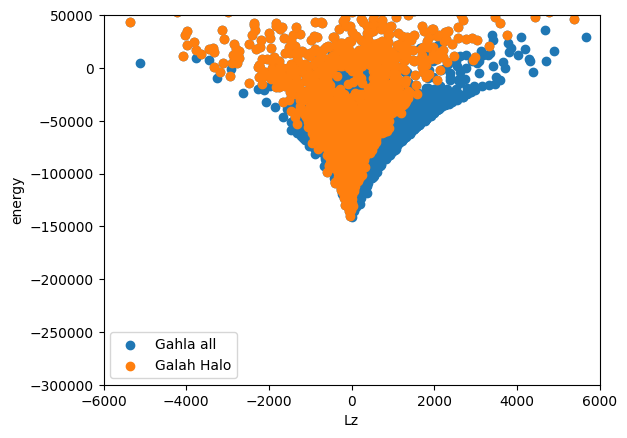

In [82]:
plt.scatter(galah_Gaia['Lz'], galah_Gaia['energy'], label = 'Gahla all')
# plt.scatter(Halo_Pradosh_galah_Gaia['Lz'], Halo_Pradosh_galah_Gaia['energy'], label = 'Galah Halo')
plt.scatter(galah_Gaia_Halo['Lz'], galah_Gaia_Halo['energy'], label = 'Galah Halo')
# plt.scatter(thickdisk_galah_Gaia['Lz'], thickdisk_galah_Gaia['energy'], label = 'Galah Thickdisk')

plt.xlim(-6000, 6000)
plt.ylim(-300000,50000)
plt.legend()
plt.xlabel('Lz')
plt.ylabel('energy');

In [83]:
print(len(galah_gaia_new_element_ratio_list))
print(len(galah_gaia_new_element_ratio_errors_list))

21
21


galah_Gaia_Halo: 2262 stars, 21 element ratios
galah_Gaia_GSE: 587 stars, 21 element ratios
galah_Gaia_Sequoia: 68 stars, 21 element ratios


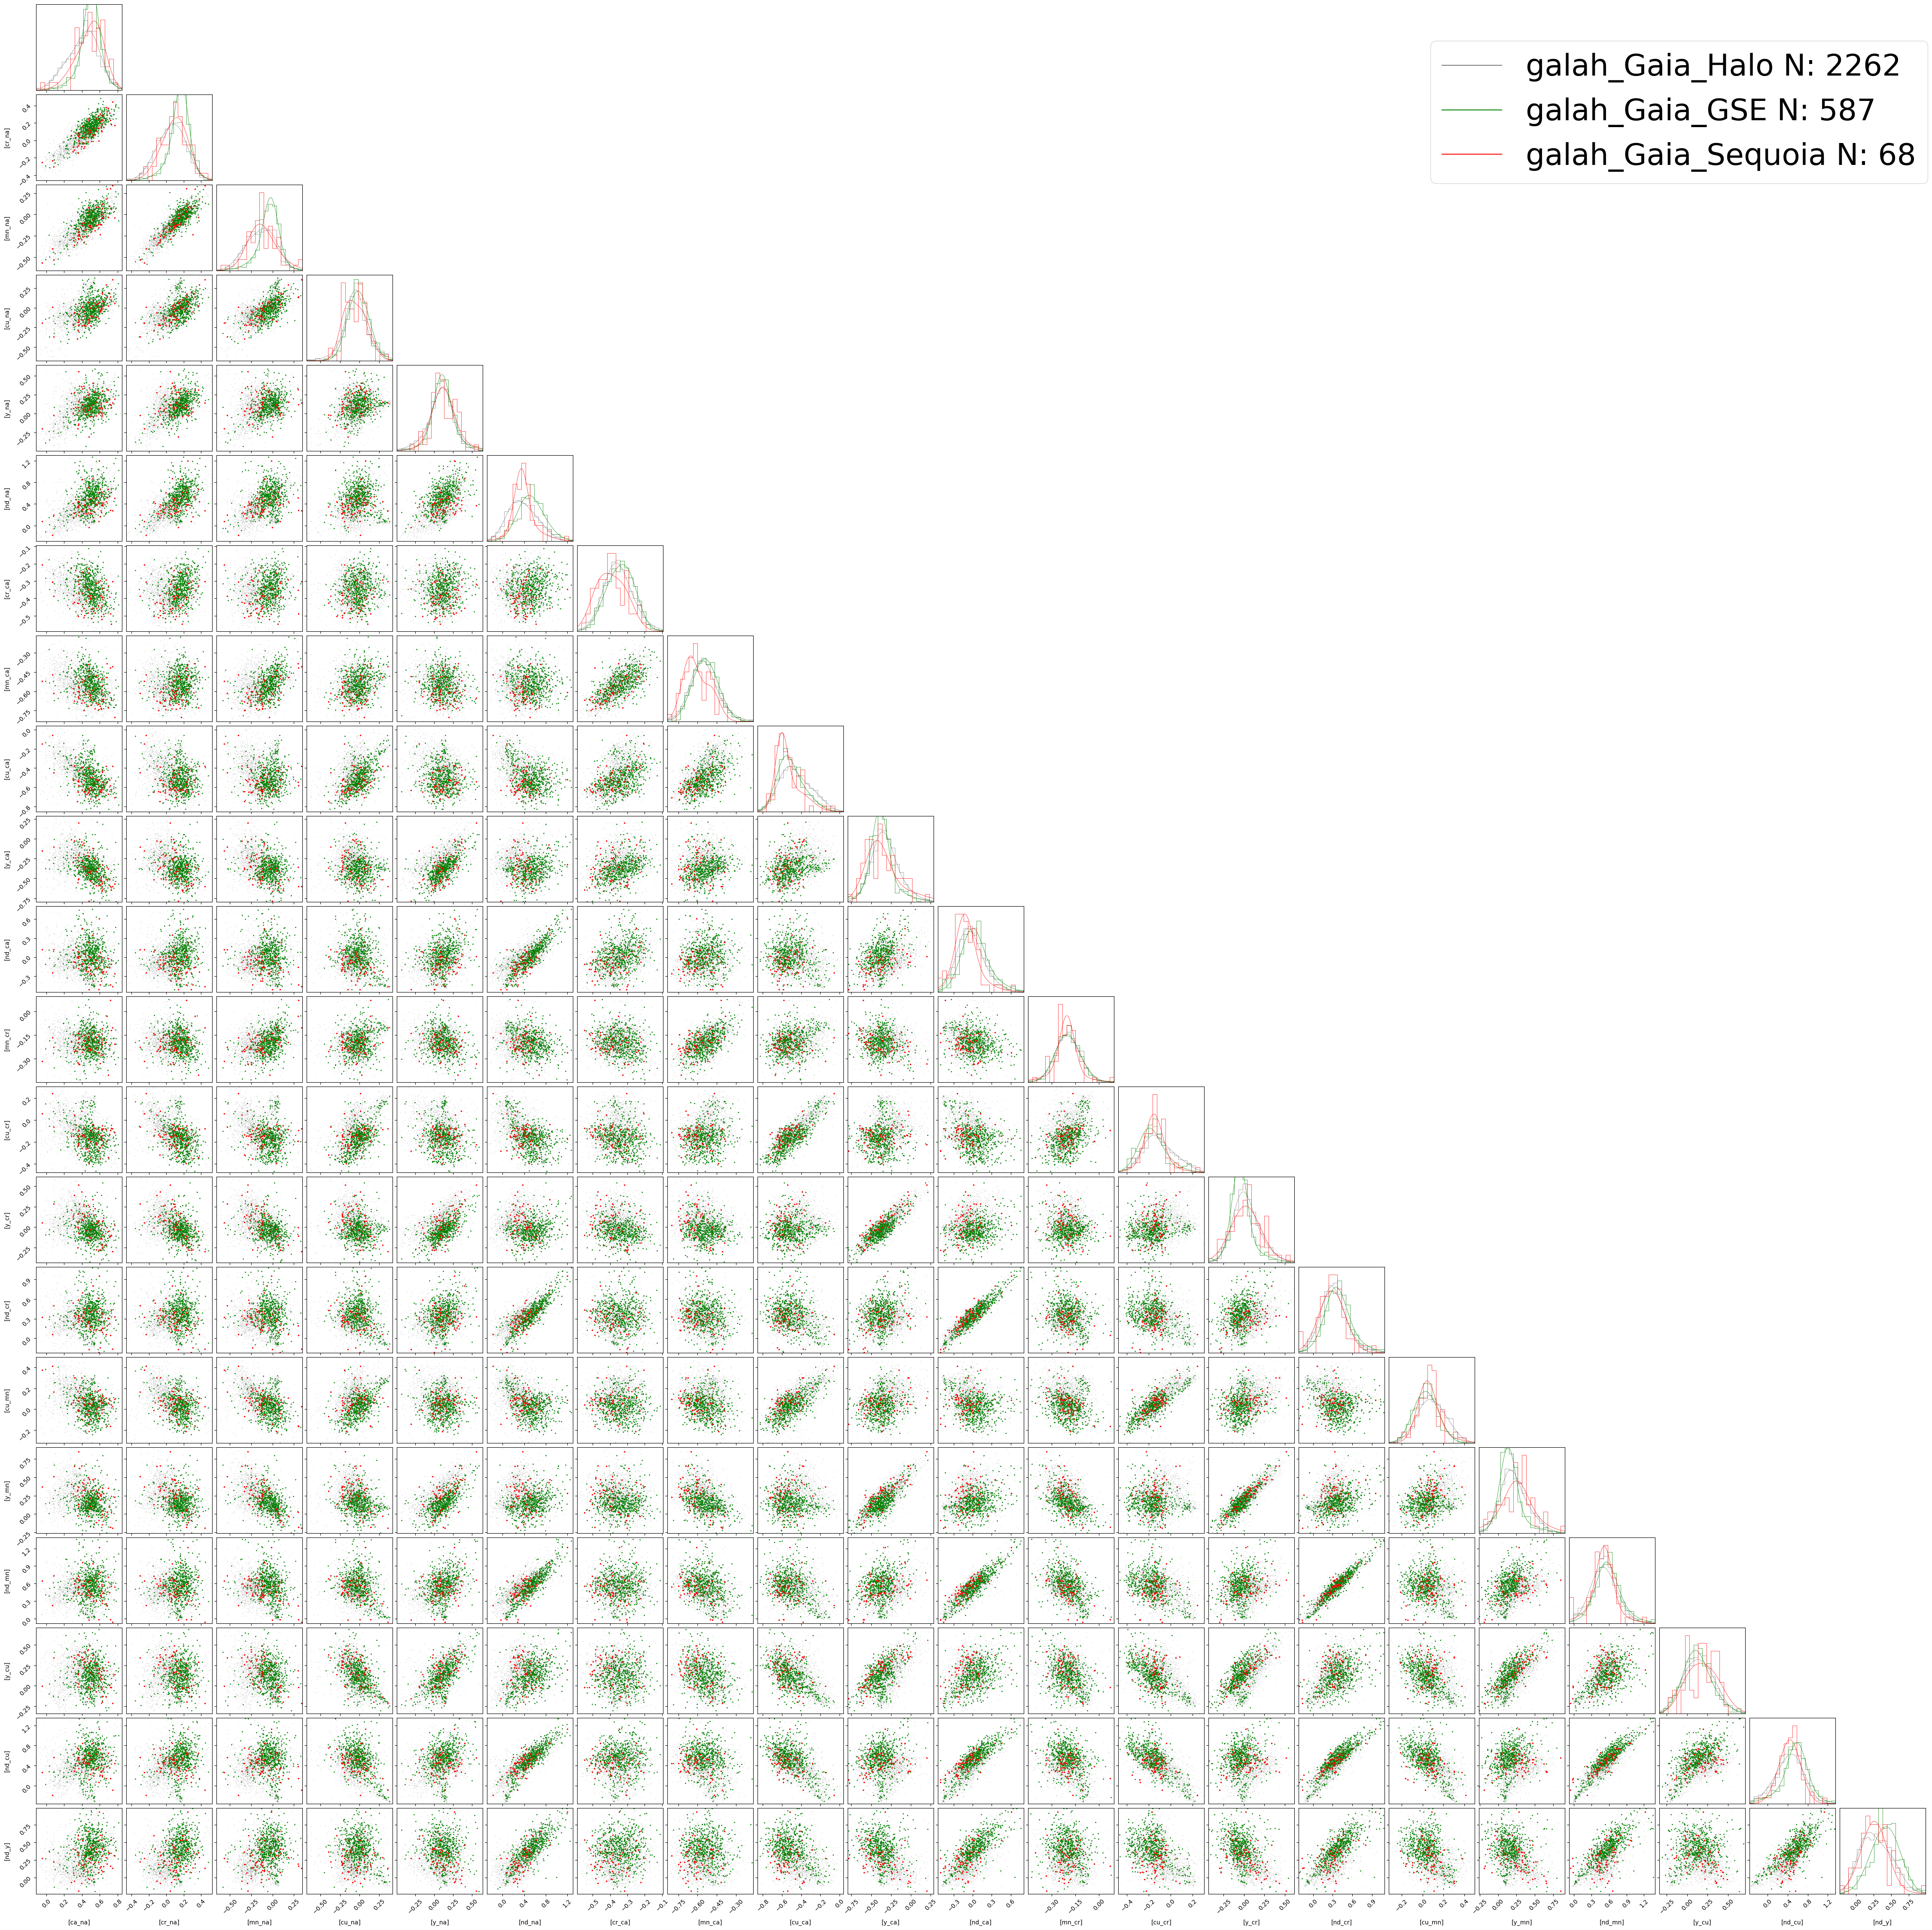

In [84]:
labels = [f'[{label}]' for label in galah_gaia_new_element_ratio_list]

first_plot = 'galah_Gaia_Halo' #pick one of the keys in corner_datasets
n_components = 2

corner_datasets = {
    # "galah_Halo": (Halo_Pradosh_galah_Gaia[galah_gaia_new_element_ratio_list], Halo_Pradosh_galah_Gaia[galah_gaia_new_element_ratio_errors_list],"blue", 2.5, 1.0),
    "galah_Gaia_Halo": (galah_Gaia_Halo_new_ratios[galah_gaia_new_element_ratio_list], galah_Gaia_Halo_new_ratios[galah_gaia_new_element_ratio_errors_list],"grey", 1, 0.5),
    # "galah_Thickdisk": (thickdisk_galah_Gaia[galah_gaia_new_element_ratio_list], thickdisk_galah_Gaia[galah_gaia_new_element_ratio_errors_list],"purple", 2.5, 1.0),
    "galah_Gaia_GSE": (galah_Gaia_GSE_new_ratios[galah_gaia_new_element_ratio_list], galah_Gaia_GSE_new_ratios[galah_gaia_new_element_ratio_errors_list],"green", 2.0, 1.0),
    "galah_Gaia_Sequoia": (galah_Gaia_Sequoia_new_ratios[galah_gaia_new_element_ratio_list], galah_Gaia_Sequoia_new_ratios[galah_gaia_new_element_ratio_errors_list],"red", 2.5, 1.0),
    # "galah_NGC5139": (galah_Gaia_NGC5139_new_ratios[galah_gaia_new_element_ratio_list], galah_Gaia_NGC5139_new_ratios[galah_gaia_new_element_ratio_errors_list],"blue", 2.5, 1.0),
    # "galah_NGC3201": (galah_Gaia_NGC3201_new_ratios[galah_gaia_new_element_ratio_list], galah_Gaia_NGC3201_new_ratios[galah_gaia_new_element_ratio_errors_list],"purple", 2.5, 1.0),
}

# keys = sorted(corner_datasets.keys())  # sorted = consistent colors across runs
# cmap = plt.cm.tab10
# colors = cmap(np.linspace(0, 0.8, len(keys)))

# for key, color in zip(keys, colors):
#     df_values, df_errors, _, ms, alpha = corner_datasets[key]
#     corner_datasets[key] = (df_values, df_errors, color, ms, alpha)
# # Convert all to values and keep data info

for key in corner_datasets:
    df_values, df_errors, color, ms, alpha = corner_datasets[key] #data frame, color, markersize, alpha

    vals = df_values.to_numpy()
    # vals, mask = filter_constant_columns(vals)
    errs = df_errors.to_numpy()
    row_mask = np.any(np.isfinite(vals), axis=1)
    vals = vals[row_mask]
    errs = errs[row_mask]
    print(f"{key}: {df_values.shape[0]} stars, {df_values.shape[1]} element ratios")
    corner_datasets[key] = (vals, errs, color, ms, alpha)
 
first_values, first_errors, first_color, first_ms, first_alpha = corner_datasets[first_plot]

    # Compute reasonable plotting ranges using percentiles
ranges = []

for dim in range(first_values.shape[1]):

    # combine all datasets for consistent limits
    combined = []

    for key, (values, errors, color, ms, alpha) in corner_datasets.items():
        combined.append(values[:, dim])

    combined = np.concatenate(combined)

    # remove NaNs/infs
    combined = combined[np.isfinite(combined)]

    # percentile clipping
    low = np.percentile(combined, 0.5)
    high = np.percentile(combined, 99.5)

    # optional padding
    padding = 0.05 * (high - low)

    ranges.append((low - padding, high + padding))

fig = corner.corner(
first_values,
labels=labels,
color=first_color,
range = ranges,
data_kwargs={'ms': first_ms, 'alpha': first_alpha, 'color': first_color},
hist_kwargs={"density": True, "histtype": "step", "linewidth": 0.5},
plot_datapoints=True,
plot_contours=False,
fill_contours=False,
plot_density=False,
)

ndim = first_values.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

def overlay_gaussian(values, errors, color, n_components):
    for i in range(ndim):
        ax = axes[i, i]
        x = values[:, i]
        sigma_x = errors[:, i]

        mask = np.isfinite(x) & np.isfinite(sigma_x)
        x = x[mask]

        if len(x) > 5:  # need enough points
            # Fit 2-component Gaussian Mixture
            gmm = GaussianMixture(n_components=n_components)
            gmm.fit(x.reshape(-1, 1))

            x_grid = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 500)

            pdf = np.zeros_like(x_grid)

            # Sum the two Gaussians
            for weight, mean, cov in zip(gmm.weights_, gmm.means_, gmm.covariances_):
                sigma = np.sqrt(cov[0][0])
                pdf += weight * norm.pdf(x_grid, mean[0], sigma)

                # (optional) plot individual components
                ax.plot(x_grid,
                        weight * norm.pdf(x_grid, mean[0], sigma),
                        color=color,
                        lw=1,
                        # ls='dashed',
                        ls = "none",
                        alpha=0.7)

            # Plot total mixture
            ax.plot(x_grid, pdf, color=color, lw=0.5)

# Overlay remaining datasets
handles = []
for key, (values, errors, color, ms, alpha) in corner_datasets.items():
    if key != first_plot:
        corner.corner(
            values,
            fig=fig,
            color=color,
            range = ranges,
            data_kwargs={'ms': ms, 'alpha': alpha, 'color': color},
            hist_kwargs={"density": True, "histtype": "step", "linewidth": 0.5},
            plot_datapoints=True,
            plot_contours=False,
            fill_contours=False,
            plot_density=False,
            show_titles=(key == "NGC3201"),
        )
    overlay_gaussian(values, errors, color, n_components)
    handles.append(plt.Line2D([0], [0], color = color, label = f'{key} N: {values.shape[0]}'))

fig.legend(handles=handles,
           loc="upper right",
           bbox_to_anchor=(1.0, 0.98),
        #    ncol=len(handles),
        #    frameon=False,
           fontsize=50)

['flag_fe_h', 'flag_ca_fe', 'flag_ti_fe', 'flag_si_fe', 'flag_na_fe', 'flag_mg_fe', 'flag_mn_fe', 'flag_al_fe', 'flag_ni_fe']
galah_Halo: 1070 stars, 9 element ratios
galah_Thickdisk: 1889 stars, 9 element ratios
galah_Gaia_GSE: 471 stars, 9 element ratios
galah_Gaia_Sequoia: 45 stars, 9 element ratios


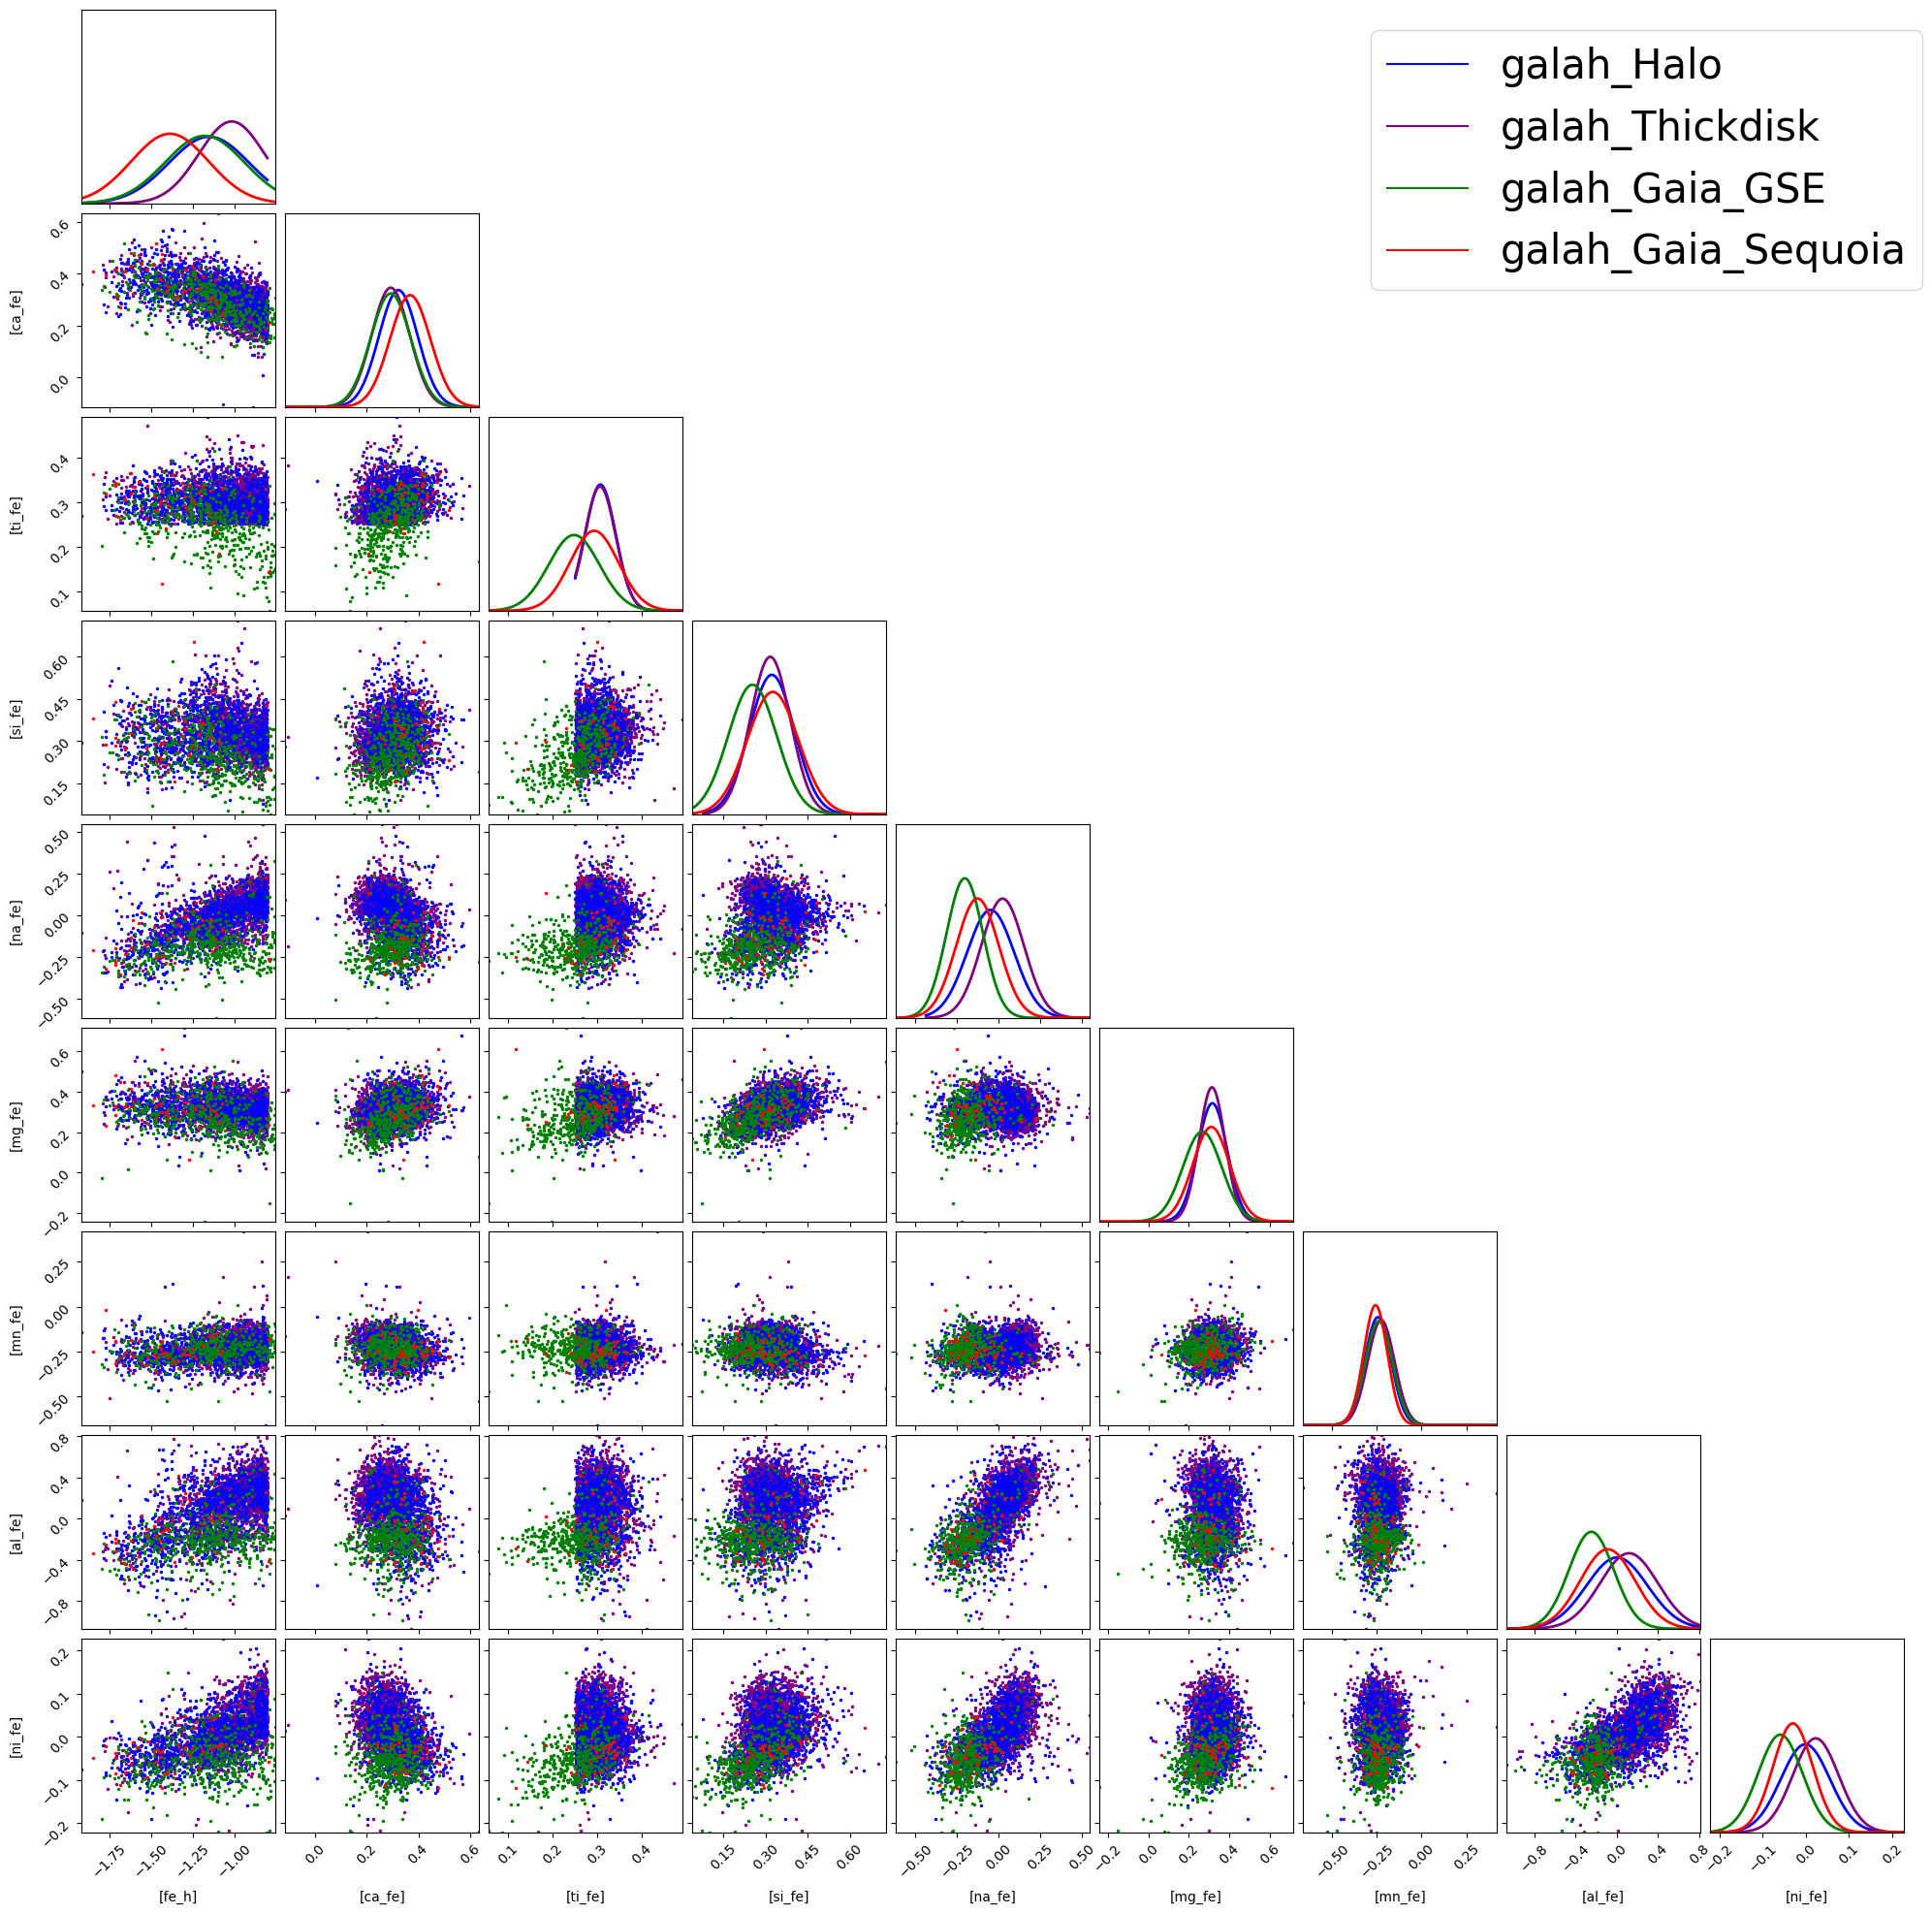

In [85]:
galah_normal_element_list = ['fe_h','ca_fe', 'ti_fe', 'si_fe','na_fe', 'mg_fe', 'mn_fe', 'al_fe','ni_fe']#, 'zr_fe', 'ce_fe', 'nd_fe']
galah_normal_element_list_errors = ['e_fe_h','e_ca_fe', 'e_ti_fe', 'e_si_fe','e_na_fe', 'e_mg_fe', 'e_mn_fe', 'e_al_fe', 'e_ni_fe']#, 'e_zr_fe', 'e_ce_fe', 'e_nd_fe']

Galah_x_flag = []
for i in galah_normal_element_list:
    Galah_x_flag.append("flag_" + i)
print(Galah_x_flag)
galah_Gaia_GSE_new_ratios_copy = galah_Gaia_GSE_new_ratios[galah_Gaia_GSE_new_ratios[Galah_x_flag] == 0]
galah_Gaia_Sequoia_new_ratios_copy = galah_Gaia_Sequoia_new_ratios[galah_Gaia_Sequoia_new_ratios[Galah_x_flag] == 0]

labels = [f'[{label}]' for label in galah_normal_element_list]

galah_Halo_copy = Halo_Pradosh_galah_Gaia.dropna(subset=galah_normal_element_list)
galah_Thickdisk_copy = thickdisk_galah_Gaia.dropna(subset=galah_normal_element_list)
galah_Gaia_GSE_new_ratios_copy = galah_Gaia_GSE_new_ratios.dropna(subset=galah_normal_element_list)
galah_Gaia_Sequoia_new_ratios_copy = galah_Gaia_Sequoia_new_ratios.dropna(subset=galah_normal_element_list)

labels = [f'[{label}]' for label in galah_normal_element_list]
first_plot = 'galah_Thickdisk' #pick one of the keys in corner_datasets
corner_datasets = {
    "galah_Halo": (galah_Halo_copy[galah_normal_element_list], galah_Halo_copy[galah_normal_element_list_errors],"blue", 2.5, 1.0),
    "galah_Thickdisk": (galah_Thickdisk_copy[galah_normal_element_list], galah_Thickdisk_copy[galah_normal_element_list_errors],"purple", 2.5, 1.0),
    "galah_Gaia_GSE": (galah_Gaia_GSE_new_ratios_copy[galah_normal_element_list], galah_Gaia_GSE_new_ratios_copy[galah_normal_element_list_errors],"green", 2.5, 1.0),
    "galah_Gaia_Sequoia": (galah_Gaia_Sequoia_new_ratios_copy[galah_normal_element_list], galah_Gaia_Sequoia_new_ratios_copy[galah_normal_element_list_errors],"red", 2.5, 1.0),
}

# keys = sorted(corner_datasets.keys())  # sorted = consistent colors across runs
# cmap = plt.cm.tab10
# colors = cmap(np.linspace(0, 0.8, len(keys)))

# for key, color in zip(keys, colors):
#     df_values, df_errors, _, ms, alpha = corner_datasets[key]
#     corner_datasets[key] = (df_values, df_errors, color, ms, alpha)
# # Convert all to values and keep data info

for key in corner_datasets:
    df_values, df_errors, color, ms, alpha = corner_datasets[key] #data frame, color, markersize, alpha

    vals = df_values.to_numpy()
    # vals, mask = filter_constant_columns(vals)
    errs = df_errors.to_numpy()
    row_mask = np.any(np.isfinite(vals), axis=1)
    vals = vals[row_mask]
    errs = errs[row_mask]
    print(f"{key}: {df_values.shape[0]} stars, {df_values.shape[1]} element ratios")
    corner_datasets[key] = (vals, errs, color, ms, alpha)
 
first_values, first_errors, first_color, first_ms, first_alpha = corner_datasets[first_plot]
fig = corner.corner(
first_values,
labels=labels,
color=first_color,
data_kwargs={'ms': first_ms, 'alpha': first_alpha, 'color': first_color},
hist_kwargs={"density": True, "histtype": "step", "linewidth": 0},
plot_datapoints=True,
plot_contours=False,
fill_contours=False,
plot_density=False,
)

ndim = first_values.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

# Function to overlay Gaussian
def overlay_gaussian(values, errors, color):
    for i in range(ndim):
        ax = axes[i, i]
        x = values[:, i]
        sigma_x = errors[:,i]
        mask = np.isfinite(x) & np.isfinite(sigma_x)
        x = x[mask]
        sigma_x = sigma_x[mask]
        if len(x) > 1:
            mu, sigma = weighted_avg_and_std(x, sigma_x) #now this should be weighting the errors better
            weights  = 1 / sigma_x**2
            x_grid = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 500)
            ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), color=color, lw=2)

# Overlay remaining datasets
handles = []
for key, (values, errors, color, ms, alpha) in corner_datasets.items():
    if key != first_plot:
        corner.corner(
            values,
            fig=fig,
            color=color,
            data_kwargs={'ms': ms, 'alpha': alpha, 'color': color},
            hist_kwargs={"density": True, "histtype": "step", "linewidth": 0},
            plot_datapoints=True,
            plot_contours=False,
            fill_contours=False,
            plot_density=False,
            # show_titles=(key == "galah_Gaia_GSE"),
        )
    overlay_gaussian(values, errors, color)
    handles.append(plt.Line2D([0], [0], color = color, label = key))

fig.legend(handles=handles,
           loc="upper right",
           bbox_to_anchor=(1.0, 0.98),
        #    ncol=len(handles),
        #    frameon=False,
           fontsize=30)

In [86]:
"""I wasn't able to run Closest_E_vs_Lz_to_NGC3201 in the cell above. This was becasue for some reason the corner plots
will use the line of code below to make sure that the sample size is larger than the number of rows I want. In this case i had fewer
stars in the sample than the elemental ratios so it was unahppy.
"""
print(corner.core.__file__)
#     # assert xs.shape[0] <= xs.shape[1], (
#     #     "I don't believe that you want more " "dimensions than samples!"
#     # )

/home/simon/miniconda3/envs/environment_trial1/lib/python3.14/site-packages/corner/core.py


In [87]:
galah_Gaia_GSE_new_ratios

,sobject_id,tmass_id,gaiadr3_source_id,survey_name,field_id,setup,mjd,ra,dec,flag_sp,...,y_mn,e_y_mn,nd_mn,e_nd_mn,y_cu,e_y_cu,nd_cu,e_nd_cu,nd_y,e_nd_y
10287,170313001601294,08535559+0338561,581156354149637504,galah_main,6210,allstar,57825.492,133.481674,3.648889,0,...,0.290193,0.104740,0.727932,0.081295,0.165184,0.095430,0.602923,0.068887,0.437739,0.097484
10474,160107004101063,08523562+1044332,598611513556606720,k2_hermes,6605,allstar,57394.700,133.148453,10.742556,0,...,0.161873,0.077561,0.649218,0.077943,0.402804,0.082040,0.890149,0.082402,0.487345,0.094375
11852,150408002901015,08313856+1100042,602362669273900800,k2_hermes,6614,allstar,57120.395,127.910706,11.001194,0,...,0.105809,0.087178,0.476410,0.113323,-0.050490,0.101233,0.320110,0.124461,0.370600,0.136118
11934,150408002901355,08295803+1123164,602447713922666880,k2_hermes,6614,allstar,57120.395,127.491791,11.387917,0,...,0.144477,0.108257,0.384734,0.112977,0.074853,0.133243,0.315110,0.137105,0.240256,0.144299
14255,160331002701217,08504264+1653054,611725599195677184,k2_hermes,6606,allstar,57478.473,132.677704,16.884832,0,...,0.204577,0.064196,0.487392,0.067825,0.095278,0.062000,0.378093,0.065751,0.282815,0.075389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910500,220709003601114,21265968-1333108,6842644765302755840,galah_main,174,allstar,59769.700,321.748718,-13.553000,0,...,0.012989,0.078288,0.430044,0.139819,0.046402,0.077571,0.463457,0.139419,0.417055,0.147507
911311,150901001901091,20081043-2456473,6850666836501090432,galah_main,1052,allstar,57266.504,302.043488,-24.946472,0,...,0.085690,0.080330,0.408115,0.111109,0.059995,0.073935,0.382420,0.106578,0.322425,0.117837
912285,230806003201278,20334285-2257429,6854889442189029376,galah_main,598,allstar,60162.586,308.428680,-22.961971,0,...,0.216305,0.070490,0.624575,0.129479,0.341793,0.072002,0.750064,0.130309,0.408271,0.136383
913871,220808003201095,21070337-1152327,6889059716660462208,galah_main,431,allstar,59799.594,316.764160,-11.875778,0,...,0.434463,0.075331,0.854511,0.088709,0.386815,0.092911,0.806863,0.104052,0.420048,0.106465


In [88]:
for i in galah_normal_element_list: 
    print(i, "   ", np.isnan(galah_Gaia_GSE_new_ratios[i]).sum())
    

fe_h     0
ca_fe     0
ti_fe     0
si_fe     0
na_fe     0
mg_fe     0
mn_fe     0
al_fe     116
ni_fe     0


In [89]:
# element_list = Pradosh_normal_element_list
# element_list_errors = Pradosh_normal_element_list_errors

element_list = []
element_list_copy = galah_gaia_new_element_ratio_list


for i in element_list_copy:
    if i  != 'fe_h':
        print(i)
        element_list.append(i)

element_list_errors = galah_gaia_new_element_ratio_errors_list

feature_cols = element_list

cut_to_use = {
    "Halo": galah_Gaia_Halo_new_ratios,
    # "Thick_disk": thickdisk_Pradosh,
    "GSE": galah_Gaia_GSE_new_ratios,
    # "Sequoia": galah_Gaia_Sequoia_new_ratios,
    # "NGC5239": galah_Gaia_NGC5139_new_ratios,
    # "NGC3201": galah_Gaia_NGC3201_new_ratios, # 3201 wont run becasue galah doesn't have any of those stars
}

# Combine the clusters into a single DataFrame
df_list = []
for Group_Name, df in cut_to_use.items():
    df_copy = df.copy()
    df_copy["Group_Name"] = Group_Name  # label column
    df_list.append(df_copy)

df_all = pd.concat(df_list, ignore_index=True)
final_output = []
for ratio1 in range(len(feature_cols)):
    for ratio2 in range(ratio1+1,len(feature_cols)):
        for ratio3 in range(ratio2+1,len(feature_cols)):
            # for ratio4 in range(ratio3+1,len(feature_cols)):

                col1 = feature_cols[ratio1]
                col2 = feature_cols[ratio2]
                col3 = feature_cols[ratio3]
                # col4 = feature_cols[ratio4]
                
                print(f'{col1}, {col2}, {col3}')
                # print(f'{col1}, {col2}, {col3}, {col4}')

                X = df_all[[col1, col2, col3]]#.copy()
                # X = df_all[[col1, col2, col3, col4]]#.copy()
                y = df_all["Group_Name"]#.copy()

                # Remove rows where the feature is NaN
                # mask = X[feature_cols[ratio1], feature_cols[ratio2]].notna()
                # X = X[mask]
                # y = y[mask]

                # Split into train/test sets
                test_size = 0.2 if X.shape[0] > 10 else 0.1  # adjust test size for very small clusters
                X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=test_size, random_state=42, stratify=y
                )

                # Train Random Forest classifier
                clf = RandomForestClassifier(n_estimators=500, 
                                            random_state=42,
                                            n_jobs=-1   # <-- uses all cores
                                            )
                clf.fit(X_train, y_train)

                # Predict and calculate accuracy
                y_pred = clf.predict(X_test)
                acc = accuracy_score(y_test, y_pred)
                final_output.append({
                "ratio1": col1,
                "ratio2": col2,
                "ratio3": col3,
                # "ratio4": col4,
                "accuracy": acc
                })
final_output = pd.DataFrame(final_output)
final_output = final_output.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)

final_output_Galah = final_output

ca_na
cr_na
mn_na
cu_na
y_na
nd_na
cr_ca
mn_ca
cu_ca
y_ca
nd_ca
mn_cr
cu_cr
y_cr
nd_cr
cu_mn
y_mn
nd_mn
y_cu
nd_cu
nd_y
ca_na, cr_na, mn_na
ca_na, cr_na, cu_na
ca_na, cr_na, y_na
ca_na, cr_na, nd_na
ca_na, cr_na, cr_ca
ca_na, cr_na, mn_ca
ca_na, cr_na, cu_ca
ca_na, cr_na, y_ca
ca_na, cr_na, nd_ca
ca_na, cr_na, mn_cr
ca_na, cr_na, cu_cr
ca_na, cr_na, y_cr
ca_na, cr_na, nd_cr
ca_na, cr_na, cu_mn
ca_na, cr_na, y_mn
ca_na, cr_na, nd_mn
ca_na, cr_na, y_cu
ca_na, cr_na, nd_cu
ca_na, cr_na, nd_y
ca_na, mn_na, cu_na
ca_na, mn_na, y_na
ca_na, mn_na, nd_na
ca_na, mn_na, cr_ca
ca_na, mn_na, mn_ca
ca_na, mn_na, cu_ca
ca_na, mn_na, y_ca
ca_na, mn_na, nd_ca
ca_na, mn_na, mn_cr
ca_na, mn_na, cu_cr
ca_na, mn_na, y_cr
ca_na, mn_na, nd_cr
ca_na, mn_na, cu_mn
ca_na, mn_na, y_mn
ca_na, mn_na, nd_mn
ca_na, mn_na, y_cu
ca_na, mn_na, nd_cu
ca_na, mn_na, nd_y
ca_na, cu_na, y_na
ca_na, cu_na, nd_na
ca_na, cu_na, cr_ca
ca_na, cu_na, mn_ca
ca_na, cu_na, cu_ca
ca_na, cu_na, y_ca
ca_na, cu_na, nd_ca
ca_na, cu_na, 

In [90]:
# for i in galah_gaia_new_element_ratio_list:
#     print(i)

len(feature_cols)

21

In [91]:
print(len(final_output))

1330


In [ ]:
with pd.option_context('display.max_rows', None):
    print(final_output_Galah)

     ratio1 ratio2 ratio3  accuracy
0     cr_ca  cu_sc   ba_v  0.972332
1      v_ca  cu_sc   cu_v  0.972332
2      v_ca  cu_sc  ba_cr  0.972332
3      cu_k  cr_ca  cr_sc  0.970356
4      cu_k  ba_ca  ba_cr  0.970356
5      cu_k  ba_ca  cu_cr  0.970356
6      cu_k  ba_sc  ba_cr  0.970356
7      cu_k  ba_sc  cu_cr  0.970356
8      cu_k  ba_sc   ba_v  0.970356
9      cu_k  ba_sc   cu_v  0.970356
10     cu_k  ba_sc   cr_v  0.970356
11     cu_k  cu_sc  ba_cu  0.970356
12     cu_k  cu_sc  ba_cr  0.970356
13     cu_k  cu_sc  cu_cr  0.970356
14     cu_k  cu_sc   ba_v  0.970356
15     cu_k  cu_sc   cu_v  0.970356
16     cu_k  cu_sc   cr_v  0.970356
17     cu_k  ba_ca  ba_cu  0.970356
18     ba_k  sc_ca  cu_ca  0.970356
19     ba_k  sc_ca   v_ca  0.970356
20     cu_k  cr_sc  ba_cr  0.970356
21     cu_k  cr_sc  cu_cr  0.970356
22     cu_k  cr_sc   ba_v  0.970356
23     cu_k  ba_cr  ba_cu  0.970356
24     cu_k  cu_cr  ba_cu  0.970356
25     cu_k  cu_cr  ba_cr  0.970356
26     cu_k   cr_v   ba_v  0

In [92]:
# ''' MINI CORNER PLOTS '''
# labels = ['fe_h', 'mn_fe', 'cu_fe'] # best
# # labels = ['cu_fe', 'mg_ca', 'nd_mg'] # 2nd best
# # labels = ['fe_h', 'ca_fe', 'cu_fe'] # 3rd best
# # labels = ['fe_h', 'cu_fe', 'mn_ca'] # 4th best
# # labels = ['fe_h', 'mg_ca', 'nd_na'] # 5th best


# labels = ['TiCa', 'NiSi', 'cu_fe'] # best
# labels = ['cu_fe', 'mg_ca', 'nd_mg'] # 2nd best
# # labels = ['fe_h', 'ca_fe', 'cu_fe'] # 3rd best
# # labels = ['fe_h', 'cu_fe', 'mn_ca'] # 4th best
# # labels = ['fe_h', 'mg_ca', 'nd_na'] # 5th best
# e_labels = []
# for i in labels:
#     e_labels.append('e_' + i)

# first_plot = 'galah_Gaia_Halo' #pick one of the keys in corner_datasets
# n_components = 2

''' MINI CORNER PLOTS '''

# e_labels = []
# for i in labels:
#     e_labels.append('e_' + i)
sample_set = final_output_Galah
TOP_50_ = top_min_corner_plots(sample_set, 50)
TOP_lables = min_corner_plot_lables_comparison(sample_set, 50, "accuracy")
parent_folder = "/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots"

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_folder = os.path.join(
    parent_folder,
    f"{timestamp}_Galah_Sequoia_vs_Halo_3d_Na_Ca_Cr_Mn_Cu_Y_Nd_also_fe_is_lessthan_minus0.75_galah_phase_1_2_Hermes"
)                                      # This contains the name of the folder
os.makedirs(save_folder, exist_ok=True)

# Save sample_set to the same folder
sample_set.to_csv(
    os.path.join(save_folder, "full_csv.csv"),
    index=False
)
for i in range(len(TOP_lables[0])):
    labels = TOP_lables[0][i]
    e_labels = TOP_lables[1][i]
    accuracy = TOP_lables[2][i]

    first_plot = 'galah_Gaia_Halo' #pick one of the keys in corner_datasets
    n_components = 2

    corner_datasets = {
        "galah_Gaia_Halo": (galah_Gaia_Halo_new_ratios[labels], galah_Gaia_Halo_new_ratios[e_labels],"grey", 1, 0.75),
        # "galah_Thickdisk": (thickdisk_galah_Gaia[labels], thickdisk_galah_Gaia[e_labels],"purple", 2.5, 1.0),
        "galah_Gaia_GSE": (galah_Gaia_GSE_new_ratios[labels], galah_Gaia_GSE_new_ratios[e_labels],"green", 5, 1.0),
        "galah_Gaia_Sequoia": (galah_Gaia_Sequoia_new_ratios[labels], galah_Gaia_Sequoia_new_ratios[e_labels],"red", 5, 1.0),
        # "galah_NGC5139": (galah_Gaia_NGC5139_new_ratios[labels], galah_Gaia_NGC5139_new_ratios[e_labels],"blue", 2.5, 1.0),
        # "galah_NGC3201": (galah_Gaia_NGC3201_new_ratios[labels], galah_Gaia_NGC3201_new_ratios[e_labels],"purple", 2.5, 1.0),
    }

    # keys = sorted(corner_datasets.keys())  # sorted = consistent colors across runs
    # cmap = plt.cm.tab10
    # colors = cmap(np.linspace(0, 0.8, len(keys)))

    # for key, color in zip(keys, colors):
    #     df_values, df_errors, _, ms, alpha = corner_datasets[key]
    #     corner_datasets[key] = (df_values, df_errors, color, ms, alpha)
    # # Convert all to values and keep data info

    for key in corner_datasets:
        df_values, df_errors, color, ms, alpha = corner_datasets[key] #data frame, color, markersize, alpha

        vals = df_values.to_numpy()
        # vals, mask = filter_constant_columns(vals)
        errs = df_errors.to_numpy()
        row_mask = np.any(np.isfinite(vals), axis=1)
        vals = vals[row_mask]
        errs = errs[row_mask]
        print(f"{key}: {df_values.shape[0]} stars, {df_values.shape[1]} element ratios")
        corner_datasets[key] = (vals, errs, color, ms, alpha)

        
    
    first_values, first_errors, first_color, first_ms, first_alpha = corner_datasets[first_plot]

    # Compute reasonable plotting ranges using percentiles
    ranges = []

    for dim in range(first_values.shape[1]):

        # combine all datasets for consistent limits
        combined = []

        for key, (values, errors, color, ms, alpha) in corner_datasets.items():
            combined.append(values[:, dim])

        combined = np.concatenate(combined)

        # remove NaNs/infs
        combined = combined[np.isfinite(combined)]

        # percentile clipping
        low = np.percentile(combined, 3)
        high = np.percentile(combined, 97)

        # optional padding
        padding = 0.05 * (high - low)

        ranges.append((low - padding, high + padding))

    fig = corner.corner(
    first_values,
    labels=labels,
    range=ranges,
    color=first_color,
    data_kwargs={'ms': first_ms, 'alpha': first_alpha, 'color': first_color},
    hist_kwargs={"density": True, "histtype": "step", "linewidth": 0.5},
    plot_datapoints=True,
    plot_contours=False,
    fill_contours=False,
    plot_density=False,
    )

    ACC = round(accuracy, 4)
    fig.suptitle(f'Accuracy: {ACC}', fontsize=16, y=0.98)
    
    ndim = first_values.shape[1]
    axes = np.array(fig.axes).reshape((ndim, ndim))

    # Function to overlay Gaussian
    # def overlay_gaussian(values, errors, color):
    #     for i in range(ndim):
    #         ax = axes[i, i]
    #         x = values[:, i]
    #         sigma_x = errors[:,i]
    #         mask = np.isfinite(x) & np.isfinite(sigma_x)
    #         x = x[mask]
    #         sigma_x = sigma_x[mask]
    #         if len(x) > 1:
    #             mu, sigma = weighted_avg_and_std(x, sigma_x) #now this should be weighting the errors better
    #             weights  = 1 / sigma_x**2
    #             x_grid = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 500)
    #             ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), color=color, lw=2)

    def overlay_gaussian(values, errors, color, n_components):
        for i in range(ndim):
            ax = axes[i, i]
            x = values[:, i]
            sigma_x = errors[:, i]

            mask = np.isfinite(x) & np.isfinite(sigma_x)
            x = x[mask]

            if len(x) > 5:  # need enough points
                # Fit 2-component Gaussian Mixture
                gmm = GaussianMixture(n_components=n_components)
                gmm.fit(x.reshape(-1, 1))

                x_grid = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 500)

                pdf = np.zeros_like(x_grid)

                # Sum the two Gaussians
                for weight, mean, cov in zip(gmm.weights_, gmm.means_, gmm.covariances_):
                    sigma = np.sqrt(cov[0][0])
                    pdf += weight * norm.pdf(x_grid, mean[0], sigma)

                    # (optional) plot individual components
                    ax.plot(x_grid,
                            weight * norm.pdf(x_grid, mean[0], sigma),
                            color=color,
                            lw=1,
                            # ls='dashed',
                            ls = "none",
                            alpha=0.7)

                # Plot total mixture
                ax.plot(x_grid, pdf, color=color, lw=0.5)

    # Overlay remaining datasets
    handles = []
    for key, (values, errors, color, ms, alpha) in corner_datasets.items():
        if key != first_plot:
            corner.corner(
                values,
                fig=fig,
                color=color,
                range=ranges,
                data_kwargs={'ms': ms, 'alpha': alpha, 'color': color},
                hist_kwargs={"density": True, "histtype": "step", "linewidth": 0.5},
                plot_datapoints=True,
                plot_contours=False,
                fill_contours=False,
                plot_density=False,
                show_titles=(key == "NGC3201"),
            )
        overlay_gaussian(values, errors, color, n_components)
        handles.append(plt.Line2D([0], [0], color = color, label = f'{key} N: {values.shape[0]}'))

    fig.legend(handles=handles,
            loc="upper right",
            bbox_to_anchor=(1.0, 0.98),
            #    ncol=len(handles),
            #    frameon=False,
            fontsize=12)
    
    # Save into new folder
    plt.savefig(os.path.join(save_folder, f"plot_{i}_{labels}.png"))

    plt.close()

galah_Gaia_Halo: 2262 stars, 3 element ratios
galah_Gaia_GSE: 587 stars, 3 element ratios
galah_Gaia_Sequoia: 68 stars, 3 element ratios
galah_Gaia_Halo: 2262 stars, 3 element ratios
galah_Gaia_GSE: 587 stars, 3 element ratios
galah_Gaia_Sequoia: 68 stars, 3 element ratios
galah_Gaia_Halo: 2262 stars, 3 element ratios
galah_Gaia_GSE: 587 stars, 3 element ratios
galah_Gaia_Sequoia: 68 stars, 3 element ratios
galah_Gaia_Halo: 2262 stars, 3 element ratios
galah_Gaia_GSE: 587 stars, 3 element ratios
galah_Gaia_Sequoia: 68 stars, 3 element ratios
galah_Gaia_Halo: 2262 stars, 3 element ratios
galah_Gaia_GSE: 587 stars, 3 element ratios
galah_Gaia_Sequoia: 68 stars, 3 element ratios
galah_Gaia_Halo: 2262 stars, 3 element ratios
galah_Gaia_GSE: 587 stars, 3 element ratios
galah_Gaia_Sequoia: 68 stars, 3 element ratios
galah_Gaia_Halo: 2262 stars, 3 element ratios
galah_Gaia_GSE: 587 stars, 3 element ratios
galah_Gaia_Sequoia: 68 stars, 3 element ratios
galah_Gaia_Halo: 2262 stars, 3 element ra

In [ ]:
previos_values_lcation = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/plots/20260520_012632_Galah_GSE_vs_Sequoia_vs_Halo_4d_cu_ca_mn_ti_ba_na_and_nd_also_fe_is_lessthan_minus0.8/full_csv.csv'

previous_values_raw = pd.read_csv(previos_values_lcation)

In [ ]:
hbvbse = previous_values_raw[(previous_values_raw['ratio1'] == 'na_cu')
                            & (previous_values_raw['ratio2'] == 'nd_cu')
                            & (previous_values_raw['ratio3'] == 'ti_mn')
                            & (previous_values_raw['ratio4'] == 'nd_na')
                            ]

# hbvbse = previous_values_raw[(previous_values_raw['ratio1'] == 'ca_cu')
#                             & (previous_values_raw['ratio2'] == 'nd_cu')
#                             & (previous_values_raw['ratio3'] == 'ti_mn')
#                             & (previous_values_raw['ratio4'] == 'nd_na')
#                             ]

# hbvbse = final_output_Galah[(final_output_Galah['accuracy'] > 0.863635)
#                             & (final_output_Galah['accuracy'] <0.863637)
#                             ]
# print(len(hbvbse))
hbvbse

In [ ]:
hbvbse = final_output_Galah[(final_output_Galah['ratio1'] == 'na_cu')
                            & (final_output_Galah['ratio2'] == 'nd_cu')
                            & (final_output_Galah['ratio3'] == 'ti_mn')
                            & (final_output_Galah['ratio4'] == 'nd_na')
                            ]

# hbvbse = final_output_Galah[(final_output_Galah['ratio1'] == 'ca_cu')
#                             & (final_output_Galah['ratio2'] == 'nd_cu')
#                             & (final_output_Galah['ratio3'] == 'ti_mn')
#                             & (final_output_Galah['ratio4'] == 'nd_na')
#                             ]

hbvbse

In [ ]:
match_cols = ['ratio1', 'ratio2', 'ratio3', 'ratio4']

previous_values_raw_sorted = (
    previous_values_raw
    .set_index(match_cols)
    .loc[final_output_Galah.set_index(match_cols).index]
    .reset_index()
)

p_value_comparison = previous_values_raw_sorted.merge(
    final_output_Galah[match_cols + ['accuracy']],
    on=match_cols,
    suffixes=('_GSE_Sequoia', '_all_3')
)

print(p_value_comparison)

#pd.to_csv(p_value_comparison)
# p_value_comparison.to_csv("merged_table_accuracies.csv", index = False)


In [ ]:

plt.scatter(p_value_comparison['accuracy_all_3'], p_value_comparison['accuracy_GSE_Sequoia'])

In [ ]:
plt.scatter(galah_Gaia_GSE_new_ratios['teff'], galah_Gaia_GSE_new_ratios['ba_fe'])

In [ ]:
plt.hist(galah_Gaia_new_ratios['logg'], bins = 40, density = True, alpha = 0.5, label = 'all')
plt.hist(galah_Gaia_GSE['logg'], bins = 40, density = True, alpha = 0.3, label = 'GSE')
plt.hist(galah_Gaia_Sequoia['logg'], bins = 40, density = True, alpha = 0.3, label = 'Sequoia')

plt.legend()

In [ ]:
galah_pradosh_match_GSE = pd.merge(galah_Gaia_GSE, Pradosh_GSE, left_on ="gaiadr3_source_id", right_on = 'source_id', how="inner")
galah_pradosh_match_Sequoia = pd.merge(galah_Gaia_Sequoia, Pradosh_Sequoia, left_on ="gaiadr3_source_id", right_on = 'source_id', how="inner")

In [ ]:
Pradosh_GSE.columns

In [ ]:
galah_pradosh_match_GSE

In [ ]:
galah_pradosh_match_Sequoia

In [ ]:
element_ratio = 'mg_ca'
plt.figure(figsize=(10, 6))

plot_gmm(galah_Gaia_GSE_new_ratios[element_ratio], 'Galah_GSE', 'g', 2)
plot_hist(galah_Gaia_GSE_new_ratios[element_ratio], 'Galah_GSE', 'g', 0.5)

plot_gmm(galah_Gaia_Sequoia_new_ratios[element_ratio], 'Galah_Sequoi', 'r', 2)
plot_hist(galah_Gaia_Sequoia_new_ratios[element_ratio], 'Galah_Sequoi', 'r', 0.5)

plot_gmm(galah_Gaia_Thamnos1_new_ratios[element_ratio], 'Galah_Thamnos1', 'b', 2)
plot_hist(galah_Gaia_Thamnos1_new_ratios[element_ratio], 'Galah_Thamnos1', 'b', 0.5)

plt.xlabel(element_ratio)
plt.ylabel('Density')
plt.title(f'Galah {element_ratio} Distribution')
plt.legend()

In [ ]:
plt.figure(figsize=(10, 6))

elm_ratio1 = 'na_fe'
elm_ratio2 = 'mg_cu'

plt.scatter(galah_Gaia_new_ratios[elm_ratio1], galah_Gaia_new_ratios[elm_ratio2], color = 'blue', label = 'All Galah', s = 0.3, alpha = 0.2)
# plt.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], color = 'g', label = 'GSE', s = 10)
# plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = 'r', label = 'Sequoia', s = 10)

# plt.scatter(galah_Gaia_Thamnos1_new_ratios[elm_ratio1], galah_Gaia_Thamnos1_new_ratios[elm_ratio2], color = 'g', label = 'Thamnos1', s = 15)
# plt.scatter(galah_Gaia_Thamnos2_new_ratios[elm_ratio1], galah_Gaia_Thamnos2_new_ratios[elm_ratio2], color = 'r', label = 'Thamnos2', s = 15)

plt.scatter(galah_Gaia_Kushniruk_GSE_new_ratios[elm_ratio1], galah_Gaia_Kushniruk_GSE_new_ratios[elm_ratio2], color = 'g', label = 'GSE', s = 10)
plt.plot([-0.67857, 0.3869047], [-0.32405, 0.815189], linewidth = 3, c = 'k', label = 'Iryna fig 3')
plt.plot([-0.686, 0.685], [-0.476, 1.072], linestyle='--',   linewidth = 3, c = 'k', label = 'Iryna fig 4')

plt.xlabel(F'{elm_ratio1}')
plt.ylabel(F'{elm_ratio2}')
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    if hasattr(handle, "set_sizes"):
        handle.set_sizes([30])
plt.xlim(-0.6,0.6)
plt.ylim(-0.4,1)

/tmp/ipykernel_8065/3951597823.py:109: UserWarning: Adding colorbar to a different Figure <Figure size 1000x600 with 13 Axes> than <Figure size 1000x600 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(sp)



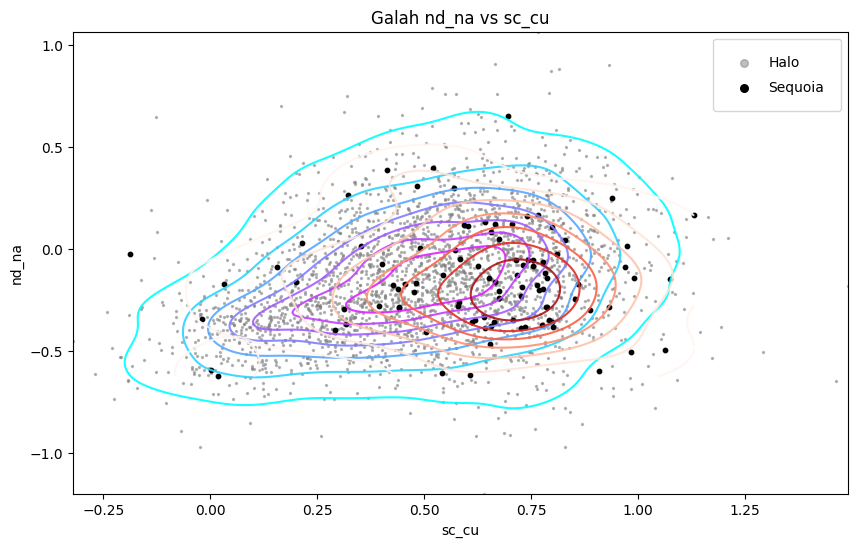

In [46]:
fig,ax = plt.subplots(figsize=(10, 6))

elm_ratio1 = 'na_fe'
elm_ratio2 = 'mg_mn'

# elm_ratio1 = 'na_ca'
# elm_ratio2 = 'mn_ca'

# elm_ratio1 = 'mn_ca'
# elm_ratio2 = 'nd_ca'

elm_ratio1 = 'nd_fe'
elm_ratio2 = 'nd_ca'

# elm_ratio1 = 'ca_fe'
# elm_ratio2 = 'nd_mg'

# elm_ratio1 = 'mn_na'
# elm_ratio2 = 'cu_na'

# elm_ratio1 = 'na_fe'
# elm_ratio2 = 'cu_na'

elm_ratio1 = 'nd_ca'
elm_ratio2 = 'mn_na'

elm_ratio1 = 'fe_h'
# elm_ratio2 = 'nd_cu'
elm_ratio2 = 'ca_fe'

elm_ratio1 = 'sc_cu'
elm_ratio2 = 'nd_na'
elm_ratio3 = 'v_ca'
elm_ratio4 = 'ti_mn'


# plt.scatter(galah_Gaia_new_ratios[elm_ratio1], galah_Gaia_new_ratios[elm_ratio2], color = 'grey', label = 'All Galah', s = 0.3, alpha = 0.2)

plt.scatter(galah_Gaia_Halo_new_ratios[elm_ratio1] - galah_Gaia_Halo_new_ratios[elm_ratio3], galah_Gaia_Halo_new_ratios[elm_ratio2]- galah_Gaia_Halo_new_ratios[elm_ratio4], color = 'grey', label = 'Halo', s = 2, alpha = 0.5)

sns.kdeplot(
    x=(galah_Gaia_Halo_new_ratios[elm_ratio1]- galah_Gaia_Halo_new_ratios[elm_ratio3]).dropna(),
    # x=galah_Gaia_Halo_new_ratios[elm_ratio1].dropna(),
    y=galah_Gaia_Halo_new_ratios[elm_ratio2]- galah_Gaia_Halo_new_ratios[elm_ratio4].dropna(),
    # y=galah_Gaia_Halo_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='cool',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
)

# plt.scatter(galah_Gaia_Halo_new_ratios[threshold_high_na_ca][elm_ratio1], galah_Gaia_Halo_new_ratios[threshold_high_na_ca][elm_ratio2], color = 'r', label = 'Halo', s = 2, alpha = 0.5)

# plt.scatter(galah_Gaia_Halo_new_ratios[threshold_low_na_ca][elm_ratio1], galah_Gaia_Halo_new_ratios[threshold_low_na_ca][elm_ratio2], color = 'b', label = 'Halo', s = 2, alpha = 0.5)


# sp = plt.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], 
#             # color = 'g',
#             c = galah_Gaia_GSE_new_ratios['fe_h'], cmap = 'rainbow', vmax = -0.8, 
#             label = 'GSE', s = 10)


# plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = 'blue', label = 'Sequoia', s = 10)
plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1] - galah_Gaia_Sequoia_new_ratios[elm_ratio3], galah_Gaia_Sequoia_new_ratios[elm_ratio2] - galah_Gaia_Sequoia_new_ratios[elm_ratio4], color = 'black', label = 'Sequoia', s = 10)
sns.kdeplot(
    x=(galah_Gaia_Sequoia_new_ratios[elm_ratio1]- galah_Gaia_Sequoia_new_ratios[elm_ratio3]).dropna(),
    # x=galah_Gaia_Sequoia_new_ratios[elm_ratio1].dropna(),
    y=(galah_Gaia_Sequoia_new_ratios[elm_ratio2]- galah_Gaia_Sequoia_new_ratios[elm_ratio4]).dropna(),
    # y=galah_Gaia_Sequoia_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Reds',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
)
# all_x_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio1])
# all_y_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio2])


# sp = plt.scatter(copy_of_galah_Halo[elm_ratio1], copy_of_galah_Halo[elm_ratio2], 
#             # color = 'purple', 
#             c = copy_of_galah_Halo['e_na_fe'],
#             label = 'Sequoia', s = 10, )
# plt.scatter(copy_of_galah_GSE[elm_ratio1], copy_of_galah_GSE[elm_ratio2], color = 'blue', label = 'Sequoia', s = 10)

# plt.scatter(galah_Gaia_Thamnos1_new_ratios[elm_ratio1], galah_Gaia_Thamnos1_new_ratios[elm_ratio2], color = 'b', label = 'Thamnos1', s = 10)
# plt.scatter(galah_Gaia_Thamnos2_new_ratios[elm_ratio1], galah_Gaia_Thamnos2_new_ratios[elm_ratio2], color = 'orange', label = 'Thamnos2', s = 15)

# plt.scatter(galah_Gaia_NGC5139_new_ratios[elm_ratio1], galah_Gaia_NGC5139_new_ratios[elm_ratio2], color = 'blue', label = '5139', s = 10)
# plt.scatter(galah_Gaia_NGC1851_new_ratios[elm_ratio1], galah_Gaia_NGC1851_new_ratios[elm_ratio2], color = 'red', label = '1851', s = 10)

# plt.plot([-0.67857, 0.3869047], [-0.32405, 0.815189], linewidth = 3, c = 'k', label = 'Iryna fig 3')
# plt.plot([-0.686, 0.685], [-0.476, 1.072], linewidth = 3, c = 'k', label = 'Iryna fig 4')
# plt.axhline(0.45)

ax.set_xlabel(F'{elm_ratio1}')
ax.set_ylabel(F'{elm_ratio2}')
leg = ax.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
    ax.set_title(F'Galah {elm_ratio2} vs {elm_ratio1}')
plt.colorbar(sp)
# plt.xlim(-0.6,0.6)
# plt.ylim(-0.4,1)

In [ ]:
copy_of_galah_Halo =  galah_Gaia_Halo_new_ratios[(galah_Gaia_Halo_new_ratios['mn_na'] > -0.04)
                                                 & (galah_Gaia_Halo_new_ratios['mn_na'] < 0.09)
                                                 & (galah_Gaia_Halo_new_ratios['cu_na'] > 0.25)
                                                 & (galah_Gaia_Halo_new_ratios['cu_na'] < 0.45)
                                                 ]

copy_of_galah_GSE =  galah_Gaia_GSE_new_ratios[(galah_Gaia_GSE_new_ratios['mn_na'] > -0.04)
                                                 & (galah_Gaia_GSE_new_ratios['mn_na'] < 0.09)
                                                 & (galah_Gaia_GSE_new_ratios['cu_na'] > 0.25)
                                                 & (galah_Gaia_GSE_new_ratios['cu_na'] < 0.45)
                                                 ]

In [ ]:
plt.scatter(copy_of_galah_Halo['ra'], copy_of_galah_Halo['dec'])

In [ ]:
plt.figure(figsize=(10, 6))

elm_ratio1 = 'fe_h'
elm_ratio2 = 'ca_fe'

plt.scatter(galah_Gaia_new_ratios[elm_ratio1], galah_Gaia_new_ratios[elm_ratio2], color = 'blue', label = 'All Galah', s = 1, alpha = 0.3)
plt.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], color = 'g', label = 'GSE', s = 10)
plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = 'r', label = 'Sequoia', s = 10)


plt.xlabel(F'{elm_ratio1}')
plt.ylabel(F'{elm_ratio2}')
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])

In [ ]:
plt.figure(figsize=(10, 6))

elm_ratio1 = 'fe_h'
elm_ratio2 = 'ca_fe'

plt.scatter(galah_Gaia_new_ratios[elm_ratio1], galah_Gaia_new_ratios[elm_ratio2], c = galah_Gaia_new_ratios['ecc_gaia'], label = 'All Galah', s = 1, alpha = 1)
# plt.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], color = 'g', label = 'GSE', s = 10)
# plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = 'r', label = 'Sequoia', s = 10)


plt.xlabel(F'[{elm_ratio1}]')
plt.ylabel(F'[{elm_ratio2}]')
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
cbar = plt.colorbar()
cbar.set_label('eccentricity')


In [ ]:
element_ratio = 'fe_h'
# element_ratio = 'ni_fe'
# element_ratio = 'si_fe'
# element_ratio = 'na_fe'
# element_ratio = 'al_fe'
# element_ratio = 'ti_fe'
# element_ratio = 'mg_fe'
# element_ratio = 'rb_fe'
# element_ratio = 'rb_fe'
# element_ratio = 'rb_ca'
# element_ratio = 'o_ca'
# element_ratio = 'nd_ca'
plt.figure(figsize=(10, 6))
ymax = plt.ylim()[1]

# plot_gmm(galah_Gaia_GSE_new_ratios[element_ratio], 'Galah_GSE', 'g', 2)
# plot_hist(galah_Gaia_GSE_new_ratios[element_ratio], 'Galah_GSE', 'g', 0.5)
# mean_GSE = np.round(np.mean(galah_Gaia_GSE_new_ratios[element_ratio]), 3)
# plt.axvline(x=mean_GSE, color='g', linestyle='--')
# plt.text(mean_GSE - 0.0511, 0.985, f'{mean_GSE}', color='g', transform=plt.gca().get_xaxis_transform(),
#          ha='center', va='top')

plot_gmm(galah_Gaia_Sequoia_new_ratios[element_ratio], 'Galah_Sequoia', 'r', 2)
plot_hist(galah_Gaia_Sequoia_new_ratios[element_ratio], 'Galah_Sequoia', 'r', 0.5)
mean_Sequoia = np.round(np.mean(galah_Gaia_Sequoia_new_ratios[element_ratio]), 3)
plt.axvline(x=mean_Sequoia, color='r', linestyle='--')
plt.text(mean_Sequoia + 0.0511, 0.985, f'{mean_Sequoia}', color='r', transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

plot_gmm(galah_Gaia_Thamnos1_new_ratios[element_ratio], 'Galah_Thamnos1', 'b', 2)
plot_hist(galah_Gaia_Thamnos1_new_ratios[element_ratio], 'Galah_Thamnos1', 'b', 0.3)
mean_Thamnos1 = np.round(np.mean(galah_Gaia_Thamnos1_new_ratios[element_ratio]), 3)
plt.axvline(x=mean_Thamnos1, color='b', linestyle='--')
plt.text(mean_Thamnos1 + 0.13, 0.985, f'{mean_Thamnos1}', color='b', transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

# plot_gmm(galah_Gaia_Thamnos2_new_ratios[element_ratio], 'Galah_Thamnos2', 'orange', 2)
# plot_hist(galah_Gaia_Thamnos2_new_ratios[element_ratio], 'Galah_Thamnos2', 'orange', 0.5)
# mean_Thamnos2 = np.round(np.mean(galah_Gaia_Thamnos2_new_ratios[element_ratio]), 3)
# plt.axvline(x=mean_Thamnos2, color='orange', linestyle='--')
# plt.text(mean_Thamnos2-0.13, 0.985, f'{mean_Thamnos2}', color='orange', transform=plt.gca().get_xaxis_transform(),
#          ha='center', va='top')

plt.xlabel(element_ratio)
plt.ylabel('Density')
plt.title(f'Galah {element_ratio} Distribution')
plt.legend()

In [ ]:
# # #galah
# Apogee_DR19_fits = '/home/simon/MQ NGC3201 project copy/MQ NGC3201 project copy/fits and csv files/Apogee_with_kinematics_merge.fits'

# with fitsio.FITS(Apogee_DR19_fits) as hdul1:
#     data_1 = hdul1[1].read()
# Apogee_DR19_raw = pd.DataFrame(data_1)
# Apogee_DR19_raw = ensure_native_endian(Apogee_DR19_raw)

# Apogee_DR19_raw = Apogee_DR19_raw[(Apogee_DR19_raw['result_flags'] == 0)
#                           & (Apogee_DR19_raw['fe_h_flags'] == 0)
#                           & (Apogee_DR19_raw['e_fe_h'] < 0.2)
#                           & (Apogee_DR19_raw['snr'] > 30 )
#                           & (Apogee_DR19_raw['spectrum_flags'] == 0)
#                           ]

# def remove_duplicates(df, col_name, sep_on): #this is able to remove duplicates sure but... unfortunatly if there are things that have the same SNR it doesnt differenciate them
#     # sort so highest snr comes first
#     df_sorted = df.sort_values(by=sep_on, ascending=False)
   
#     # keep only the first occurrence of each id
#     df_clean = df_sorted.drop_duplicates(subset=col_name, keep='first')
#     df_clean = df_clean.sort_values(by=col_name, ascending=True)
#     return df_clean

# Apogee_DR19 = remove_duplicates(Apogee_DR19_raw, 'sdss_id', 'snr')


In [ ]:
# Apogee_DR19['mg_fe'] = Apogee_DR19['mg_h'] - Apogee_DR19['fe_h']
# Apogee_DR19['ti_fe'] = Apogee_DR19['ti_h'] - Apogee_DR19['fe_h']
# Apogee_DR19['si_fe'] = Apogee_DR19['si_h'] - Apogee_DR19['fe_h']
# Apogee_DR19['na_fe'] = Apogee_DR19['na_h'] - Apogee_DR19['fe_h']
# Apogee_DR19['nd_fe'] = Apogee_DR19['nd_h'] - Apogee_DR19['fe_h']
# Apogee_DR19['ce_fe'] = Apogee_DR19['ce_h'] - Apogee_DR19['fe_h']
# Apogee_DR19['mn_fe'] = Apogee_DR19['mn_h'] - Apogee_DR19['fe_h']
# Apogee_DR19['ni_fe'] = Apogee_DR19['ni_h'] - Apogee_DR19['fe_h']
# Apogee_DR19['al_fe'] = Apogee_DR19['al_h'] - Apogee_DR19['fe_h']
# Apogee_DR19['cu_fe'] = Apogee_DR19['cu_h'] - Apogee_DR19['fe_h']

In [ ]:
# NGC3201_Apogee = pd.merge( Apogee_DR19, Vmans_NGC3201_high_prob, left_on = 'gaia_dr3_source_id', right_on = 'source_id', how = 'inner')
# NGC5139_Apogee = pd.merge( Apogee_DR19, Vmans_NGC5139_high_prob, left_on = 'gaia_dr3_source_id', right_on = 'source_id', how = 'inner')

# Apogee_Kushniruk_Thamnos1 = Apogee_DR19[((((np.sqrt(Apogee_DR19['jr'])- 13.5)**2) / (4.0**2)) + (((Apogee_DR19['jphi'] + 600)**2) / (350**2)) < 1)
#                                         & (~Apogee_DR19['gaia_dr3_source_id'].isin(NGC3201_Apogee['gaia_dr3_source_id']))
#                                         & (~Apogee_DR19['gaia_dr3_source_id'].isin(NGC5139_Apogee['gaia_dr3_source_id']))
#                                       ]

# Apogee_Kushniruk_Thamnos2 = Apogee_DR19[(((np.sqrt(Apogee_DR19['jr'])-8.6)**2) / (3.5**2)) + (((Apogee_DR19['jphi'] + 1184)**2) / (175**2)) < 1
#                                         & (~Apogee_DR19['gaia_dr3_source_id'].isin(NGC3201_Apogee['gaia_dr3_source_id']))
#                                         & (~Apogee_DR19['gaia_dr3_source_id'].isin(NGC5139_Apogee['gaia_dr3_source_id']))
#                                       ]

# Apogee_GSE = Apogee_DR19[GSE_cuts_Diane_2021(Apogee_DR19)
#                          & (~Apogee_DR19['gaia_dr3_source_id'].isin(NGC3201_Apogee['gaia_dr3_source_id']))
#                          & (~Apogee_DR19['gaia_dr3_source_id'].isin(NGC5139_Apogee['gaia_dr3_source_id']))
#                          & (~Apogee_DR19['gaia_dr3_source_id'].isin(Apogee_Kushniruk_Thamnos1['gaia_dr3_source_id']))
#                          & (~Apogee_DR19['gaia_dr3_source_id'].isin(Apogee_Kushniruk_Thamnos2['gaia_dr3_source_id']))
#                          ]

# Apogee_Sequoia = Apogee_DR19[Sequoia_cuts_Diane_2021(Apogee_DR19)
#                             & (~Apogee_DR19['gaia_dr3_source_id'].isin(NGC3201_Apogee['gaia_dr3_source_id']))
#                             & (~Apogee_DR19['gaia_dr3_source_id'].isin(NGC5139_Apogee['gaia_dr3_source_id']))
#                             & (~Apogee_DR19['gaia_dr3_source_id'].isin(Apogee_Kushniruk_Thamnos1['gaia_dr3_source_id']))
#                             & (~Apogee_DR19['gaia_dr3_source_id'].isin(Apogee_Kushniruk_Thamnos2['gaia_dr3_source_id']))
#                             # & ( (df['fe_h'] < -0.8))
#                             ]

In [ ]:
# print (Apogee_DR19.columns)
# print (len(Apogee_DR19))

In [ ]:
# apogee_ids=[584362190753713024, 598414739630537600, 772179250887011456, 915427684497953792, 1024984775436341248, 1028350380528646016, 1030031465088846336, 1079574393884113664, 1181509086101897984, 1226028552429395072, 1331845375392237184, 1452445759257189248, 1491365447224735744, 1552866149087776128, 1714026718034997888, 1727924652385584512, 1747396827219314048, 1943374849204611200, 2042887008075470848, 2051936332370258048, 2086746870501843968, 2101432149662610816, 2130859311366188288, 2671902938708207488, 2814162013718323712, 3264373542385001088, 3690226627890280832, 3758308662759707008, 3799913628703037568, 3863592673554601088, 3871870583067126016, 3914248170679334656, 3992600052173660160, 4009806932407665152, 4037115640266529024, 4045701516000332160, 4048371649984380672, 4049274245978811136, 4051159289974808192, 4058638752171339776, 4059636696436455552, 4059865012470375424, 4060880209680204928, 4065676481181003264, 4065943426308020992, 4068869497301335808, 4070796047832482944, 4070801206126740608, 4071878413949527296, 4076814916291829376, 4088309653155035264, 4089775684456141184, 4104513568328715008, 4107300383634975616, 4109514593891743488, 4109870736975608448, 4111524161922265856, 4111921390482935168, 4116727561966806784, 4121386192733496448, 4124568282473162368, 4127212165562734464, 4138255282392306048, 4162441926869833984, 4163660044002331008, 4164099470696488064, 4165127552727569536, 4169078613399295616, 4171354739912941440, 4172519260160666112, 4175327653379643008, 4177423356900426880, 4187305836133924480, 4275442963093940608, 4276401462351379328, 4276613049622564608, 4323508698010203648, 4332804686567445376, 4344589600089514752, 4370965956332149888, 4371087280566212736, 4418521891514816640, 4441718601860956672, 4467655428330415360, 4572312236456577408, 4628420310524233216, 4649199744560819072, 4767492283578119040, 5284838476112471424, 5764530355357522176, 5960909037666331136, 6034601438009124736, 6242852715560070784, 6719473242215556224, 6726676937489074944, 6734772366726781824, 6907442765101862272]
# apogee_ids = [444168891938300416, 480142679013858176, 578609472902066816, 584362190753713024, 598414739630537600, 602458949557000192, 657866776454509312, 659483917540724864, 671825518949400192, 673206750368159360, 679208743826634368, 702970152175468416, 703330414032395136, 706033975685640448, 770317266599587456, 772179250887011456, 790417919709230336, 794738107049346304, 822929275947657344, 830107575049020800, 835958488735510400, 902407680119469056, 908549517712155520, 915427684497953792, 918465257168281472, 930290848322343936, 932038693853508992, 989465121021371136, 996086788063776896, 1018565276797472512, 1022523690456693504, 1024984775436341248, 1028350380528646016, 1030031465088846336, 1079574393884113664, 1115373049376562432, 1181509086101897984, 1226028552429395072, 1331845375392237184, 1387042645812971392, 1415709529585607296, 1452445759257189248, 1491365447224735744, 1552866149087776128, 1561402001451357184, 1686160699636565376, 1714026718034997888, 1727924652385584512, 1747396827219314048, 1943374849204611200, 2042887008075470848, 2051936332370258048, 2086746870501843968, 2101432149662610816, 2101858558314500480, 2130859311366188288, 2197471780224689664, 2223168122881172736, 2265532198520109824, 2434534802226482816, 2439986932495703680, 2579831621704871040, 2592141887033154432, 2671902938708207488, 2692600828488896512, 2814162013718323712, 2814548870012927360, 2957939995326436992, 3005037816416713600, 3024483572906876288, 3074801691759108096, 3076606020404705664, 3119394584850381696, 3217376051728688512, 3264373542385001088, 3266044456461847680, 3423520772402874496, 3690226627890280832, 3758308662759707008, 3799913628703037568, 3863592673554601088, 3871870583067126016, 3914248170679334656, 3992600052173660160, 4009806932407665152, 4037115640266529024, 4045701516000332160, 4048371649984380672, 4049274245978811136, 4051159289974808192, 4058638752171339776, 4059636696436455552, 4059865012470375424, 4060880209680204928, 4065676481181003264, 4065783889720974208, 4065943426308020992, 4068003395780390400, 4068869497301335808, 4070796047832482944, 4070801206126740608, 4071878413949527296, 4076814916291829376, 4088309653155035264, 4089775684456141184, 4090944701496150144, 4097670590231566720, 4104513568328715008, 4107300383634975616, 4109514593891743488, 4109870736975608448, 4111524161922265856, 4111921390482935168, 4116727561966806784, 4121386192733496448, 4124568282473162368, 4127212165562734464, 4138255282392306048, 4162441926869833984, 4163660044002331008, 4163727462114772608, 4164099470696488064, 4165127552727569536, 4169078613399295616, 4171354739912941440, 4172519260160666112, 4174841390057931008, 4175327653379643008, 4177423356900426880, 4187305836133924480, 4275442963093940608, 4276401462351379328, 4276613049622564608, 4323508698010203648, 4332804686567445376, 4344589600089514752, 4370965956332149888, 4371087280566212736, 4372967101851241344, 4418521891514816640, 4441718601860956672, 4467655428330415360, 4572312236456577408, 4628420310524233216, 4649199744560819072, 4658170483948177024, 4767492283578119040, 5279161525780192768, 5281543209702908288, 5284838476112471424, 5413460450147569664, 5413557310252920576, 5413750377616263680, 5413909669362823040, 5422614571640693632, 5579128329566881280, 5764530355357522176, 5955268749169090944, 5955269784298053120, 5958265163221547136, 5960909037666331136, 5970088005553393536, 6008220237037548032, 6034601438009124736, 6242852715560070784, 6719473242215556224, 6726676937489074944, 6734772366726781824, 6907442765101862272, 20713600772147328, 64147196289902848, 115107670449806336, 278123944446488192, 283159295382928128]

# pd_apogee = pd.DataFrame(data = apogee_ids)
# pd_apogee['id']=pd_apogee[0]
# # galah_apogee= galah_Gaia_new_ratios[galah_Gaia_new_ratios]
# galah_apogee = pd.merge( Apogee_DR19, pd_apogee, left_on = 'gaia_dr3_source_id', right_on = 'id', how = 'inner')

# galah_apogee = pd.merge( galah_Gaia, Apogee_DR19, left_on = 'gaiadr3_source_id', right_on = 'gaia_dr3_source_id', how = 'inner')
# galah_apogee_GSE = pd.merge( galah_Gaia_GSE, Apogee_GSE, left_on = 'gaiadr3_source_id', right_on = 'gaia_dr3_source_id', how = 'inner')
# galah_apogee_Sequoia = pd.merge( galah_Gaia_Sequoia, Apogee_Sequoia, left_on = 'gaiadr3_source_id', right_on = 'gaia_dr3_source_id', how = 'inner')
# Pradosh_apogee = pd.merge( Pradosh, Apogee_DR19, left_on = 'source_id', right_on = 'gaia_dr3_source_id', how = 'inner')
Pradosh_Galah = pd.merge( Pradosh, galah_Gaia, left_on = 'source_id', right_on = 'gaiadr3_source_id', how = 'inner')
Pradosh_Galah_Thamnos2 = pd.merge( Pradosh_Kushniruk_Thamnos2, galah_Kushniruk_Thamnos2, left_on = 'source_id', right_on = 'gaiadr3_source_id', how = 'inner')
Pradosh_Galah_Thamnos1 = pd.merge( Pradosh_Kushniruk_Thamnos1, galah_Kushniruk_Thamnos1, left_on = 'source_id', right_on = 'gaiadr3_source_id', how = 'inner')

In [ ]:
# print ('pradosh:  ', len(Pradosh))
# print ('apogee:  ',len(Apogee_DR19))
# print ('merged:  ',len(Pradosh_apogee))

# print('--------------------------------------')

# print ('galah:  ', len(galah_Gaia_GSE))
# print ('apogee:  ',len(Apogee_GSE))
# print ('merged:  ',len(galah_apogee))

# print('--------------------------------------')

print ('pradosh:  ', len(Pradosh))
print ('all galah:  ',len(galah_Gaia))
print ('merged:  ',len(Pradosh_Galah))

print('--------------------------------------')

print ('pradosh_thamnos2:  ', len(Pradosh_Kushniruk_Thamnos2))
print ('Galah_Thamnos2:  ',len(galah_Kushniruk_Thamnos2))
print ('merged:  ',len(Pradosh_Galah_Thamnos2))

print('--------------------------------------')

print ('pradosh_thamnos1:  ', len(Pradosh_Kushniruk_Thamnos1))
print ('Galah_Thamnos1:  ',len(galah_Kushniruk_Thamnos1))
print ('merged:  ',len(Pradosh_Galah_Thamnos1))

In [ ]:
survey_names = list(set(Pradosh_Galah_Thamnos2['survey_name']))
print(survey_names)

In [ ]:
# galah_apogee['mg_fe_difference'] = galah_apogee['mg_fe'] - (galah_apogee['mg_h'] - galah_apogee['fe_h_y'])

In [ ]:
# galah_apogee['mg_fe_difference']

In [ ]:
# plt.figure(figsize=(10, 6))

# elm_ratio1 = 'fe_h'
# elm_ratio2 = 'ti_fe'

# galah_apogee_copy = galah_apogee[(galah_apogee['ti_h_flags'] == 0)
#                                 & (galah_apogee['flag_ti_fe'] == 0)]

# Apogee_DR19_copy = Apogee_DR19[(Apogee_DR19['ti_h_flags'] == 0)]
# Apogee_GSE = Apogee_GSE[(Apogee_GSE['ti_h_flags'] == 0)]

# plt.scatter(Apogee_DR19_copy[elm_ratio1], Apogee_DR19_copy[elm_ratio2], color = 'blue', label = 'All Apogee', s = 0.01, alpha = 0.3)
# # plt.scatter(galah_Gaia_new_ratios[elm_ratio1], galah_Gaia_new_ratios[elm_ratio2], c = galah_Gaia_new_ratios['fe_h'], cmap = 'rainbow', label = 'All Galah', s = 1, alpha = 0.5)
# plt.scatter(Apogee_GSE[elm_ratio1], Apogee_GSE[elm_ratio2], color = 'g', label = 'GSE', s = 10)
# # plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = 'r', label = 'Sequoia', s = 10)
# # plt.scatter(galah_Gaia_NGC5139_new_ratios[elm_ratio1], galah_Gaia_NGC5139_new_ratios[elm_ratio2], color = 'purple', label = 'NGC 5139', s = 10)
# # galah_apogee
# plt.scatter(galah_apogee_copy['fe_h_y'], galah_apogee_copy['ti_fe_y'], color = 'k', label = 'GSE_apo_gal', s = 40)

# plt.xlabel(F'{elm_ratio1}')
# plt.ylabel(F'{elm_ratio2}')
# leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
# for handle in leg.legend_handles:
#     handle.set_sizes([30])
# # plt.colorbar()
# # plt.xlim(-2, 0.5)
# # plt.ylim(-0.2, 0.4)
# plt.title('Apogee abundances')

In [ ]:
# plt.figure(figsize=(10, 6))

# elm_ratio1 = 'fe_h'
# elm_ratio2 = 'ti_fe'

# galah_apogee_copy = galah_apogee[(galah_apogee['ti_h_flags'] == 0)
#                                 & (galah_apogee['flag_ti_fe'] == 0)]

# galah_Gaia_new_ratios_copy = galah_Gaia_new_ratios[galah_Gaia_new_ratios['flag_ti_fe'] == 0]
# galah_Gaia_GSE_new_ratios_copy = galah_Gaia_GSE_new_ratios[galah_Gaia_GSE_new_ratios['flag_ti_fe'] == 0]

# plt.scatter(galah_Gaia_new_ratios_copy[elm_ratio1], galah_Gaia_new_ratios_copy[elm_ratio2], color = 'blue', label = 'All Galah', s = 0.01, alpha = 0.3)
# # plt.scatter(galah_Gaia_new_ratios[elm_ratio1], galah_Gaia_new_ratios[elm_ratio2], c = galah_Gaia_new_ratios['fe_h'], cmap = 'rainbow', label = 'All Galah', s = 1, alpha = 0.5)
# plt.scatter(galah_Gaia_GSE_new_ratios_copy[elm_ratio1], galah_Gaia_GSE_new_ratios_copy[elm_ratio2], color = 'g', label = 'GSE', s = 10)
# # plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = 'r', label = 'Sequoia', s = 10)
# # plt.scatter(galah_Gaia_NGC5139_new_ratios[elm_ratio1], galah_Gaia_NGC5139_new_ratios[elm_ratio2], color = 'purple', label = 'NGC 5139', s = 10)
# # galah_apogee
# plt.scatter(galah_apogee_copy['fe_h_x'], galah_apogee_copy['ti_fe_x'], color = 'k', label = 'Sequoia_apo_gal', s = 40)

# plt.xlabel(F'{elm_ratio1}')
# plt.ylabel(F'{elm_ratio2}')
# leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
# for handle in leg.legend_handles:
#     handle.set_sizes([30])
# # plt.colorbar()
# # plt.xlim(-1, 0.5)
# # plt.ylim(-0.2, 0.4)
# plt.title('Galah abundances')

In [ ]:
# plt.figure(figsize=(10, 6))

# # elm = 'ni'
# # elm = 'nd'
# # elm = 'ce'
# # elm = 'al'
# # elm = 'na'
# # elm = 'ti'
# elm = 'si'
# # elm = 'mn'
# # elm = 'mg'
# # elm = 'cu'

# galah_apogee_copy = galah_apogee[(galah_apogee[f'{elm}_h_flags'] == 0)
#                                 & (galah_apogee[f'flag_{elm}_fe'] == 0)]
# galah_apogee_GSE_copy = galah_apogee_GSE[(galah_apogee_GSE[f'{elm}_h_flags'] == 0)
#                                 & (galah_apogee_GSE[f'flag_{elm}_fe'] == 0)]
# galah_apogee_Sequoia_copy = galah_apogee_Sequoia[(galah_apogee_Sequoia[f'{elm}_h_flags'] == 0)
#                                 & (galah_apogee_Sequoia[f'flag_{elm}_fe'] == 0)]

# sc = plt.scatter(galah_apogee_copy[f'{elm}_fe_x'], galah_apogee_copy[f'{elm}_fe_y'], s = 3, c =  galah_apogee_copy['fe_h_x'], label = "All matches")
# plt.scatter(galah_apogee_GSE_copy[f'{elm}_fe_x'], galah_apogee_GSE_copy[f'{elm}_fe_y'], s = 8, marker = '*', c = 'r', label = 'GSE matches' )
# # plt.scatter(galah_apogee_Sequoia_copy[f'{elm}_fe_x'], galah_apogee_Sequoia_copy[f'{elm}_fe_y'], s = 15, marker = '*', c = 'r', label = 'Sequoia matches' )
# plt.plot([-5,5], [-5,5])
# plt.xlim(-1,1)
# plt.ylim(-1.,1)
# # plt.xlim(-2.5,0)
# # plt.ylim(-2.5,0)
# plt.xlabel('Galah')
# plt.ylabel('Apogee')
# cbar = plt.colorbar(sc)
# cbar.set_label('galah_fe_h')
# leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
# for handle in leg.legend_handles:
#     handle.set_sizes([30])
# plt.title(f'Apogee-Galah Matches, {elm}_fe abundances')


In [ ]:
plt.figure(figsize=(10, 6))

Pradosh_elm1 = 'Nd'
Pradosh_elm2 = 'Zr'
Pradosh_elm = Pradosh_elm1 + Pradosh_elm2


galah_elm1 = 'nd'
galah_elm2 = 'ce'
galah_elm = galah_elm1 + '_' + galah_elm2


if galah_elm1 == 'fe':
    galah_flag1 = 'flag_fe_h'
    galah_flag2 = 'flag_fe_h'
    x1_fe = 'fe_h'
else:
    x1_fe = galah_elm1 + '_fe'
    galah_flag1 = 'flag_' +x1_fe
    x2_fe = galah_elm2 + '_fe'
    galah_flag2 = 'flag_' +x2_fe

maximum_peak = False

#####################   GSE   #################################

df_copy = galah_Gaia_GSE
color = 'g'
if galah_elm == 'fe_h':
    print('we are comparing fe_h')
else:
    print('we are comparing ',  galah_elm)
    df_copy[galah_elm] = df_copy[x1_fe] - df_copy[x2_fe]
df_copy = df_copy[(df_copy[galah_elm].notna()) & (df_copy[galah_flag1] == 0) & (df_copy[galah_flag2] == 0)]
num_stars = str(len(df_copy))
plot_gmm(df_copy[galah_elm], 'Galah GSE(Diane): N = ' + num_stars, color, 2, maximum_peak= maximum_peak)
plt.hist(df_copy[galah_elm], density = 'True', bins  = 30, color = color, alpha = 0.5)
mean = np.round(np.mean(df_copy[galah_elm]), 3)
plt.axvline(x=mean, color=color, linestyle='--')
plt.text(0.02, 0.985, f'{mean}',transform=plt.gca().transAxes,color=color,ha='left',va='top')

df_copy = galah_Kushniruk_GSE
color = 'purple'
if galah_elm == 'fe_h':
    print('we are comparing fe_h')
else:
    print('we are comparing ',  galah_elm)
    df_copy[galah_elm] = df_copy[x1_fe] - df_copy[x2_fe]
df_copy = df_copy[(df_copy[galah_elm].notna()) & (df_copy[galah_flag1] == 0) & (df_copy[galah_flag2] == 0)]
num_stars = str(len(df_copy))
plot_gmm(df_copy[galah_elm], 'Galah GSE(Iryna): N = ' + num_stars, color, 2, maximum_peak= maximum_peak)
plt.hist(df_copy[galah_elm], density = 'True', bins  = 30, color = color, alpha = 0.5)
mean = np.round(np.mean(df_copy[galah_elm]), 3)
plt.axvline(x=mean, color=color, linestyle='--')
plt.text(0.02, 0.95, f'{mean}',transform=plt.gca().transAxes,color=color,ha='left',va='top')

df_copy = Pradosh_GSE
# df_copy = df_copy[df_copy['flag_CeFe'] == 0]
if Pradosh_elm1 in ['Zr', 'Ce', 'Nd']:
    df_copy = df_copy[(df_copy[Pradosh_elm1+'Fe'].notna()) & (df_copy['flag_'+Pradosh_elm1+'Fe'] == 0)]
if Pradosh_elm2 in ['Zr', 'Ce', 'Nd']:
    df_copy = df_copy[(df_copy[Pradosh_elm2+'Fe'].notna()) & (df_copy['flag_'+Pradosh_elm2+'Fe'] == 0)]
color = 'olive'
num_stars = str(len(df_copy))
plot_gmm(df_copy[Pradosh_elm], 'Pradosh GSE(Diane): N = ' + num_stars, color, 2, maximum_peak= maximum_peak)
plt.hist(df_copy[Pradosh_elm], density = 'True', bins  = 30, color = color, alpha = 0.4)
mean = np.round(np.mean(df_copy[Pradosh_elm]), 3)
plt.axvline(x=mean, color=color, linestyle='--')
plt.text(0.02, 0.92, f'{mean}',transform=plt.gca().transAxes,color=color,ha='left',va='top')

#####################   Sequoia   #################################

# df_copy = galah_Gaia_Sequoia
# color = 'r'
# if galah_elm == 'fe_h':
#     print('we are comparing fe_h')
# else:
#     print('we are comparing ',  galah_elm)
#     df_copy[galah_elm] = df_copy[x1_fe] - df_copy[x2_fe]
# df_copy = df_copy[(df_copy[galah_elm].notna()) & (df_copy[galah_flag1] == 0) & (df_copy[galah_flag2] == 0)]
# num_stars = str(len(df_copy))
# plot_gmm(df_copy[galah_elm], 'Galah Sequoia(Diane): N = ' + num_stars, color, 2, maximum_peak= maximum_peak)
# plt.hist(df_copy[galah_elm], density = 'True', bins  = 30, color = color, alpha = 0.5)
# mean = np.round(np.mean(df_copy[galah_elm]), 3)
# plt.axvline(x=mean, color=color, linestyle='--')
# plt.text(0.02+0.1, 0.98, f'{mean}',transform=plt.gca().transAxes,color=color,ha='left',va='top')

# df_copy = Pradosh_Sequoia
# if Pradosh_elm1 in ['Zr', 'Ce', 'Nd']:
#     df_copy = df_copy[(df_copy[Pradosh_elm1+'Fe'].notna()) & (df_copy['flag_'+Pradosh_elm1+'Fe'] == 0)]
# if Pradosh_elm2 in ['Zr', 'Ce', 'Nd']:
#     df_copy = df_copy[(df_copy[Pradosh_elm2+'Fe'].notna()) & (df_copy['flag_'+Pradosh_elm2+'Fe'] == 0)]
# color = 'darkred'
# num_stars = str(len(df_copy))
# plot_gmm(df_copy[Pradosh_elm], 'Pradosh Sequoia(Diane): N = ' + num_stars, color, 2, shift_left = 0.1, maximum_peak= maximum_peak)
# plt.hist(df_copy[Pradosh_elm], density = 'True', bins  = 30, color = color, alpha = 0.5)
# mean = np.round(np.mean(df_copy[Pradosh_elm]), 3)
# plt.axvline(x=mean, color=color, linestyle='--')
# plt.text(0.02, 0.95, f'{mean}',transform=plt.gca().transAxes,color=color,ha='left',va='top')

#####################   Thamnos1   #################################

# df_copy = galah_Kushniruk_Thamnos1
# color = 'blue'
# if galah_elm == 'fe_h':
#     print('we are comparing fe_h')
# else:
#     print('we are comparing ',  galah_elm)
#     df_copy[galah_elm] = df_copy[x1_fe] - df_copy[x2_fe]
# df_copy = df_copy[(df_copy[galah_elm].notna()) & (df_copy[galah_flag1] == 0) & (df_copy[galah_flag2] == 0)]
# num_stars = str(len(df_copy))
# plot_gmm(df_copy[galah_elm], 'Galah Thamnos1(Iryna): N = ' + num_stars, color, 2, maximum_peak= maximum_peak)
# plt.hist(df_copy[galah_elm], density = 'True', bins  = 30, color = color, alpha = 0.5)
# mean = np.round(np.mean(df_copy[galah_elm]), 3)
# plt.axvline(x=mean, color=color, linestyle='--')
# plt.text(0.02, 0.98, f'{mean}',transform=plt.gca().transAxes,color=color,ha='left',va='top')

# df_copy = Pradosh_Kushniruk_Thamnos1
# if Pradosh_elm1 in ['Zr', 'Ce', 'Nd']:
#     df_copy = df_copy[(df_copy[Pradosh_elm1+'Fe'].notna()) & (df_copy['flag_'+Pradosh_elm1+'Fe'] == 0)]
# if Pradosh_elm2 in ['Zr', 'Ce', 'Nd']:
#     df_copy = df_copy[(df_copy[Pradosh_elm2+'Fe'].notna()) & (df_copy['flag_'+Pradosh_elm2+'Fe'] == 0)]
# color = 'darkred'
# num_stars = str(len(df_copy))
# plot_gmm(df_copy[Pradosh_elm], 'Pradosh Thamnos1(Iryna): N = ' + num_stars, color, 2, maximum_peak= maximum_peak)
# plt.hist(df_copy[Pradosh_elm], density = 'True', bins  = 30, color = color, alpha = 0.5)
# mean = np.round(np.mean(df_copy[Pradosh_elm]), 3)
# plt.axvline(x=mean, color=color, linestyle='--')
# plt.text(0.02, 0.95, f'{mean}',transform=plt.gca().transAxes,color=color,ha='left',va='top')

#####################   Halo   #################################

# df_copy = galah_Gaia_Halo
# color = 'grey'
# if galah_elm == 'fe_h':
#     print('we are comparing fe_h')
# else:
#     print('we are comparing ',  galah_elm)
#     df_copy[galah_elm] = df_copy[x1_fe] - df_copy[x2_fe]
# df_copy = df_copy[(df_copy[galah_elm].notna()) & (df_copy[galah_flag1] == 0) & (df_copy[galah_flag2] == 0),]
# num_stars = str(len(df_copy))
# plot_gmm(df_copy[galah_elm], 'Galah Halo(MY): N = ' + num_stars, color, 2, maximum_peak= maximum_peak)
# plt.hist(df_copy[galah_elm], density = 'True', bins  = 30, color = color, alpha = 0.5)
# mean = np.round(np.mean(df_copy[galah_elm]), 3)
# plt.axvline(x=mean, color=color, linestyle='--')
# plt.text(0.02, 0.98, f'{mean}',transform=plt.gca().transAxes,color=color,ha='left',va='top')

# df_copy = Pradosh_Halo
# if Pradosh_elm1 in ['Zr', 'Ce', 'Nd']:
#     df_copy = df_copy[(df_copy[Pradosh_elm1+'Fe'].notna()) & (df_copy['flag_'+Pradosh_elm1+'Fe'] == 0)]
# if Pradosh_elm2 in ['Zr', 'Ce', 'Nd']:
#     df_copy = df_copy[(df_copy[Pradosh_elm2+'Fe'].notna()) & (df_copy['flag_'+Pradosh_elm2+'Fe'] == 0)]
# color = 'black'
# num_stars = str(len(df_copy))
# plot_gmm(df_copy[Pradosh_elm], 'Pradosh Halo(MY): N = ' + num_stars, color, 2, maximum_peak= maximum_peak)
# plt.hist(df_copy[Pradosh_elm], density = 'True', bins  = 30, color = color, alpha = 0.5)
# mean = np.round(np.mean(df_copy[Pradosh_elm]), 3)
# plt.axvline(x=mean, color=color, linestyle='--')
# plt.text(0.02, 0.95, f'{mean}',transform=plt.gca().transAxes,color=color,ha='left',va='top')

# df_copy = Halo_Pradosh
# if Pradosh_elm1 in ['Zr', 'Ce', 'Nd']:
#     df_copy = df_copy[(df_copy[Pradosh_elm1+'Fe'].notna()) & (df_copy['flag_'+Pradosh_elm1+'Fe'] == 0)]
# if Pradosh_elm2 in ['Zr', 'Ce', 'Nd']:
#     df_copy = df_copy[(df_copy[Pradosh_elm2+'Fe'].notna()) & (df_copy['flag_'+Pradosh_elm2+'Fe'] == 0)]
# color = 'orange'
# num_stars = str(len(df_copy))
# plot_gmm(df_copy[Pradosh_elm], 'Pradosh Halo(Pradosh): N = ' + num_stars, color, 2, maximum_peak= maximum_peak)
# plt.hist(df_copy[Pradosh_elm], density = 'True', bins  = 30, color = color, alpha = 0.5)
# mean = np.round(np.mean(df_copy[Pradosh_elm]), 3)
# plt.axvline(x=mean, color=color, linestyle='--')
# plt.text(0.02, 0.92, f'{mean}',transform=plt.gca().transAxes,color=color,ha='left',va='top')


#######################################################################

plt.xlabel(galah_elm)
plt.ylabel('Density')
plt.title(f'Galah and Pradosh {galah_elm} Distribution')
plt.legend()

In [ ]:
plt.figure(figsize=(10, 6))

elm_ratio1 = 'fe_h'
elm_ratio2 = 'na_fe'

# plt.scatter(galah_Gaia_new_ratios[elm_ratio1], galah_Gaia_new_ratios[elm_ratio2], color = 'blue', label = 'All Galah', s = 1, alpha = 0.3)
# plt.scatter(galah_Gaia_new_ratios[elm_ratio1], galah_Gaia_new_ratios[elm_ratio2], c = galah_Gaia_new_ratios['fe_h'], cmap = 'rainbow', label = 'All Galah', s = 1, alpha = 0.5)
plt.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], color = 'g', label = 'GSE', s = 10)
plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = 'r', label = 'Sequoia', s = 10)
# plt.scatter(galah_Gaia_NGC5139_new_ratios[elm_ratio1], galah_Gaia_NGC5139_new_ratios[elm_ratio2], color = 'purple', label = 'NGC 5139', s = 10)


plt.xlabel(F'{elm_ratio1}')
plt.ylabel(F'{elm_ratio2}')
leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([30])
plt.colorbar()

In [ ]:
element_ratio = 'fe_h'
plt.figure(figsize=(10, 6))
ymax = plt.ylim()[1]


num_stars = str(len(galah_Gaia_GSE))
plot_gmm(galah_Gaia_GSE['fe_h'], 'GSE: N = ' + num_stars, 'g', 3)
plt.hist(galah_Gaia_GSE['fe_h'], density = 'True', bins  = 30, color = 'g', alpha = 0.5)
mean = np.round(np.mean(galah_Gaia_GSE[element_ratio]), 3)
plt.axvline(x=mean, color='g', linestyle='--')
plt.text(mean - 1.0011, 0.985, f'{mean}', color='g', transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

num_stars = str(len(galah_Gaia_Sequoia))
plot_gmm(galah_Gaia_Sequoia['fe_h'], 'Sequoia: N = ' + num_stars, 'r', 3)
plt.hist(galah_Gaia_Sequoia['fe_h'], density = 'True', bins  = 30, color = 'r', alpha = 0.5)
mean = np.round(np.mean(galah_Gaia_Sequoia[element_ratio]), 3)
plt.axvline(x=mean, color='r', linestyle='--')
plt.text(mean - 1.3511, 0.985, f'{mean}', color='r', transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')

# num_stars = str(len(galah_Kushniruk_Thamnos1))
# plot_gmm(galah_Kushniruk_Thamnos1['fe_h'], 'Thamnos1: N = ' + num_stars, 'b', 3)
# plt.hist(galah_Kushniruk_Thamnos1['fe_h'], density = 'True', bins  = 30, color = 'b', alpha = 0.5)
# mean = np.round(np.mean(galah_Kushniruk_Thamnos1[element_ratio]), 3)
# plt.axvline(x=mean, color='b', linestyle='--')
# plt.text(mean - 1.2911, 0.985, f'{mean}', color='b', transform=plt.gca().get_xaxis_transform(),
#          ha='center', va='top')

num_stars = str(len(galah_Gaia_Halo))
plot_gmm(galah_Gaia_Halo['fe_h'], 'Halo: N = ' + num_stars, 'grey', 3)
plt.hist(galah_Gaia_Halo['fe_h'], density = 'True', bins  = 30, color = 'grey', alpha = 0.5)
mean = np.round(np.mean(galah_Gaia_Halo[element_ratio]), 3)
plt.axvline(x=mean, color='grey', linestyle='--')
plt.text(mean - 0.8511, 0.985, f'{mean}', color='grey', transform=plt.gca().get_xaxis_transform(),
         ha='center', va='top')


plt.xlabel(element_ratio)
plt.ylabel('Density')
plt.title(f'Galah {element_ratio} Distribution')
plt.legend()

In [ ]:
element_list_full_Galah_minus_h = ['fe','c', "n", "o", "na", "mg", "al", "si", "k", "ca", "sc" ,"ti", "v", "cr" ,"mn", "co", "ni", "cu", "zn", "rb", "sr", "y", "zr", "mo", "ru", "ba", "la", "ce", "nd", "sm", "eu"]# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.


for i in element_list_full_Galah_minus_h:
    plt.figure(figsize=(10, 6))

    if i == 'fe':
        x_fe = 'fe_h'
    else:
        x_fe = f'{i}' + '_fe'


    GSE_copy = galah_Gaia_GSE[(galah_Gaia_GSE[x_fe].notna()) & (galah_Gaia_GSE['flag_' + x_fe] == 0)]
    num_stars = str(len(GSE_copy))
    plot_gmm(GSE_copy[x_fe] , 'GSE: N = ' + num_stars, 'g', 2)
    plt.hist(GSE_copy[x_fe], density = 'True', bins  = 30, color = 'g', alpha = 0.5)
    mean = np.round(np.mean(GSE_copy[x_fe]), 3)
    plt.axvline(x=mean, color='g', linestyle='--')

    Sequoia_copy = galah_Gaia_Sequoia[(galah_Gaia_Sequoia[x_fe].notna()) & (galah_Gaia_Sequoia['flag_' + x_fe] == 0)]
    num_stars = str(len(Sequoia_copy))
    print(f'{x_fe}  N:  {num_stars}')
    # plot_gmm(Sequoia_copy[x_fe] , 'Sequoia: N = ' + num_stars, 'r', 2)
    plt.hist(Sequoia_copy[x_fe], density = 'True', bins  = 30, color = 'r', alpha = 0.5)
    mean = np.round(np.mean(Sequoia_copy[x_fe]), 3)
    plt.axvline(x=mean, color='r', linestyle='--')

    # Thamnos1_copy = galah_Kushniruk_Thamnos1[(galah_Kushniruk_Thamnos1[x_fe].notna()) & (galah_Kushniruk_Thamnos1['flag_' + x_fe] == 0)]
    # num_stars = str(len(Thamnos1_copy))
    # plot_gmm(Thamnos1_copy[x_fe] , 'Thamnos1: N = ' + num_stars, 'b', 2)
    # plt.hist(Thamnos1_copy[x_fe], density = 'True', bins  = 30, color = 'b', alpha = 0.5)
    # mean = np.round(np.mean(Thamnos1_copy[x_fe]), 3)
    # plt.axvline(x=mean, color='b', linestyle='--')

    Halo_copy = galah_Gaia_Halo[(galah_Gaia_Halo[x_fe].notna()) & (galah_Gaia_Halo['flag_' + x_fe] == 0)]
    num_stars = str(len(Halo_copy))
    plot_gmm(Halo_copy[x_fe] , 'Halo: N = ' + num_stars, 'grey', 2)
    plt.hist(Halo_copy[x_fe], density = 'True', bins  = 30, color = 'grey', alpha = 0.5)
    mean = np.round(np.mean(Halo_copy[x_fe]), 3)
    plt.axvline(x=mean, color='grey', linestyle='--')

    plt.title(F'Galah {x_fe} distribution')
    plt.xlabel(f'[{x_fe}]')
    plt.ylabel('density')
    plt.legend()

In [ ]:
''' THIS IS FOR Galah 1D and X/fe '''
final_output = []

element_list_full_Galah_minus_fe_and_h = ['c', "n", "o", "na", "mg", "al", "si", "k", "ca", "sc" ,"ti", "v", "cr" ,"mn", "co", "ni", "cu", "zn", "rb", "sr", "y", "zr", "mo", "ru", "ba", "la", "ce", "nd", "sm", "eu"]# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.

element_list = ['fe_h']
for i in element_list_full_Galah_minus_fe_and_h:
    x_fe = f'{i}' + '_fe'
    element_list.append(x_fe)

for i in element_list:
    flag = 'flag_' + i

    Halo_copy = galah_Gaia_Halo[galah_Gaia_Halo[flag] == 0]
    GSE_copy = galah_Gaia_GSE[galah_Gaia_GSE[flag] == 0]
    Sequoia_copy = galah_Gaia_Sequoia[galah_Gaia_Sequoia[flag] == 0]

    feature_col = i
    object_to_use = {
        "Halo": Halo_copy,
        "GSE": GSE_copy,
        # "Sequoia": Sequoia_copy,
    }


    # Combine the clusters into a single DataFrame
    df_list = []
    for cluster_name, df in object_to_use.items():
        df_copy = df.copy()
        df_copy["OBJECT_NAME"] = cluster_name  # label column
        df_list.append(df_copy)

    df_all = pd.concat(df_list, ignore_index=True)

    # Classification: one feature at a time
    X = df_all[[i]].copy()
    y = df_all["OBJECT_NAME"].copy()

    # Remove rows where the feature is NaN
    mask = X[i].notna()
    X = X[mask]
    y = y[mask]

    # Skip feature if no data is left
    if X.shape[0] == 0:
        print(f"No data available for feature {i}. Skipping.")
        continue

    # Split into train/test sets
    test_size = 0.2 if X.shape[0] > 10 else 0.1  # adjust test size for very small clusters
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    # Train Random Forest classifier
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)

    # Predict and calculate accuracy
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    final_output.append({
        "ratio1": i,
        "accuracy": acc
        })
    
final_output = pd.DataFrame(final_output)
final_output = final_output.sort_values(
    by="accuracy",
    ascending=False
).reset_index(drop=True)
print(final_output)

In [ ]:
# element_list = 'element_list_partial_small_Apogee'
element_list = 'some_neutron_capture'

Apogee_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_Apogee(Apogee_DR19, element_list)

Apogee_new_ratios = Apogee_new_ratios_catolog_ratiolist_ratioerrorlist[0]
Apogee_new_element_ratio_list = Apogee_new_ratios_catolog_ratiolist_ratioerrorlist[1]
Apogee_new_element_ratio_errors_list = Apogee_new_ratios_catolog_ratiolist_ratioerrorlist[2] 

Apogee_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_Apogee(Apogee_GSE, element_list)
Apogee_GSE_new_ratios = Apogee_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

Apogee_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_Apogee(Apogee_Sequoia, element_list)
Apogee_Sequoia_new_ratios = Apogee_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist[0]

Apogee_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_Apogee(NGC3201_Apogee, element_list)
Apogee_NGC3201_new_ratios = Apogee_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# Apogee_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_Apogee(NGC3201_Apogee_apo, element_list)
# Apogee_NGC3201_new_ratios = Apogee_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist[0]

Apogee_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_Apogee(NGC5139_Apogee, element_list)
Apogee_NGC5139_new_ratios = Apogee_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# Apogee_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_Apogee(NGC5139_Apogee_apo, element_list)
# Apogee_NGC5139_new_ratios = Apogee_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist[0]


In [ ]:
labels = [f'[{label}]' for label in Apogee_new_element_ratio_list]

first_plot = 'Apogee_GSE_new_ratios' #pick one of the keys in corner_datasets

corner_datasets = {
    # 'All': (Apogee_new_ratios[Apogee_new_element_ratio_list], Apogee_new_ratios[Apogee_new_element_ratio_errors_list], "yellow", 1, 0.5),
    "Apogee_GSE_new_ratios": (Apogee_GSE_new_ratios[Apogee_new_element_ratio_list], Apogee_GSE_new_ratios[Apogee_new_element_ratio_errors_list],"green", 2.5, 1.0),
    "Apogee_Sequoia_new_ratios": (Apogee_Sequoia_new_ratios[Apogee_new_element_ratio_list], Apogee_Sequoia_new_ratios[Apogee_new_element_ratio_errors_list],"red", 2.5, 1.0),
    "Apogee_NGC3201_new_ratios": (Apogee_NGC3201_new_ratios[Apogee_new_element_ratio_list], Apogee_NGC3201_new_ratios[Apogee_new_element_ratio_errors_list],"blue", 2.5, 1.0),
}

# keys = sorted(corner_datasets.keys())  # sorted = consistent colors across runs
# cmap = plt.cm.tab10
# colors = cmap(np.linspace(0, 0.8, len(keys)))

# for key, color in zip(keys, colors):
#     df_values, df_errors, _, ms, alpha = corner_datasets[key]
#     corner_datasets[key] = (df_values, df_errors, color, ms, alpha)
# # Convert all to values and keep data info

for key in corner_datasets:
    df_values, df_errors, color, ms, alpha = corner_datasets[key] #data frame, color, markersize, alpha

    vals = df_values.to_numpy()
    # vals, mask = filter_constant_columns(vals)
    errs = df_errors.to_numpy()
    row_mask = np.any(np.isfinite(vals), axis=1)
    vals = vals[row_mask]
    errs = errs[row_mask]
    print(f"{key}: {df_values.shape[0]} stars, {df_values.shape[1]} element ratios")
    corner_datasets[key] = (vals, errs, color, ms, alpha)
 
first_values, first_errors, first_color, first_ms, first_alpha = corner_datasets[first_plot]
fig = corner.corner(
first_values,
labels=labels,
color=first_color,
data_kwargs={'ms': first_ms, 'alpha': first_alpha, 'color': first_color},
hist_kwargs={"density": True, "histtype": "step", "linewidth": 0},
plot_datapoints=True,
plot_contours=False,
fill_contours=False,
plot_density=False,
)

ndim = first_values.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

# Function to overlay Gaussian
def overlay_gaussian(values, errors, color):
    for i in range(ndim):
        ax = axes[i, i]
        x = values[:, i]
        sigma_x = errors[:,i]
        mask = np.isfinite(x) & np.isfinite(sigma_x)
        x = x[mask]
        sigma_x = sigma_x[mask]
        if len(x) > 1:
            mu, sigma = weighted_avg_and_std(x, sigma_x) #now this should be weighting the errors better
            weights  = 1 / sigma_x**2
            x_grid = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 500)
            ax.plot(x_grid, norm.pdf(x_grid, mu, sigma), color=color, lw=2)

# Overlay remaining datasets
handles = []
for key, (values, errors, color, ms, alpha) in corner_datasets.items():
    if key != first_plot:
        corner.corner(
            values,
            fig=fig,
            color=color,
            data_kwargs={'ms': ms, 'alpha': alpha, 'color': color},
            hist_kwargs={"density": True, "histtype": "step", "linewidth": 0},
            plot_datapoints=True,
            plot_contours=False,
            fill_contours=False,
            plot_density=False,
            show_titles=(key == "NGC3201"),
        )
    overlay_gaussian(values, errors, color)
    handles.append(plt.Line2D([0], [0], color = color, label = key))

fig.legend(handles=handles,
           loc="upper right",
           bbox_to_anchor=(1.0, 0.98),
        #    ncol=len(handles),
        #    frameon=False,
           fontsize=30)

In [ ]:
# plt.scatter( Apogee_GSE_new_ratios['al_fe'], Apogee_GSE_new_ratios['mg_mn'], s= 1, alpha = 0.7, c = 'k', label = "Apogee_GSE")
plt.scatter( Apogee_Sequoia_new_ratios['al_fe'], Apogee_Sequoia_new_ratios['mg_mn'], c = Apogee_Sequoia_new_ratios['fe_h'], cmap = 'rainbow', s= 3, label = "Apogee_Sequoia", vmax  = 0)#vmin = -4000, vmax = 0,
# plt.scatter( Apogee_NGC3201_new_ratios['na_fe'], Apogee_NGC3201_new_ratios['mg_mn'], c = 'k', s= 8, label = "Apogee_NGC3201")#vmin = -4000, vmax = 0,

plt.xlabel('na_fe')
plt.ylabel('mg_mn')
plt.legend()
plt.colorbar()

In [ ]:
plt.scatter( Apogee_Sequoia_new_ratios['jphi'], Apogee_Sequoia_new_ratios['energy'], c = Apogee_Sequoia_new_ratios['fe_h'], cmap = 'rainbow', s= 3, label = "Apogee_Sequoia", vmax  = -0.2)#, vmin = -, vmax = 0, )

plt.xlabel('jphi')
plt.ylabel('energy')
plt.legend()
cbar = plt.colorbar()
cbar.set_label('fe_h')

In [ ]:
plt.hist(Apogee_GSE_new_ratios['fe_h'], density= True, bins = 30, alpha = 0.5, label = 'Apogee_GSE')
plt.hist(Apogee_Sequoia_new_ratios['fe_h'], density= True, bins = 30, alpha = 0.5, label = 'Apogee_Sequoia')

plt.legend()
plt.xlabel('[fe_h]')
plt.ylabel('density')


In [ ]:
plt.hist(Apogee_GSE_new_ratios['mg_fe'], density= True, bins = 30, alpha = 0.5, label = 'Apogee_GSE')
plt.hist(Apogee_Sequoia_new_ratios['mg_fe'], density= True, bins = 30, alpha = 0.5, label = 'Apogee_Sequoia')

plt.legend()
plt.xlabel('[mg_fe]')
plt.ylabel('density')

In [ ]:
plt.scatter(Apogee_Sequoia_new_ratios['energy'], Apogee_Sequoia_new_ratios['fe_h'], c = Apogee_Sequoia_new_ratios['jphi'], label = 'Apogee_Sequoia')

cbar = plt.colorbar()

plt.xlabel('energy')
plt.ylabel('fe_h')
cbar.set_label('jphi')

In [ ]:
plt.scatter(Apogee_new_ratios['ra'], Apogee_new_ratios['dec'], s = 1, alpha = 0.3, label = 'All stars')
plt.scatter(Apogee_Sequoia_new_ratios['ra'], Apogee_Sequoia_new_ratios['dec'], s = 2, alpha = 0.5, label = 'Sequoia')
plt.scatter(Apogee_GSE_new_ratios['ra'], Apogee_GSE_new_ratios['dec'], s = 2, alpha = 0.5, label = 'GSE')
plt.scatter(Apogee_NGC3201_new_ratios['ra'], Apogee_NGC3201_new_ratios['dec'], label = 'NGC3201')
plt.scatter(Apogee_NGC5139_new_ratios['ra'], Apogee_NGC5139_new_ratios['dec'], label = 'NGC5139')

plt.legend()
plt.xlabel('ra')
plt.ylabel('dec')
plt.title('Apogee stream and GC locations')

In [ ]:
# mu_GSE_Galah, std_GSE_Galah = norm.fit(galah_Gaia_GSE_new_ratios['fe_h'])
# x_GSE_Galah = np.linspace(galah_Gaia_GSE_new_ratios['fe_h'].min(), galah_Gaia_GSE_new_ratios['fe_h'].max(), 1000)
# y_GSE_Galah = norm.pdf(x_GSE_Galah, mu_GSE_Galah, std_GSE_Galah)

# plt.plot(x_GSE_Galah, y_GSE_Galah, 'g-', lw=2)

# def 
data = Apogee_GSE_new_ratios['fe_h'].dropna().values.reshape(-1, 1)
gmm = GaussianMixture(n_components=3)
gmm.fit(data)

x = np.linspace(data.min(), data.max(), 1000).reshape(-1, 1)

logprob = gmm.score_samples(x)
pdf = np.exp(logprob)

# Plot
plt.plot(x, pdf, lw=2)

plt.xlabel('fe_h')
plt.ylabel('Density')
plt.title('Apogee')

data = Apogee_Sequoia_new_ratios['fe_h'].dropna().values.reshape(-1, 1)
gmm = GaussianMixture(n_components=3)
gmm.fit(data)

x = np.linspace(data.min(), data.max(), 1000).reshape(-1, 1)

logprob = gmm.score_samples(x)
pdf = np.exp(logprob)

# Plot
plt.plot(x, pdf, lw=2)



# mu_Sequoia_Galah, std_Sequoia_Galah = norm.fit(galah_Gaia_Sequoia_new_ratios['fe_h'])
# x_Sequoia_Galah = np.linspace(galah_Gaia_Sequoia_new_ratios['fe_h'].min(), galah_Gaia_Sequoia_new_ratios['fe_h'].max(), 1000)
# y_Sequoia_Galah = norm.pdf(x_Sequoia_Galah, mu_Sequoia_Galah, std_Sequoia_Galah)

# plt.plot(x_Sequoia_Galah, y_Sequoia_Galah, 'r-', lw=2)

plt.hist(Apogee_GSE_new_ratios['fe_h'], density= True, bins = 30, alpha = 0.5, label = 'Apogee_GSE')
plt.hist(Apogee_Sequoia_new_ratios['fe_h'], density= True, bins = 30, alpha = 0.5, label = 'Apogee_Sequoia')

plt.legend()
plt.xlabel('[fe_h]')
plt.ylabel('density')

In [ ]:
# mu_GSE_Galah, std_GSE_Galah = norm.fit(galah_Gaia_GSE_new_ratios['fe_h'])
# x_GSE_Galah = np.linspace(galah_Gaia_GSE_new_ratios['fe_h'].min(), galah_Gaia_GSE_new_ratios['fe_h'].max(), 1000)
# y_GSE_Galah = norm.pdf(x_GSE_Galah, mu_GSE_Galah, std_GSE_Galah)

# plt.plot(x_GSE_Galah, y_GSE_Galah, 'g-', lw=2)

# def 
data = Apogee_GSE_new_ratios['al_fe'].dropna().values.reshape(-1, 1)
gmm = GaussianMixture(n_components=2)
gmm.fit(data)

x = np.linspace(data.min(), data.max(), 1000).reshape(-1, 1)

logprob = gmm.score_samples(x)
pdf = np.exp(logprob)

# Plot
plt.plot(x, pdf, lw=2)

plt.xlabel('al_fe')
plt.ylabel('Density')
plt.title('Apogee')

data = Apogee_Sequoia_new_ratios['al_fe'].dropna().values.reshape(-1, 1)
gmm = GaussianMixture(n_components=2)
gmm.fit(data)

x = np.linspace(data.min(), data.max(), 1000).reshape(-1, 1)

logprob = gmm.score_samples(x)
pdf = np.exp(logprob)

# Plot
plt.plot(x, pdf, lw=2)



# mu_Sequoia_Galah, std_Sequoia_Galah = norm.fit(galah_Gaia_Sequoia_new_ratios['fe_h'])
# x_Sequoia_Galah = np.linspace(galah_Gaia_Sequoia_new_ratios['fe_h'].min(), galah_Gaia_Sequoia_new_ratios['fe_h'].max(), 1000)
# y_Sequoia_Galah = norm.pdf(x_Sequoia_Galah, mu_Sequoia_Galah, std_Sequoia_Galah)

# plt.plot(x_Sequoia_Galah, y_Sequoia_Galah, 'r-', lw=2)

plt.hist(Apogee_GSE_new_ratios['al_fe'], density= True, bins = 30, alpha = 0.5, label = 'Galah_GSE')
plt.hist(Apogee_Sequoia_new_ratios['al_fe'], density= True, bins = 30, alpha = 0.5, label = 'Galah_Sequoia')

# plt.legend()
# plt.xlabel('[fe_h]')
# plt.ylabel('density')

In [ ]:
plt.scatter( Apogee_new_ratios['jphi']/ Apogee_new_ratios['jtot'], (Apogee_new_ratios['jz'] - Apogee_new_ratios['jr'])/Apogee_new_ratios['jtot'], s = 0.8, c = Apogee_new_ratios['fe_h'], cmap = 'rainbow' )
# plt.scatter( Apogee_GSE_new_ratios['jphi']/ Apogee_GSE_new_ratios['jtot'], (Apogee_GSE_new_ratios['jz'] - Apogee_GSE_new_ratios['jr'])/Apogee_GSE_new_ratios['jtot'], c = 'g', s = 4)
# plt.scatter( Apogee_Sequoia_new_ratios['jphi']/ Apogee_Sequoia_new_ratios['jtot'], (Apogee_Sequoia_new_ratios['jz'] - Apogee_Sequoia_new_ratios['jr'])/Apogee_Sequoia_new_ratios['jtot'], c = 'r', s = 4)#c = Apogee_Sequoia_new_ratios['mg_mn'], cmap = 'rainbow', s= 3, label = "Apogee_Sequoia")#, vmax  = 0)


plt.xlabel('jphi / jtot')
plt.ylabel('(jz - jr) / jtot')
plt.legend()
plt.colorbar()

In [ ]:
# print(Apogee_NGC3201_new_ratios.iloc[0].T.to_string())
np.std(Apogee_NGC3201_new_ratios['fe_h'])

In [ ]:
plt.scatter( Apogee_GSE_new_ratios['al_fe'], Apogee_GSE_new_ratios['mg_mn'], c = Apogee_GSE_new_ratios['fe_h'], cmap = 'rainbow', s= 3, label = "Apogee_GSE")

plt.xlabel('al_fe')
plt.ylabel('mg_mn')
plt.legend()
plt.colorbar()

In [ ]:
Apogee_new_ratios = Apogee_new_ratios[Apogee_new_ratios['ca_h_flags'] == 0]
Apogee_NGC3201_new_ratios =Apogee_NGC3201_new_ratios[Apogee_NGC3201_new_ratios['ca_h_flags'] == 0]
Apogee_new_ratios = Apogee_new_ratios[Apogee_new_ratios['e_ca_h'] < 0.2]
Apogee_NGC3201_new_ratios =Apogee_NGC3201_new_ratios[Apogee_NGC3201_new_ratios['e_ca_h'] < 0.2]

sc = plt.scatter(Apogee_new_ratios['fe_h'], Apogee_new_ratios['ca_h'] - Apogee_new_ratios['fe_h'], s = 1, c = Apogee_new_ratios['ecc'], label = 'All Apogee')
plt.scatter(Apogee_NGC3201_new_ratios['fe_h'], Apogee_NGC3201_new_ratios['ca_h'] - Apogee_NGC3201_new_ratios['fe_h'], s = 4, c = 'k',label='NGC3201')
cbar = plt.colorbar(sc)
cbar.set_label('ecc')
plt.title("Apogee DR19")
plt.ylabel('ca_fe')
plt.xlabel('fe_h')
plt.legend()

In [ ]:
Apogee_NGC3201_new_ratios